In [4]:
import onep
import numpy as np
import pandas as pdd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [8]:
traces = onep.InscopixProcessing(session="fc", animal="astro3", data_directory=r"C:\Users\ryansenne\Downloads")
traces.read_inscopix()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ryansenne\\Downloads\\Cell_Traces\\astro3_traces\\astro3_fc_traces.csv'

In [6]:
ss = StandardScaler()
pca = PCA(n_components=40)
scaled_traces = ss.fit_transform(traces.accepted.to_numpy())
reduced_data = pca.fit_transform(scaled_traces.T)

NameError: name 'traces' is not defined

SSM

In [3]:
import autograd.numpy as np
import autograd.numpy.random as npr
npr.seed(0)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

%matplotlib inline

import seaborn as sns

sns.set_style("white")
sns.set_context("talk")

color_names = ["windows blue",
               "red",
               "amber",
               "faded green",
               "dusty purple",
               "orange",
               "clay",
               "pink",
               "greyish",
               "mint",
               "cyan",
               "steel blue",
               "forest green",
               "pastel purple",
               "salmon",
               "dark brown"]

colors = sns.xkcd_palette(color_names)
cmap = ListedColormap(colors)

import ssm
from ssm.util import random_rotation, find_permutation
from ssm.plots import plot_dynamics_2d

save_figures = False


c:\Users\ryansenne\anaconda3\envs\dCA1_Paper\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
np.shape(traces.accepted)

(3602, 65)

In [5]:
inds = scaled_traces.shape[0]
obs_dim = scaled_traces.shape[1]
discrete_states = 4
cont_dim = 31

fc_rslds = ssm.SLDS(obs_dim,
                     discrete_states,
                     cont_dim,
                     emissions="gaussian")

q_mf_elbos, q_lem = fc_rslds.fit(scaled_traces, 
                    method="laplace_em", 
                    variational_posterior="structured_meanfield", 
                    num_iters=100, alpha=0.0)

xhat_lem = q_lem.mean_continuous_states[0]
zhat_lem = fc_rslds.most_likely_states(xhat_lem, scaled_traces)

ARHMM Initialization restarts:   0%|          | 0/1 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


ELBO: -116343.6:   4%|▍         | 4/100 [01:44<41:43, 26.08s/it]


SystemError: CPUDispatcher(<function _kalman_info_filter at 0x0000024E1D5695A0>) returned a result with an exception set

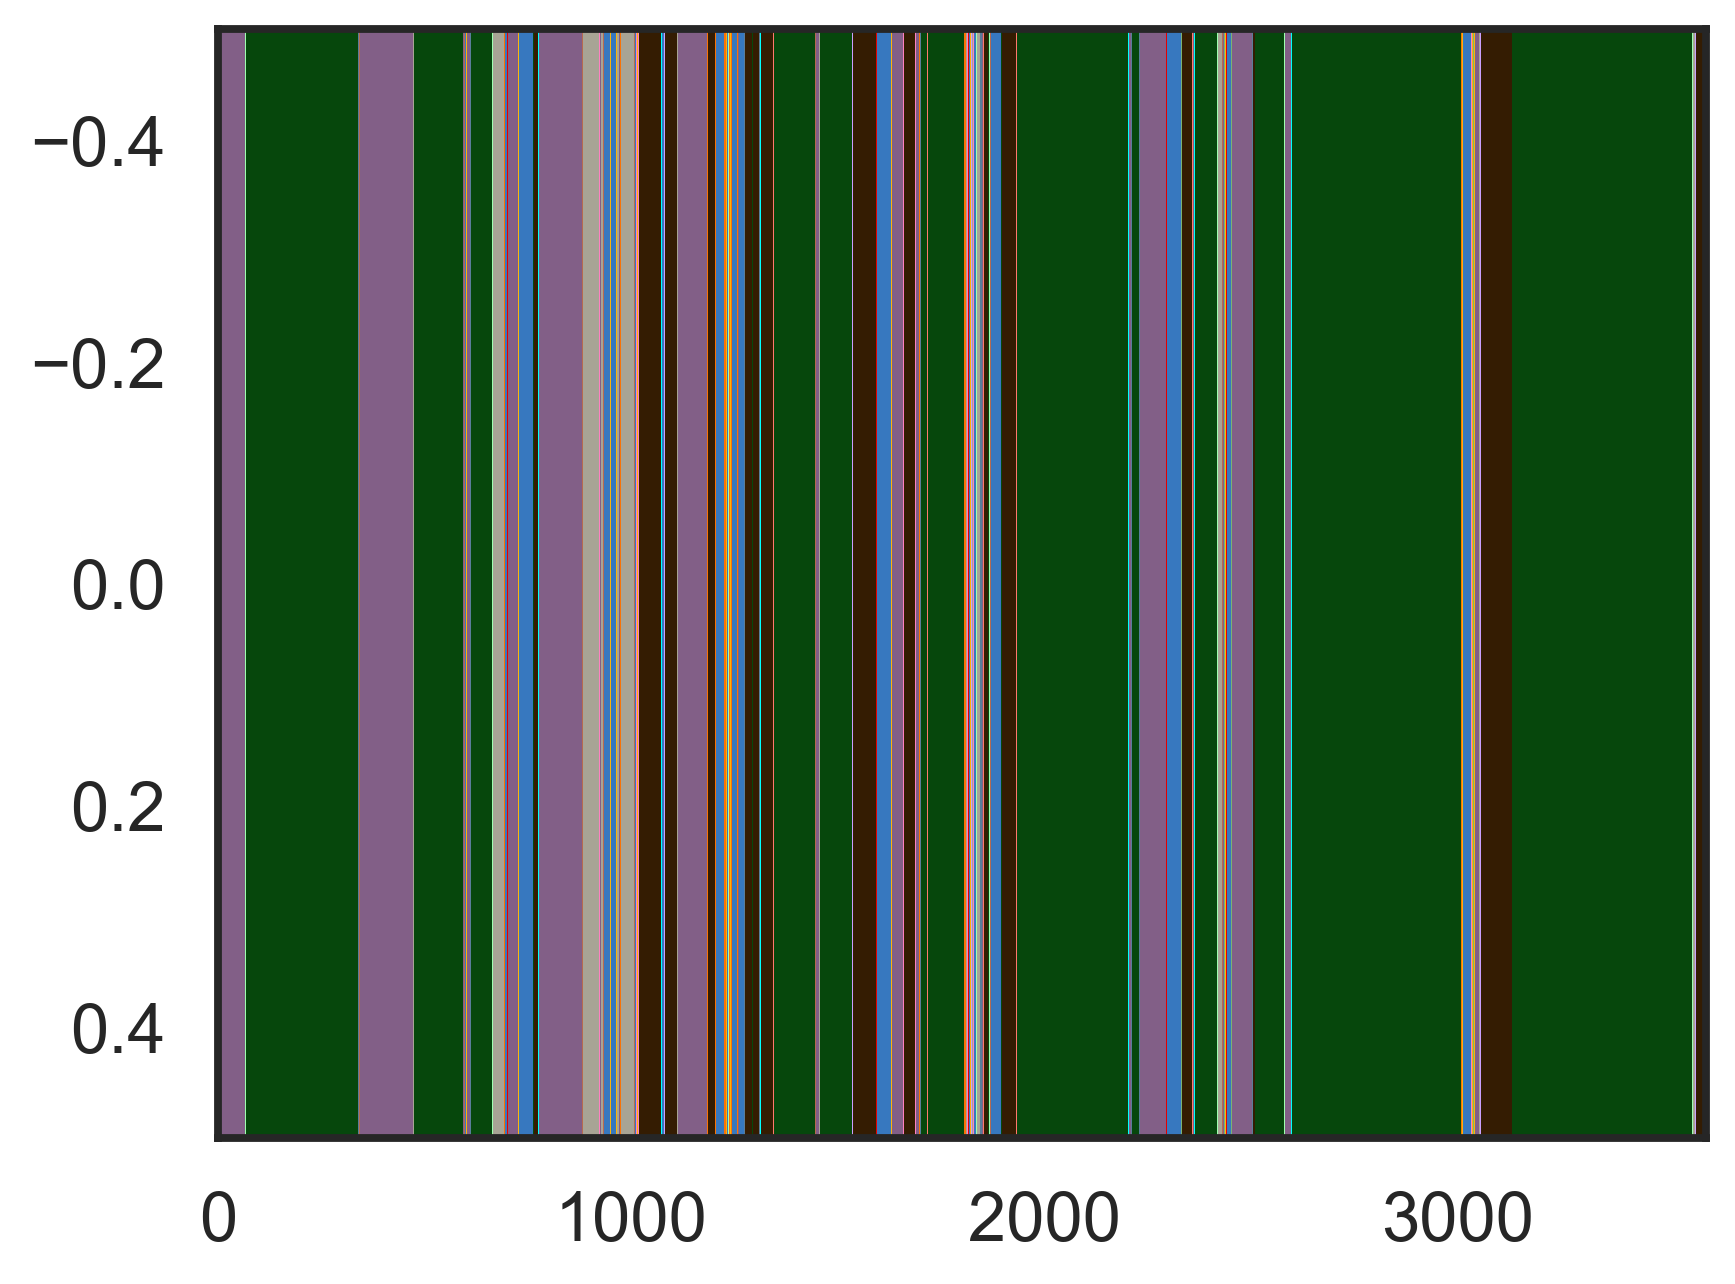

In [147]:
plt.imshow(zhat_lem.reshape(-1, 1).T, aspect="auto", cmap=cmap)

In [125]:

# Helper functions for plotting results
def plot_trajectory(z, x, ax=None, ls="-"):
    zcps = np.concatenate(([0], np.where(np.diff(z))[0] + 1, [z.size]))
    if ax is None:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.gca()
    for start, stop in zip(zcps[:-1], zcps[1:]):
        ax.plot(x[start:stop + 1, 0],
                x[start:stop + 1, 1],
                lw=1, ls=ls,
                color=colors[z[start] % len(colors)],
                alpha=1.0)
    return ax

def plot_observations(z, y, ax=None, ls="-", lw=1):

    zcps = np.concatenate(([0], np.where(np.diff(z))[0] + 1, [z.size]))
    if ax is None:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.gca()
    T, N = y.shape
    t = np.arange(T)
    for n in range(N):
        for start, stop in zip(zcps[:-1], zcps[1:]):
            ax.plot(t[start:stop + 1], y[start:stop + 1, n],
                    lw=lw, ls=ls,
                    color=colors[z[start] % len(colors)],
                    alpha=1.0)
    return ax


def plot_most_likely_dynamics(model,
    xlim=(-4, 4), ylim=(-3, 3), nxpts=30, nypts=30,
    alpha=0.8, ax=None, figsize=(3, 3)):

    K = model.K
    # assert model.D == 2
    x = np.linspace(*xlim, nxpts)
    y = np.linspace(*ylim, nypts)
    X, Y = np.meshgrid(x, y)
    xy = np.column_stack((X.ravel(), Y.ravel()))

    # Get the probability of each state at each xy location
    log_Ps = model.transitions.log_transition_matrices(
        xy, np.zeros((nxpts * nypts, 0)), np.ones_like(xy, dtype=bool), None)
    z = np.argmax(log_Ps[:, 0, :], axis=-1)
    print(np.shape(z))
    z = np.concatenate([[z[0]], z])

    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111)

    for k, (A, b) in enumerate(zip(model.dynamics.As, model.dynamics.bs)):
        dxydt_m = xy.dot(A.T[:2, :2]) + b[:2] - xy[:, :2]

        zk = z == k
        print(np.shape(zk))
        print(np.shape(dxydt_m))
        print(np.shape(xy))
        if zk.sum() > 0:
            ax.quiver(xy[zk, 0], xy[zk, 1],
                      dxydt_m[zk, 0], dxydt_m[zk, 1],
                      color=colors[k % len(colors)], alpha=alpha)

    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

    plt.tight_layout()

    return ax


<Axes: >

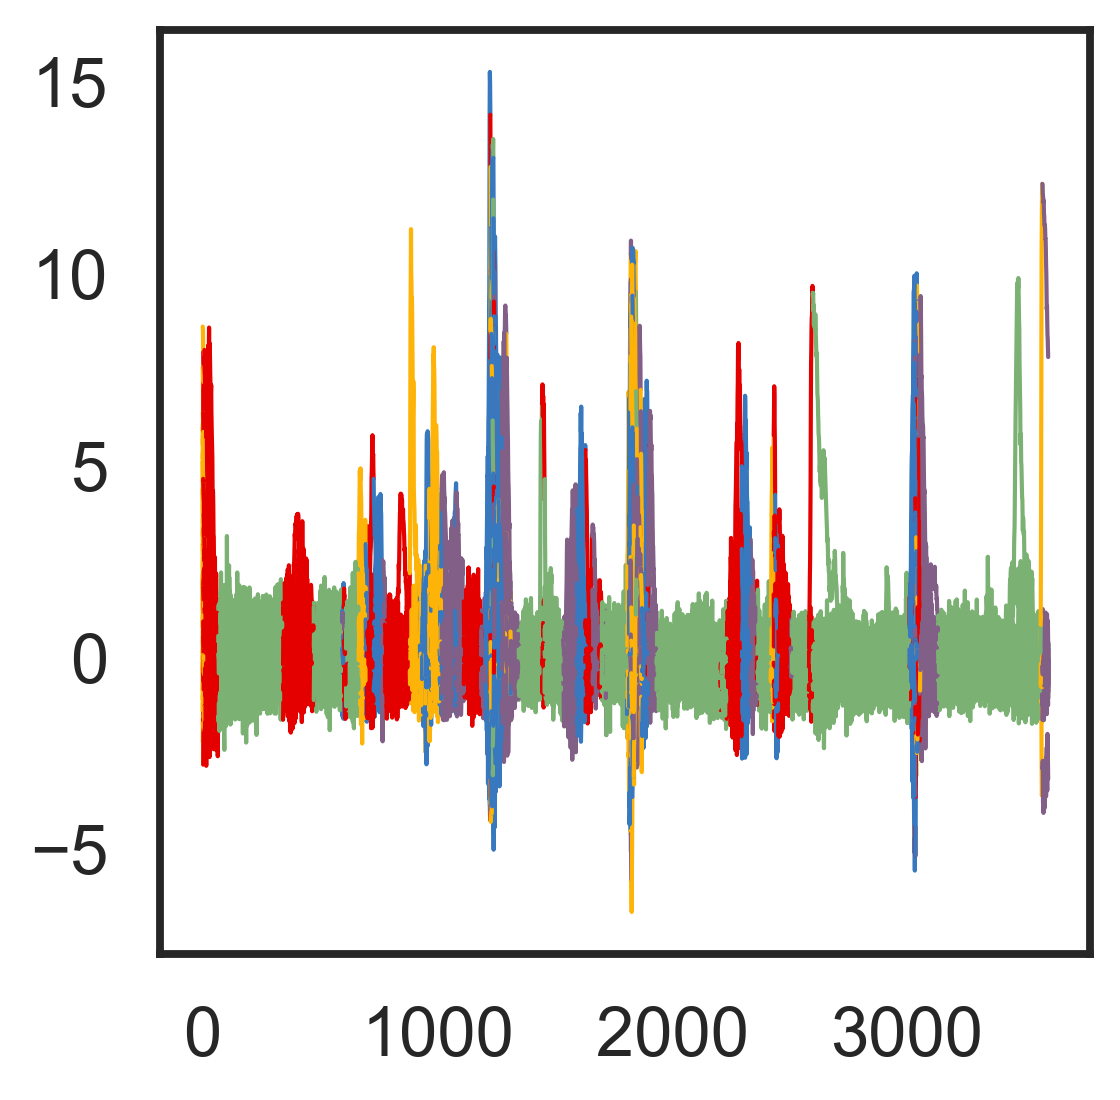

In [138]:
plot_observations(zhat_lem, scaled_traces)

(1,)
(2,)
(900, 2)
(900, 2)


IndexError: boolean index did not match indexed array along dimension 0; dimension is 900 but corresponding boolean dimension is 2

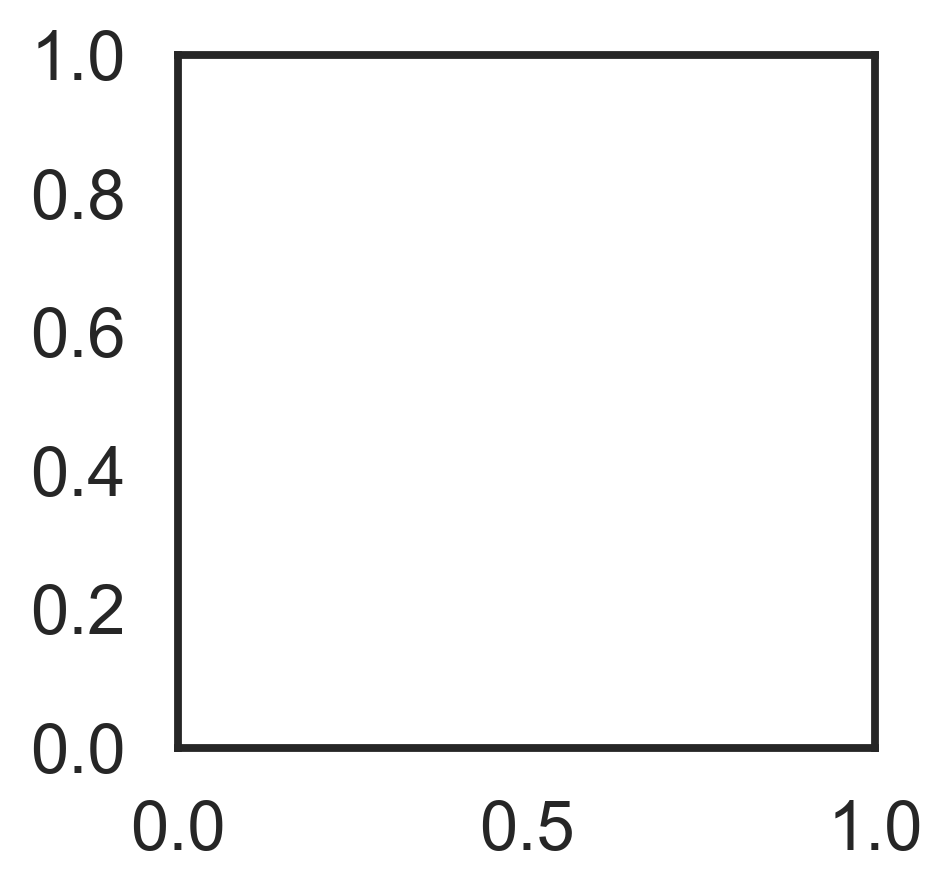

In [139]:
plot_most_likely_dynamics(fc_rslds)

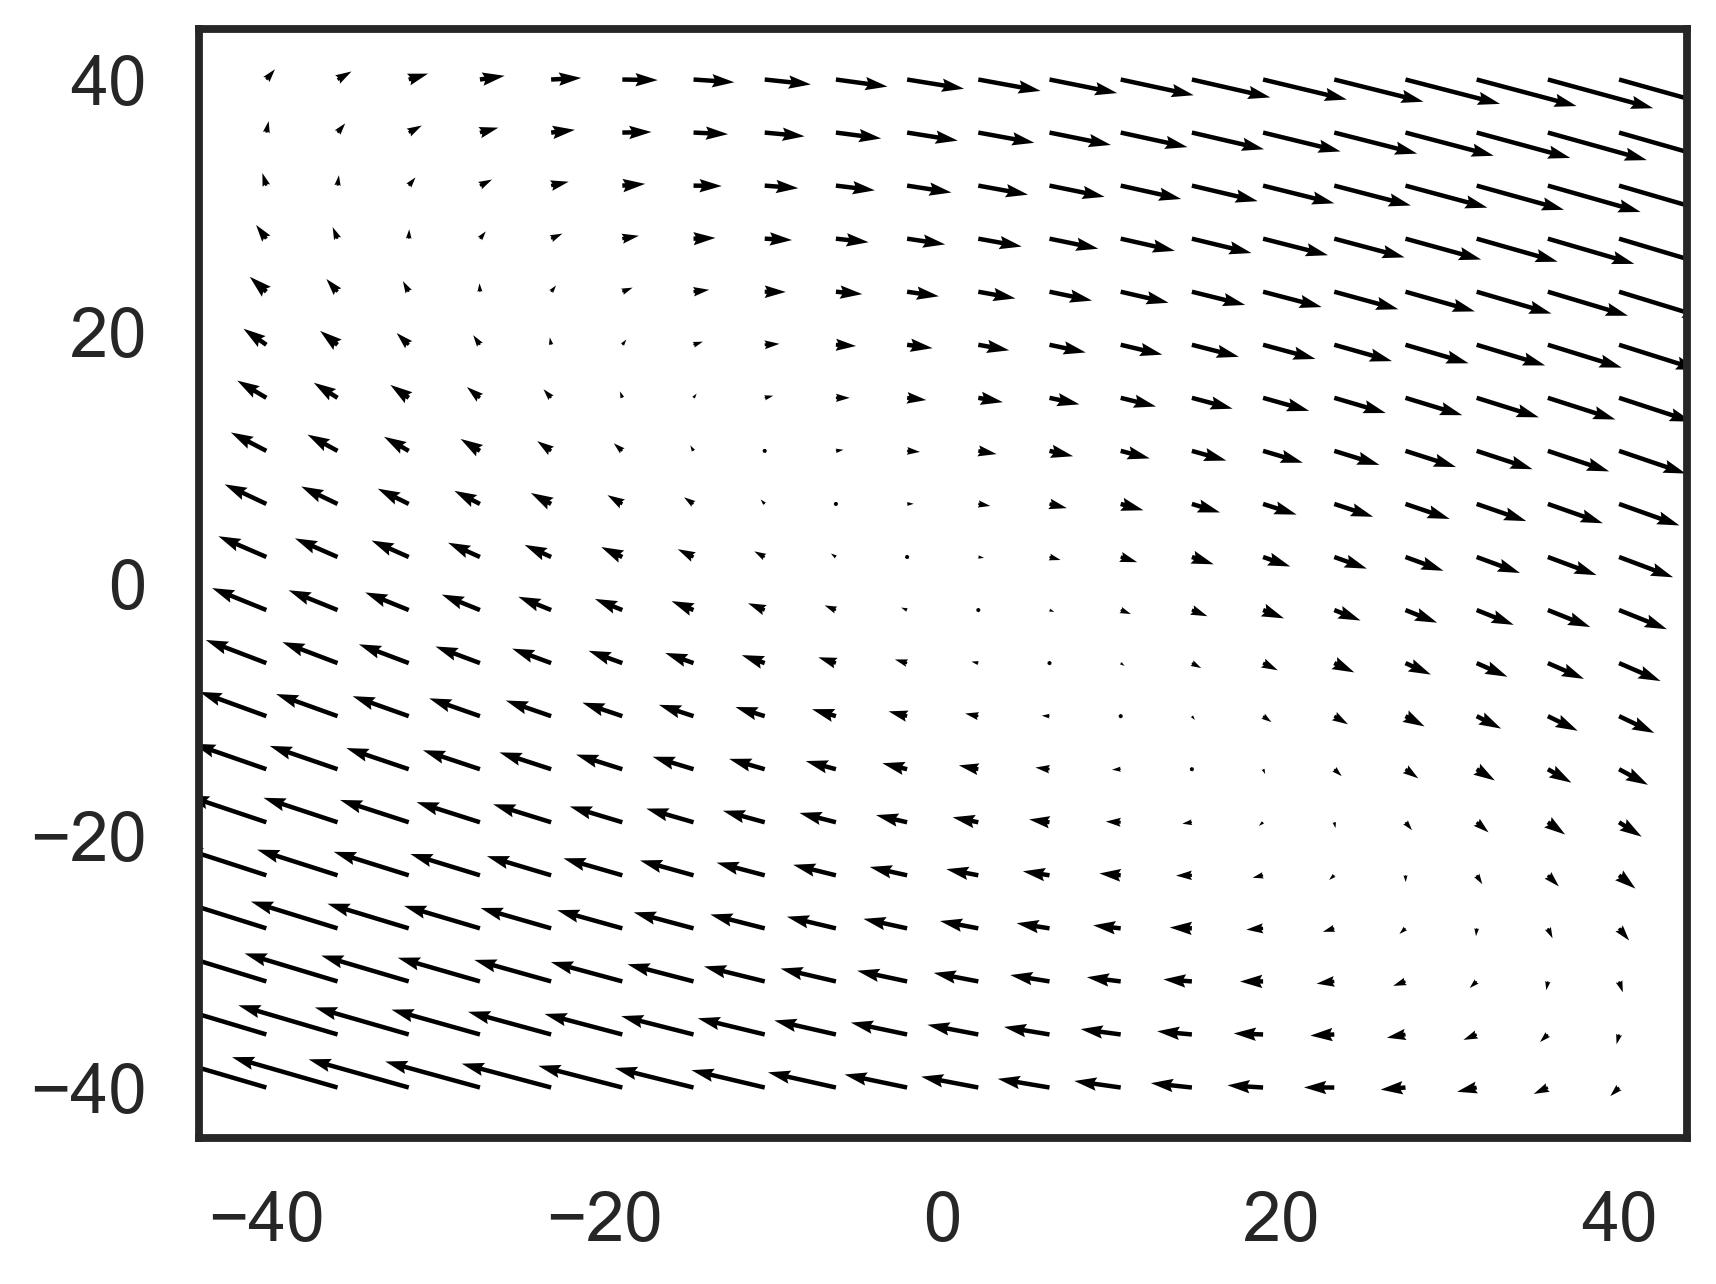

In [146]:
plot_dynamics_2d(fc_rslds.dynamics.As[0, :2, :2], fc_rslds.dynamics.bs[0, :2])

<Axes: >

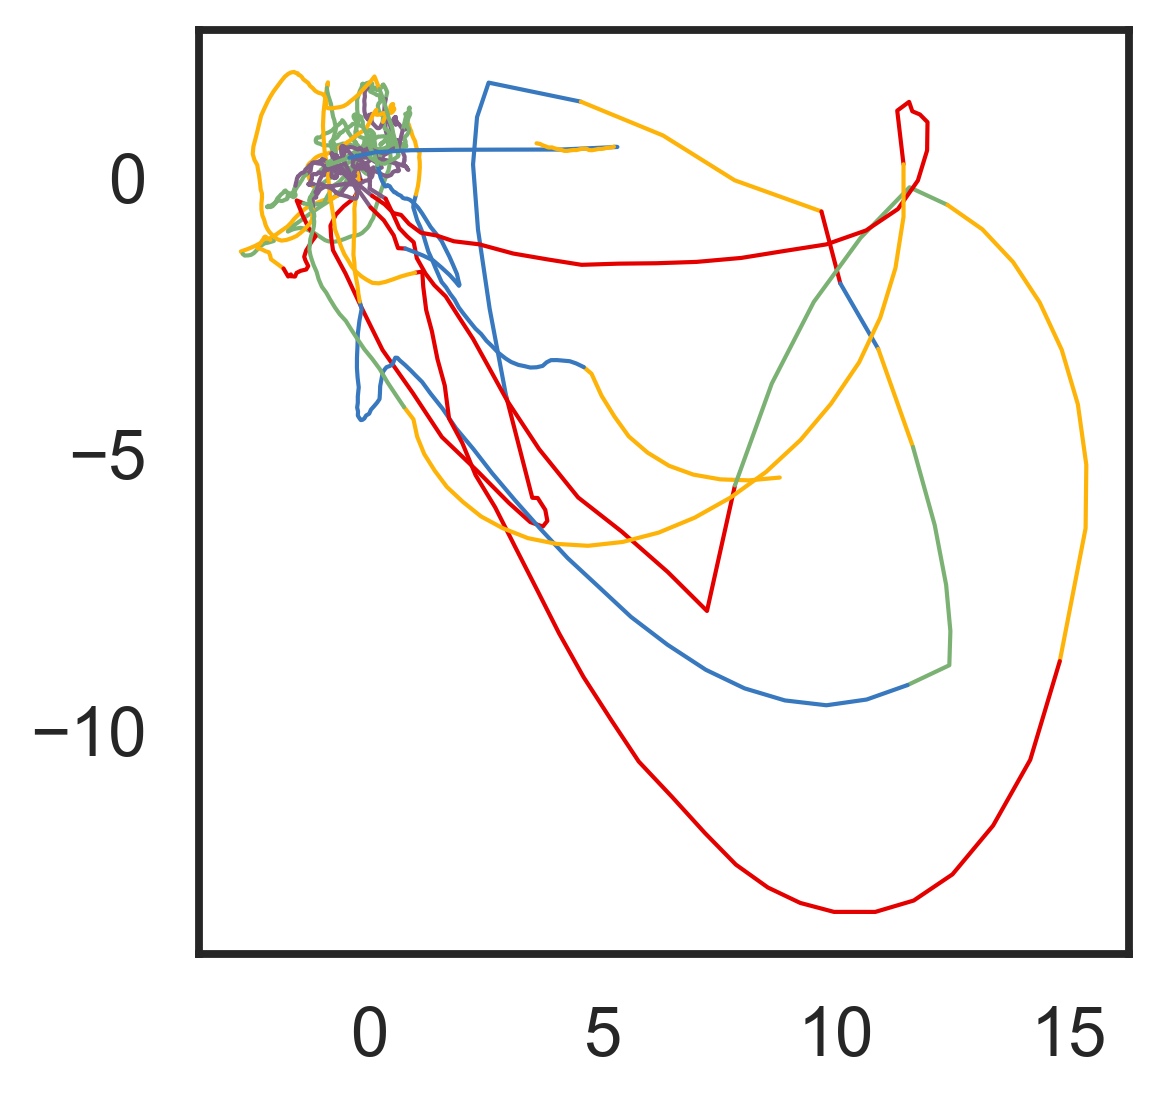

In [13]:
plot_trajectory(zhat_lem, xhat_lem)

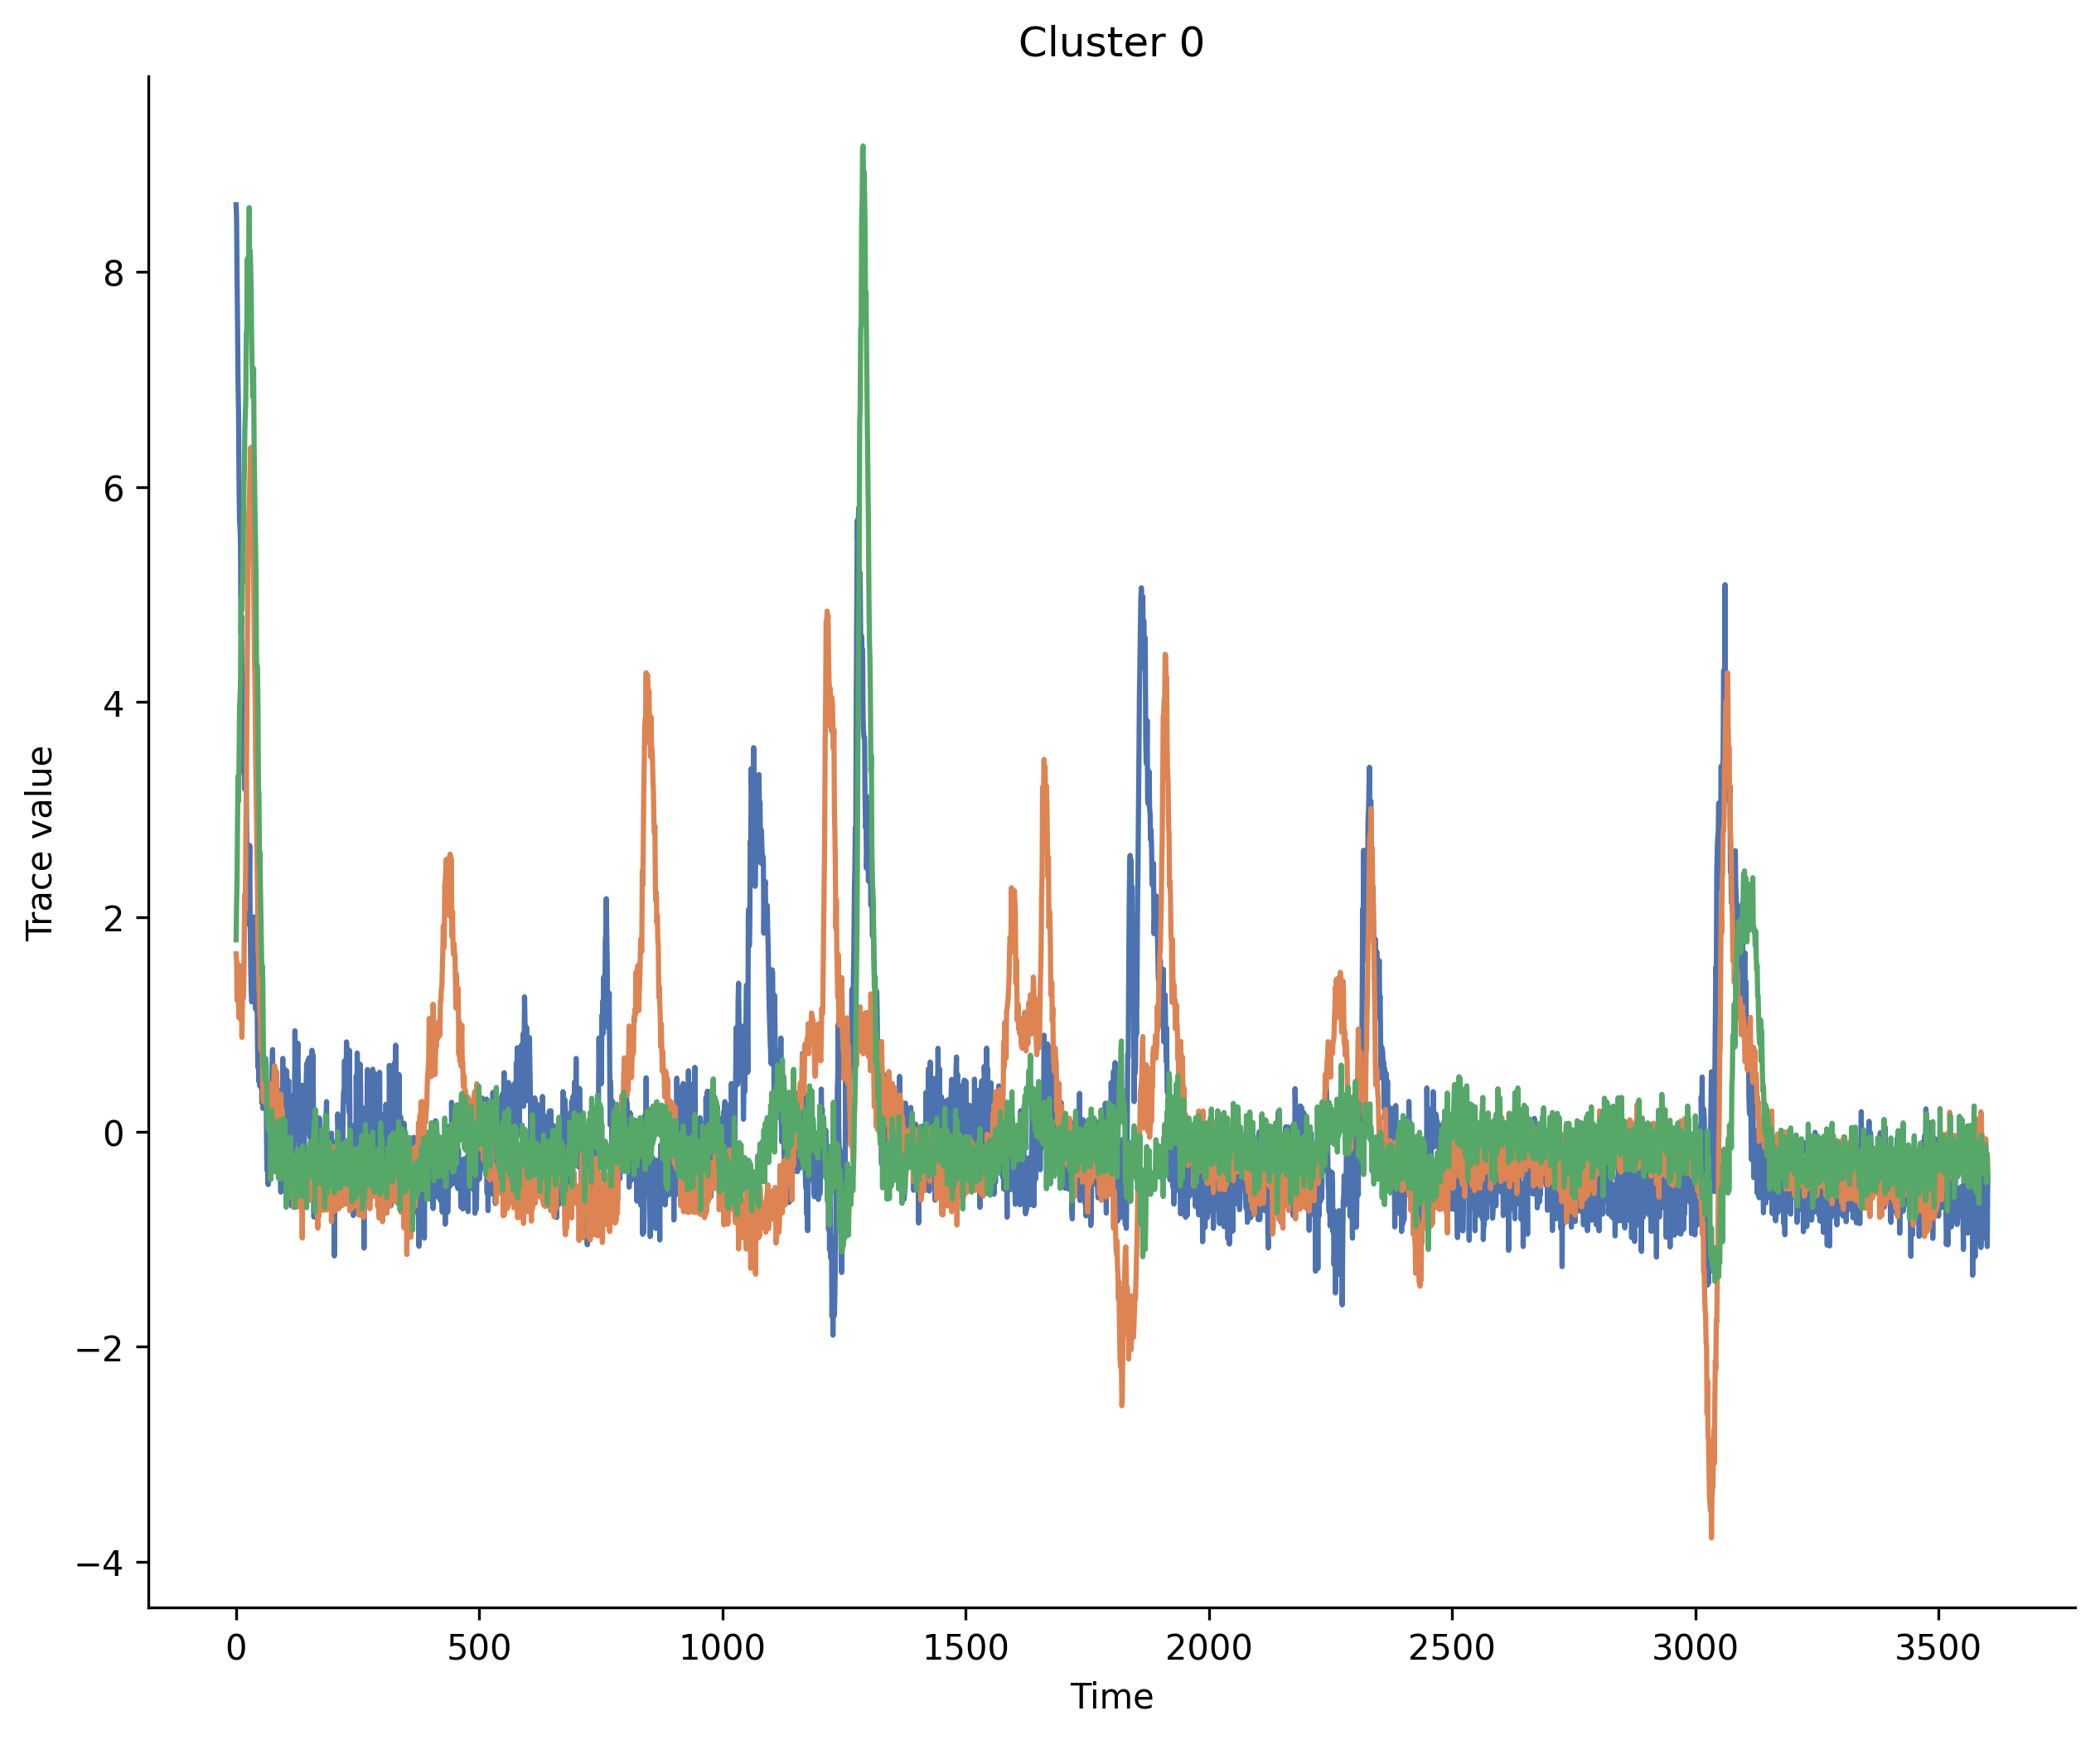

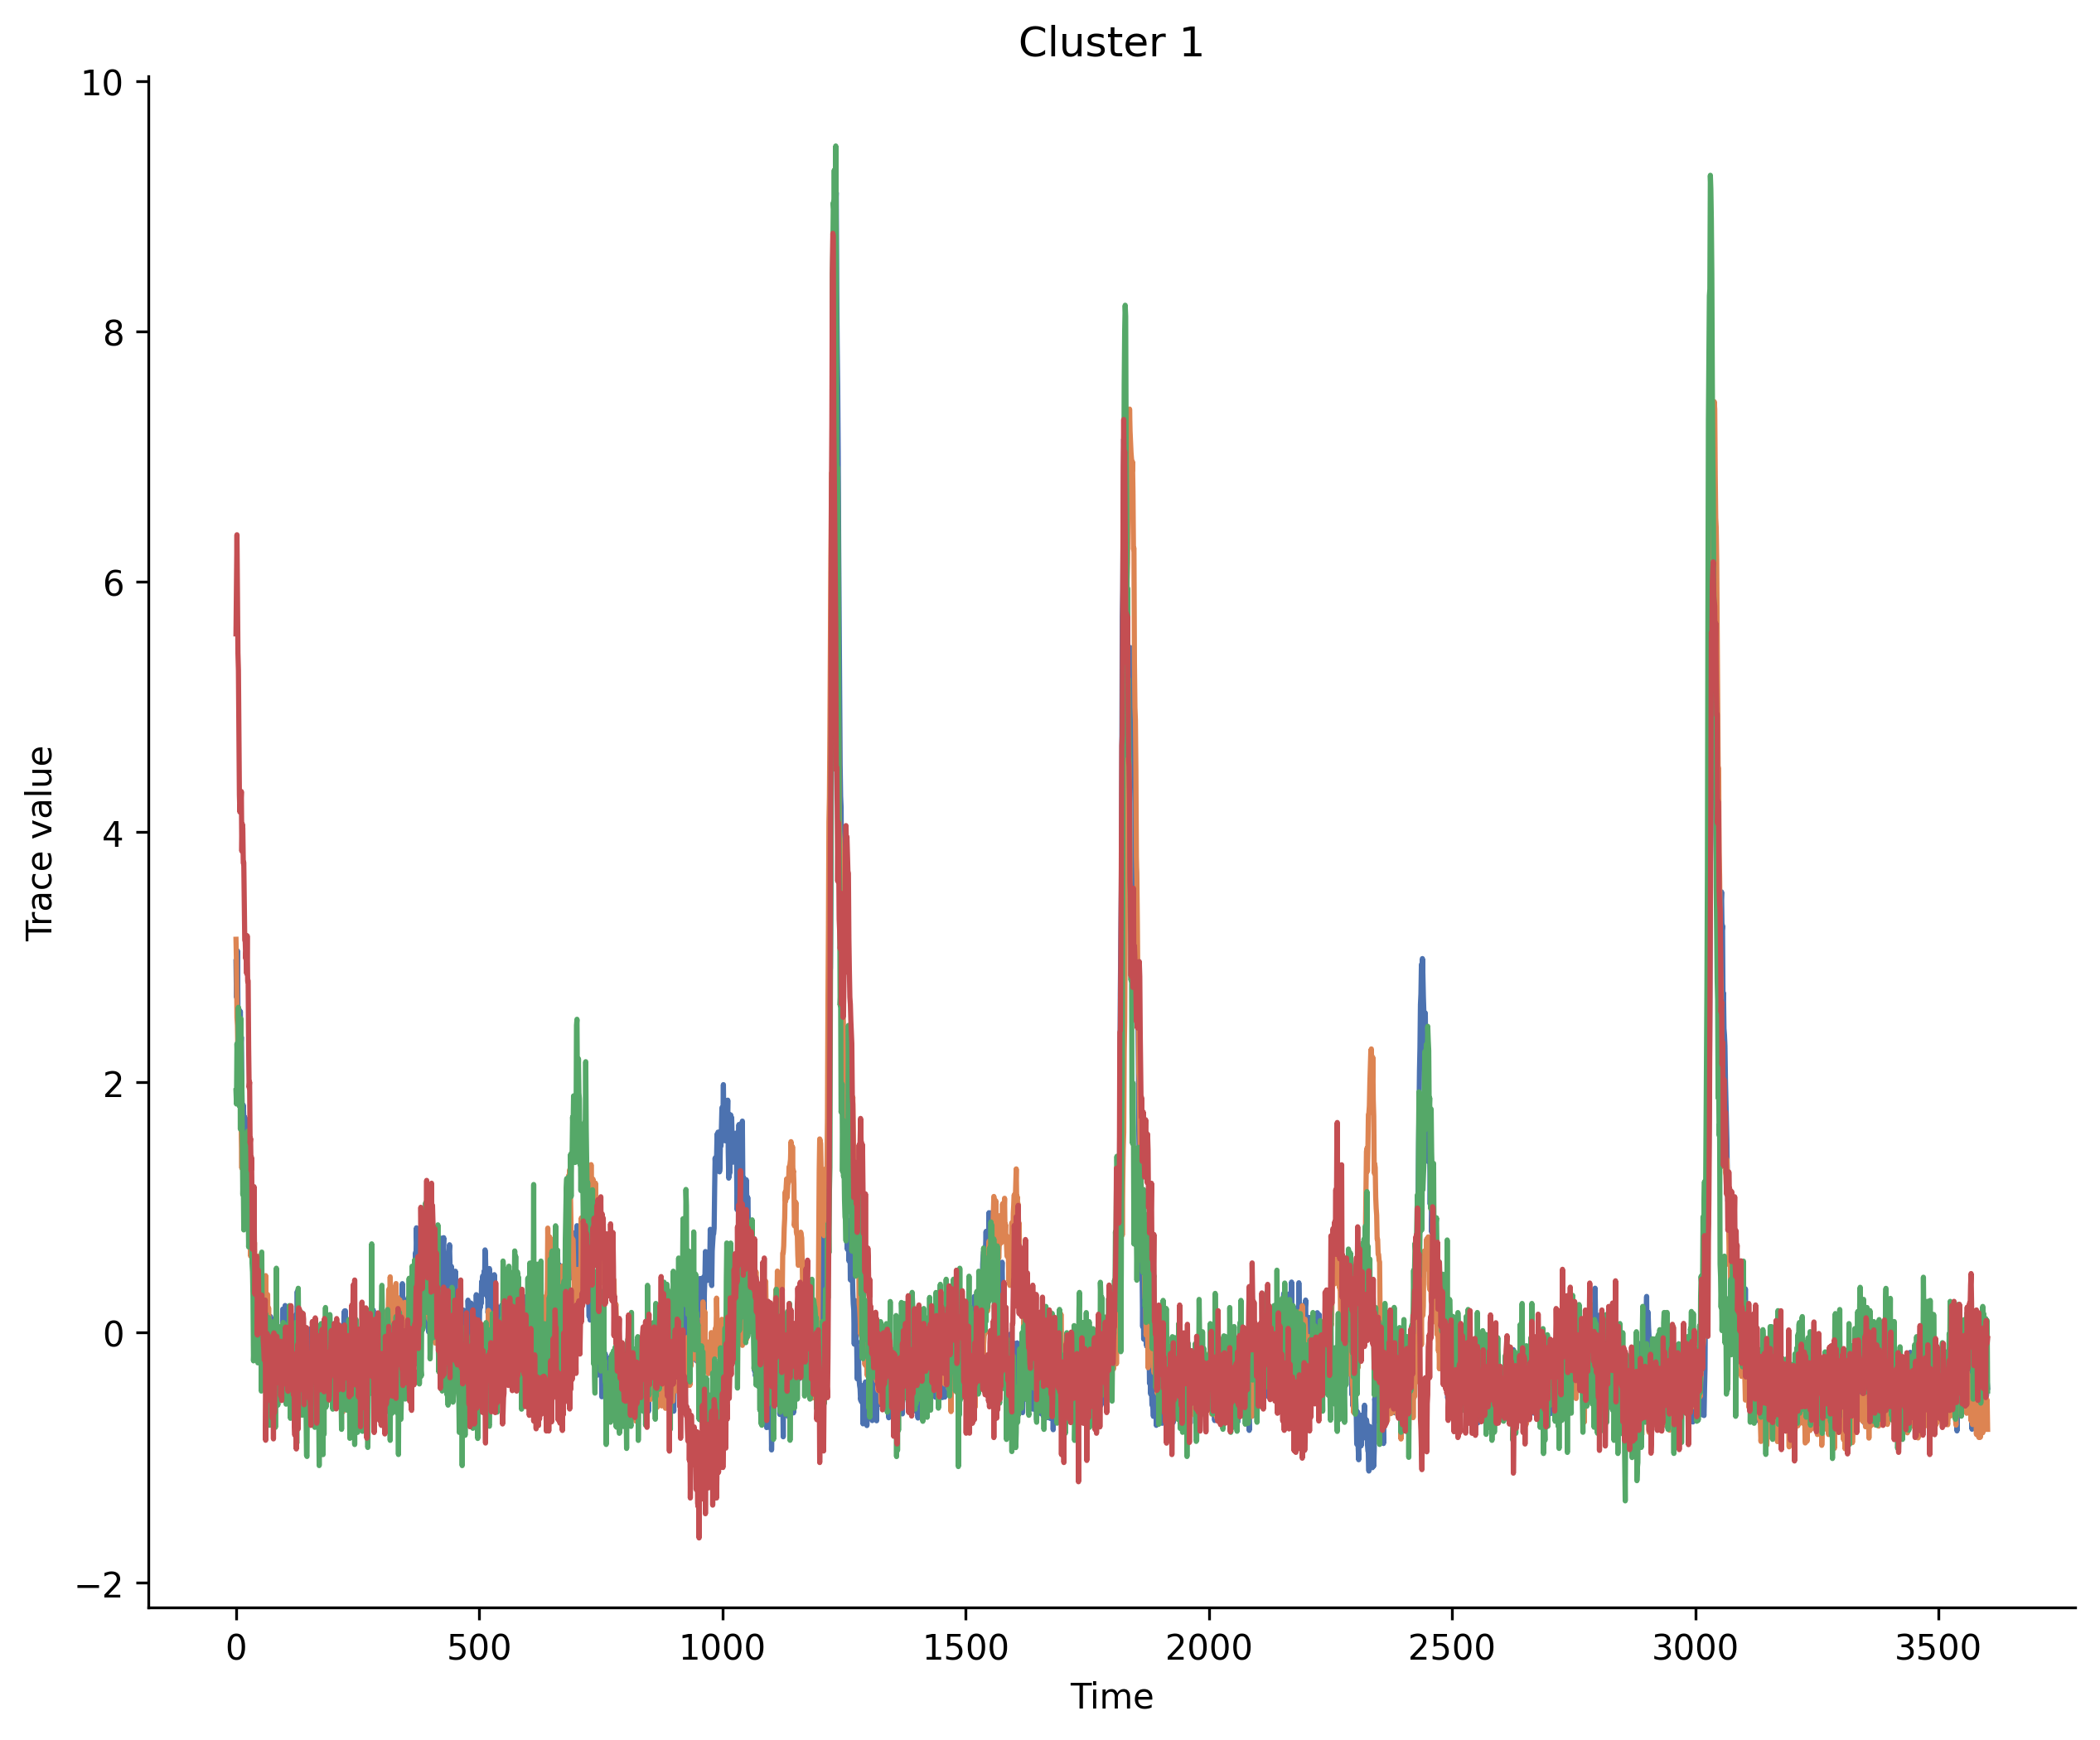

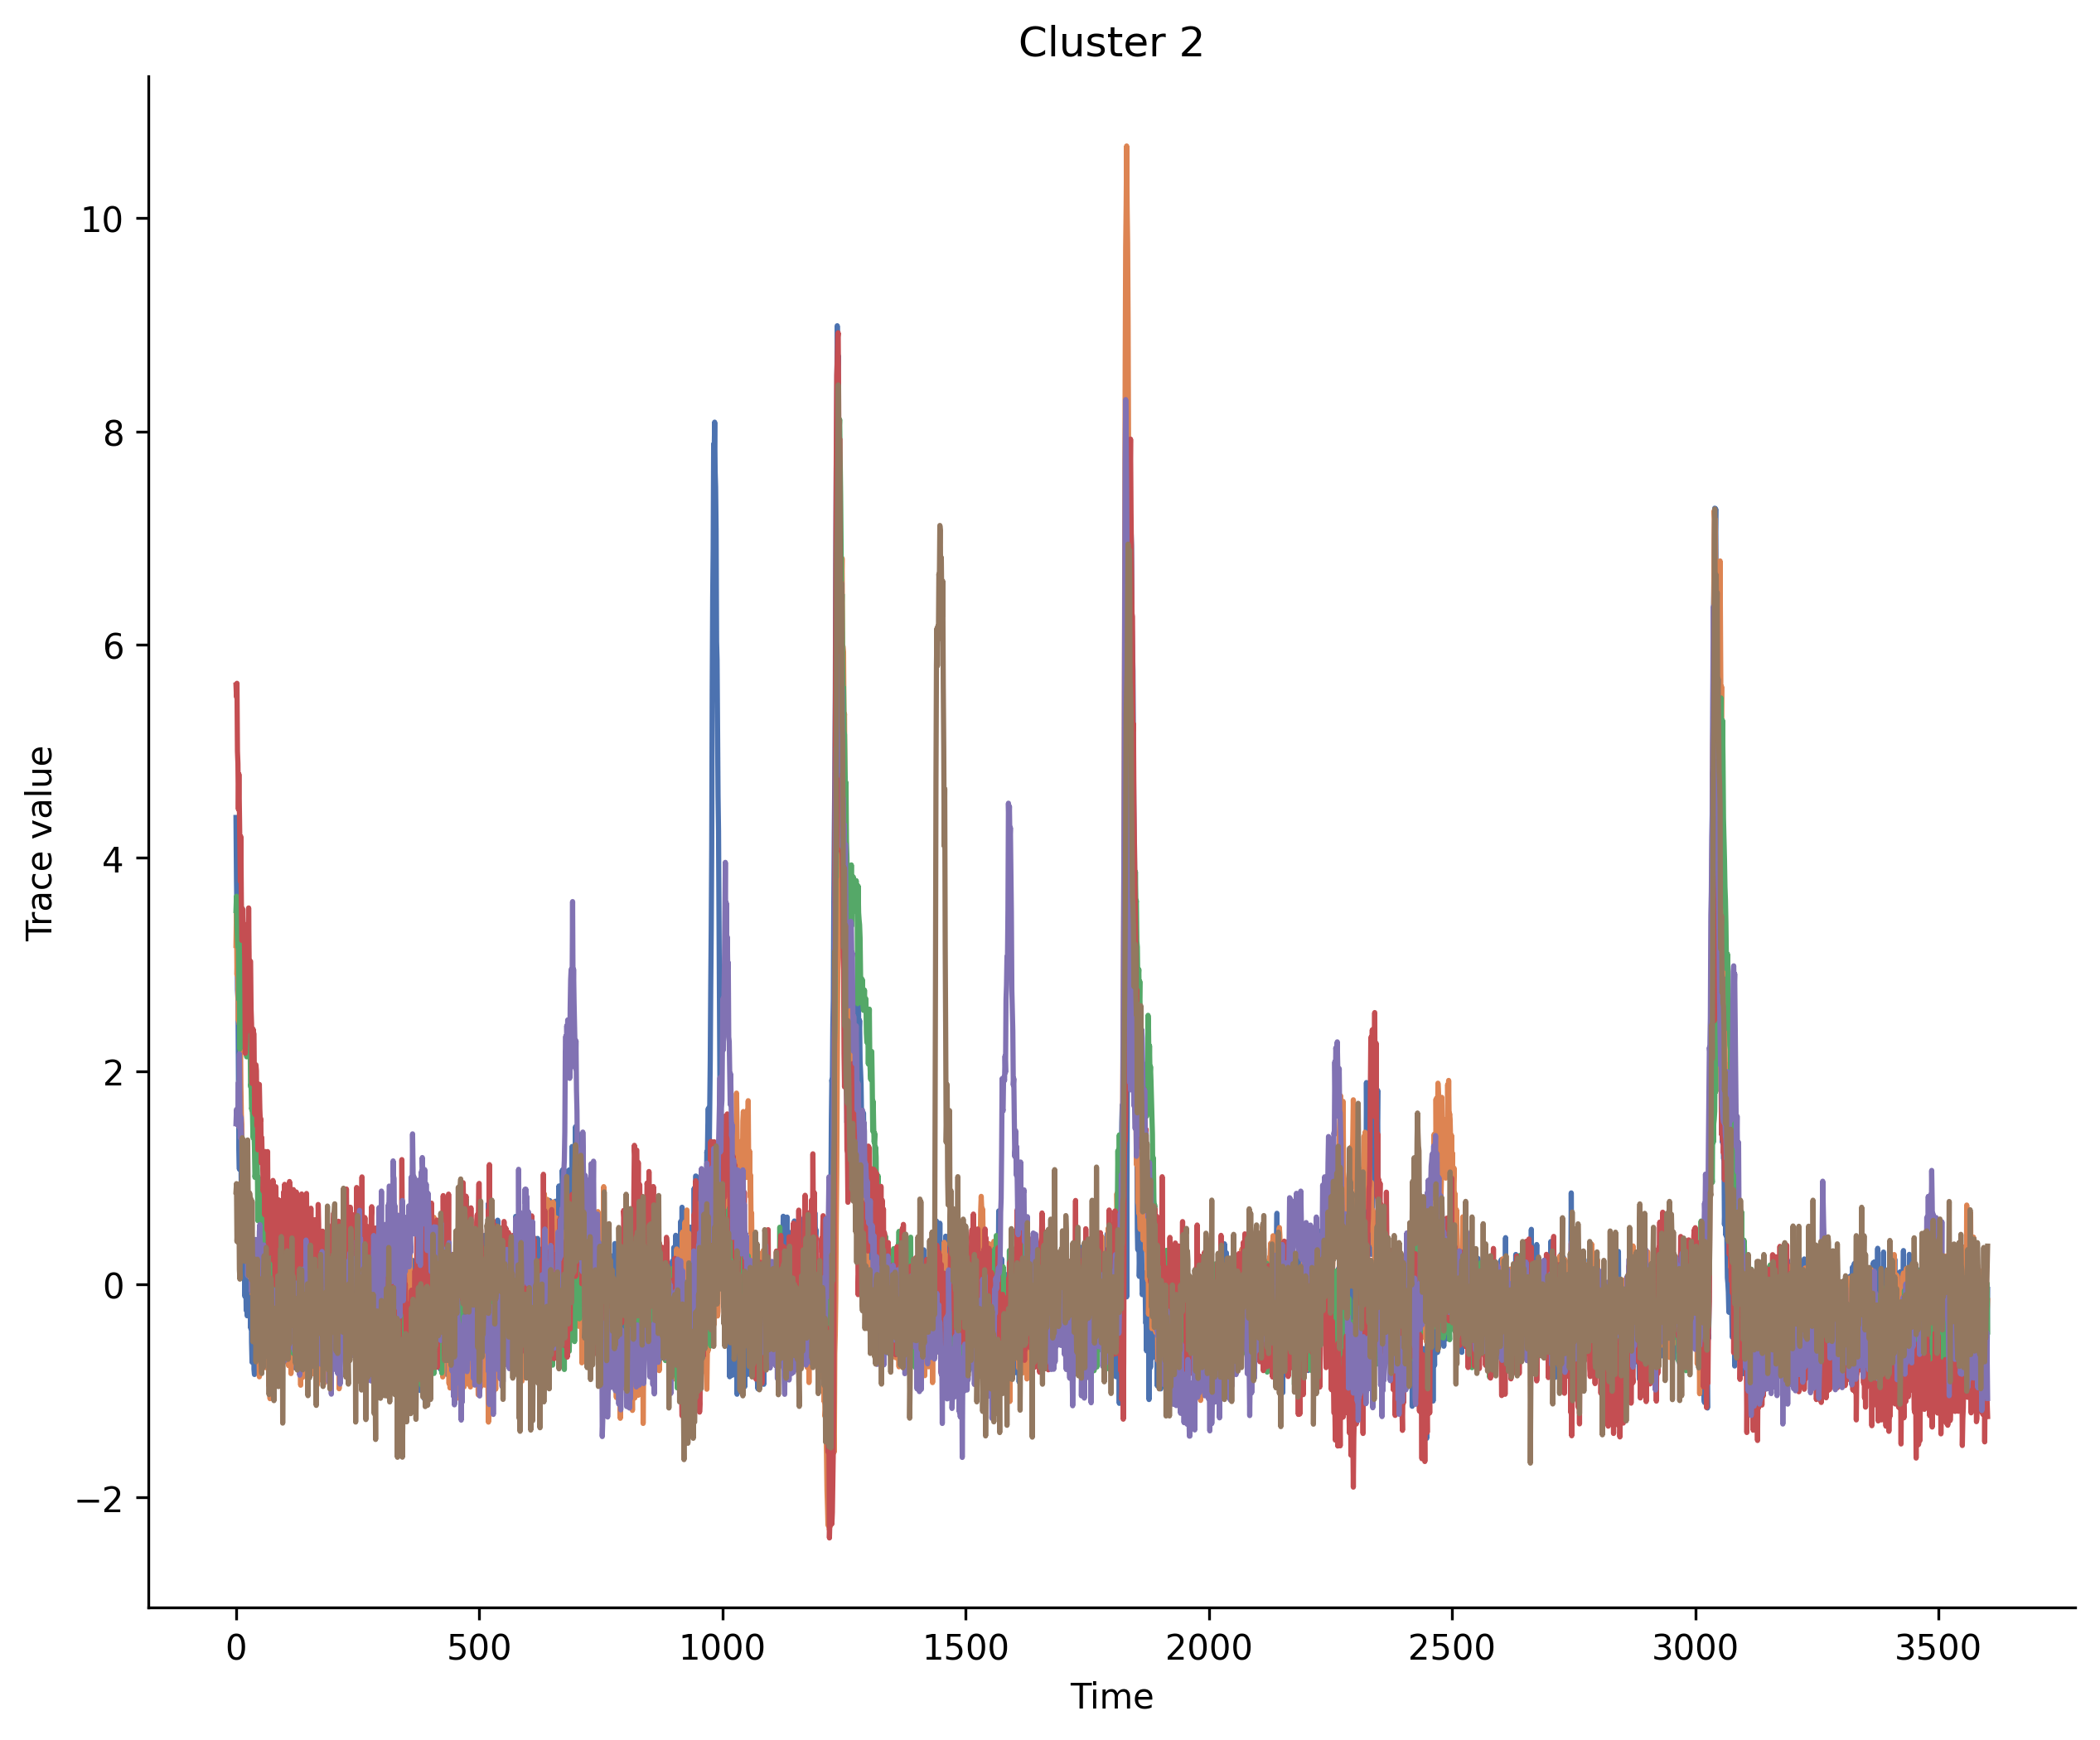

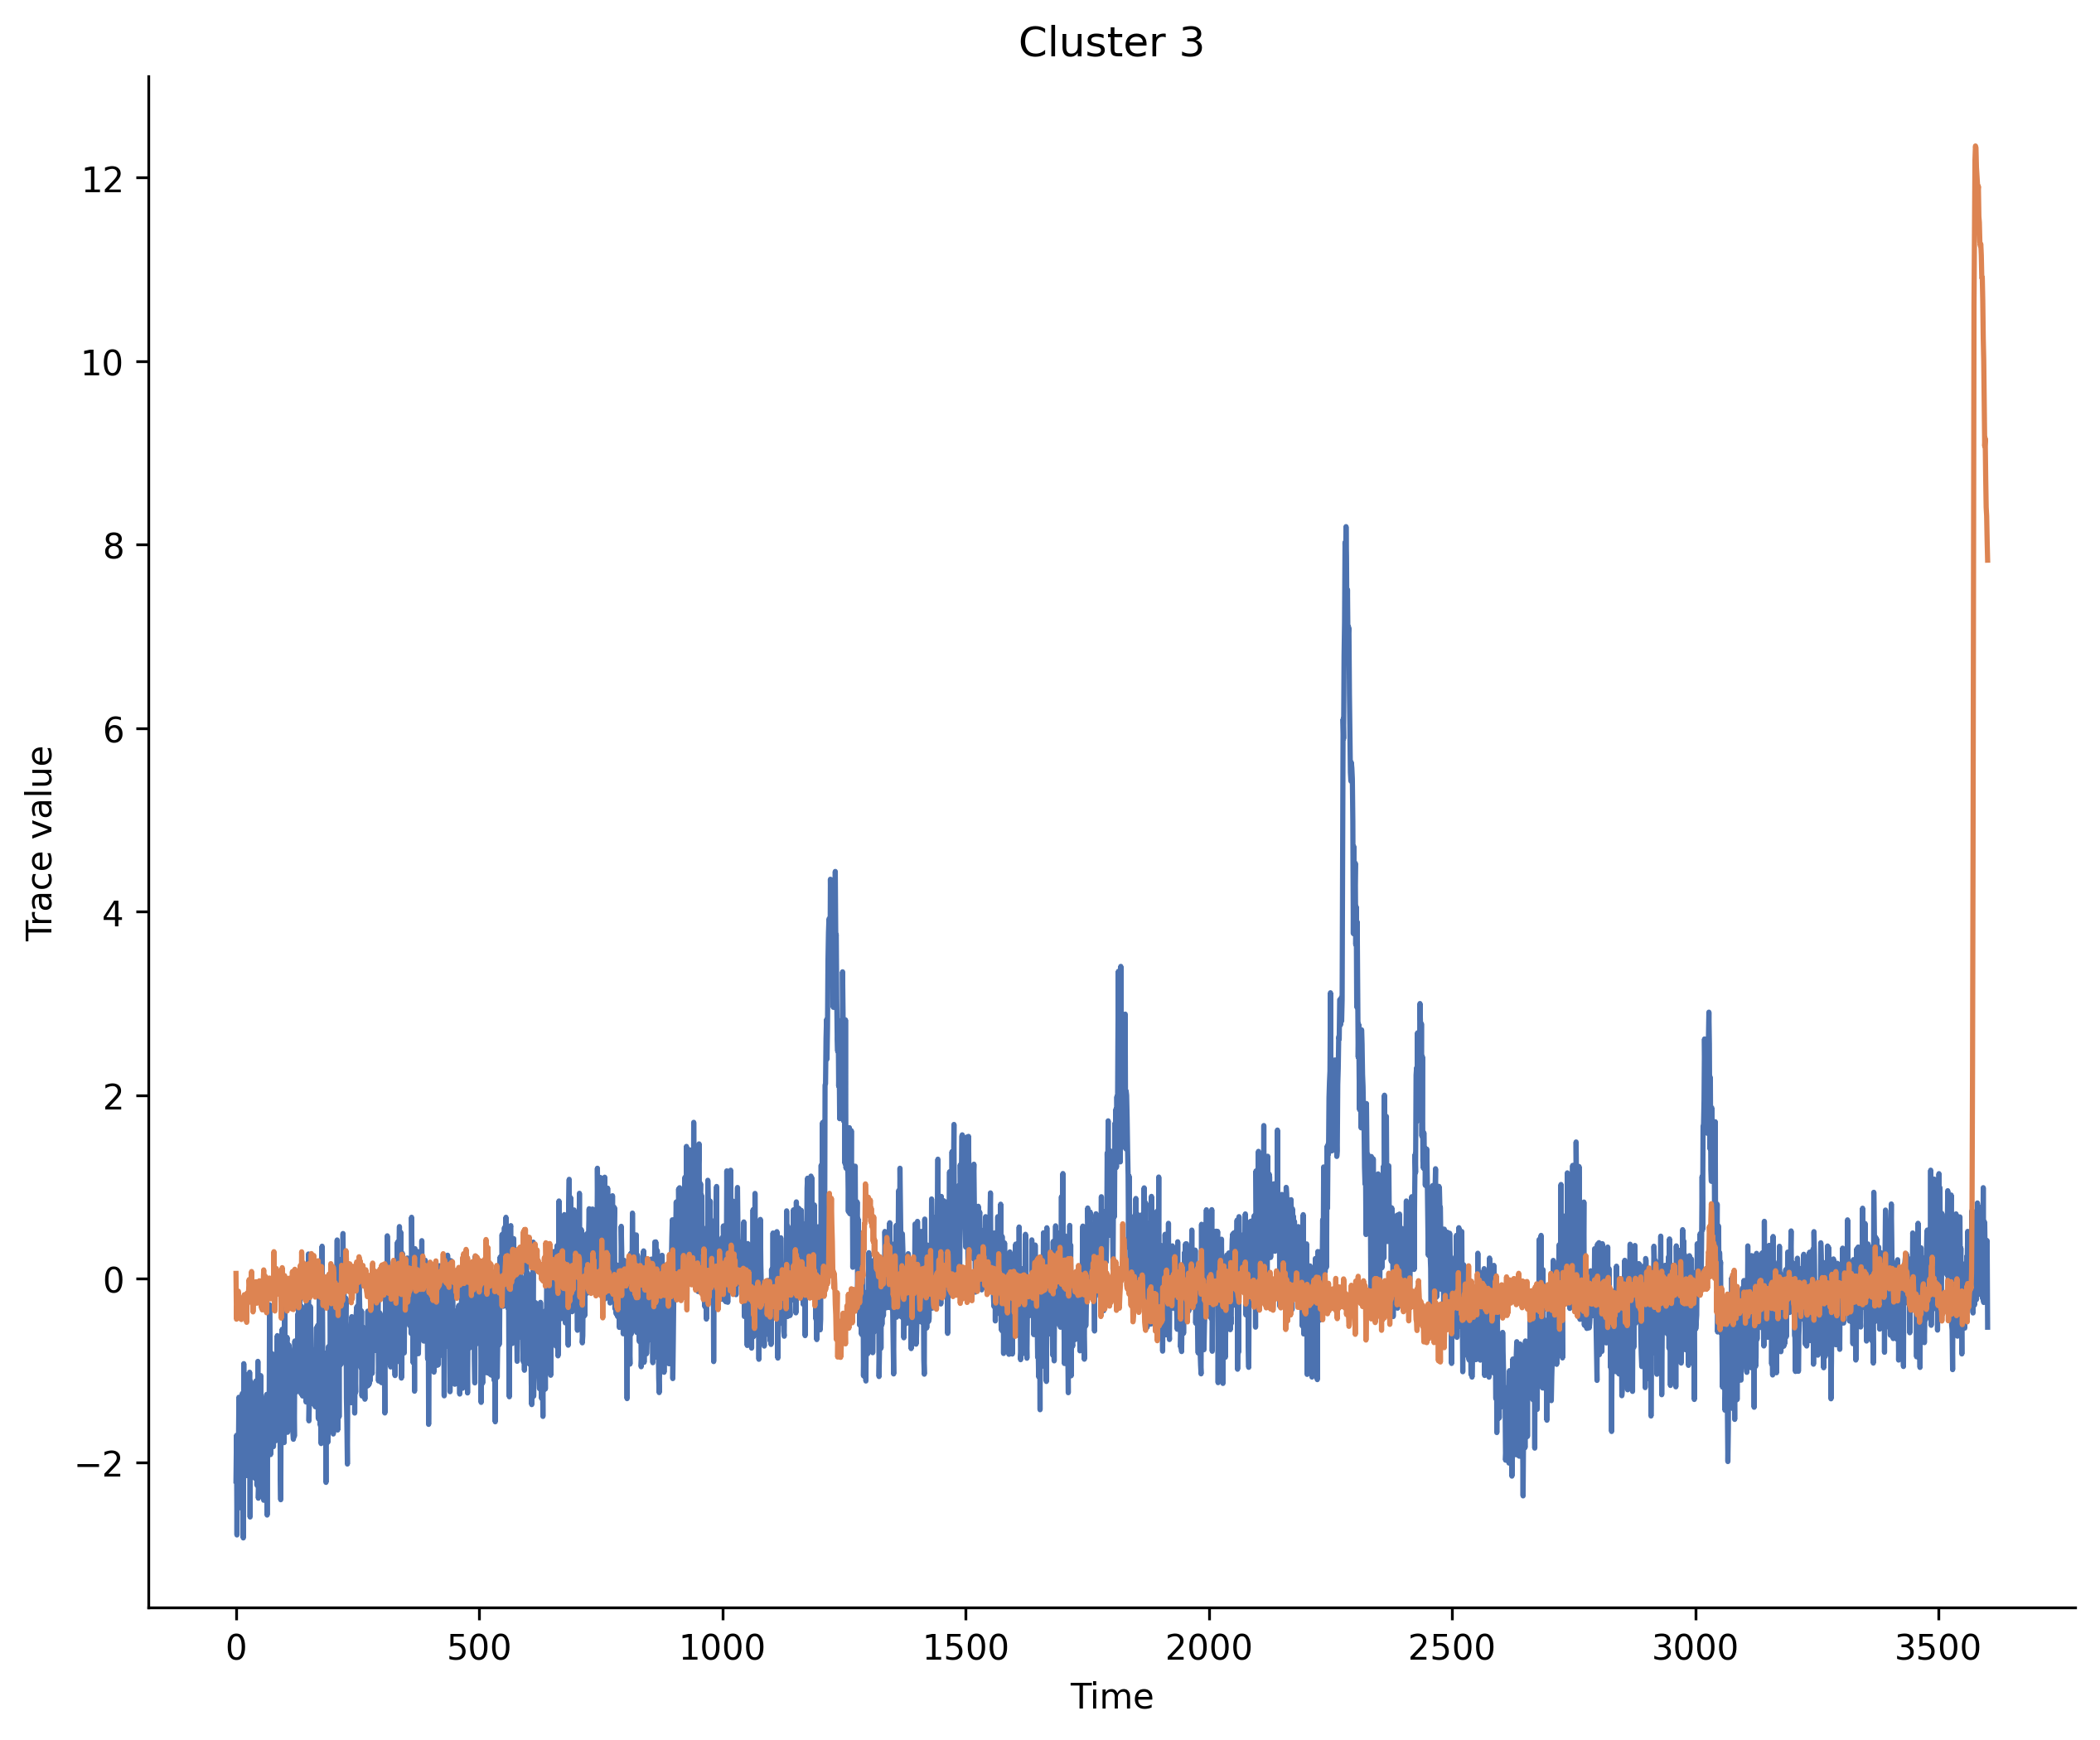

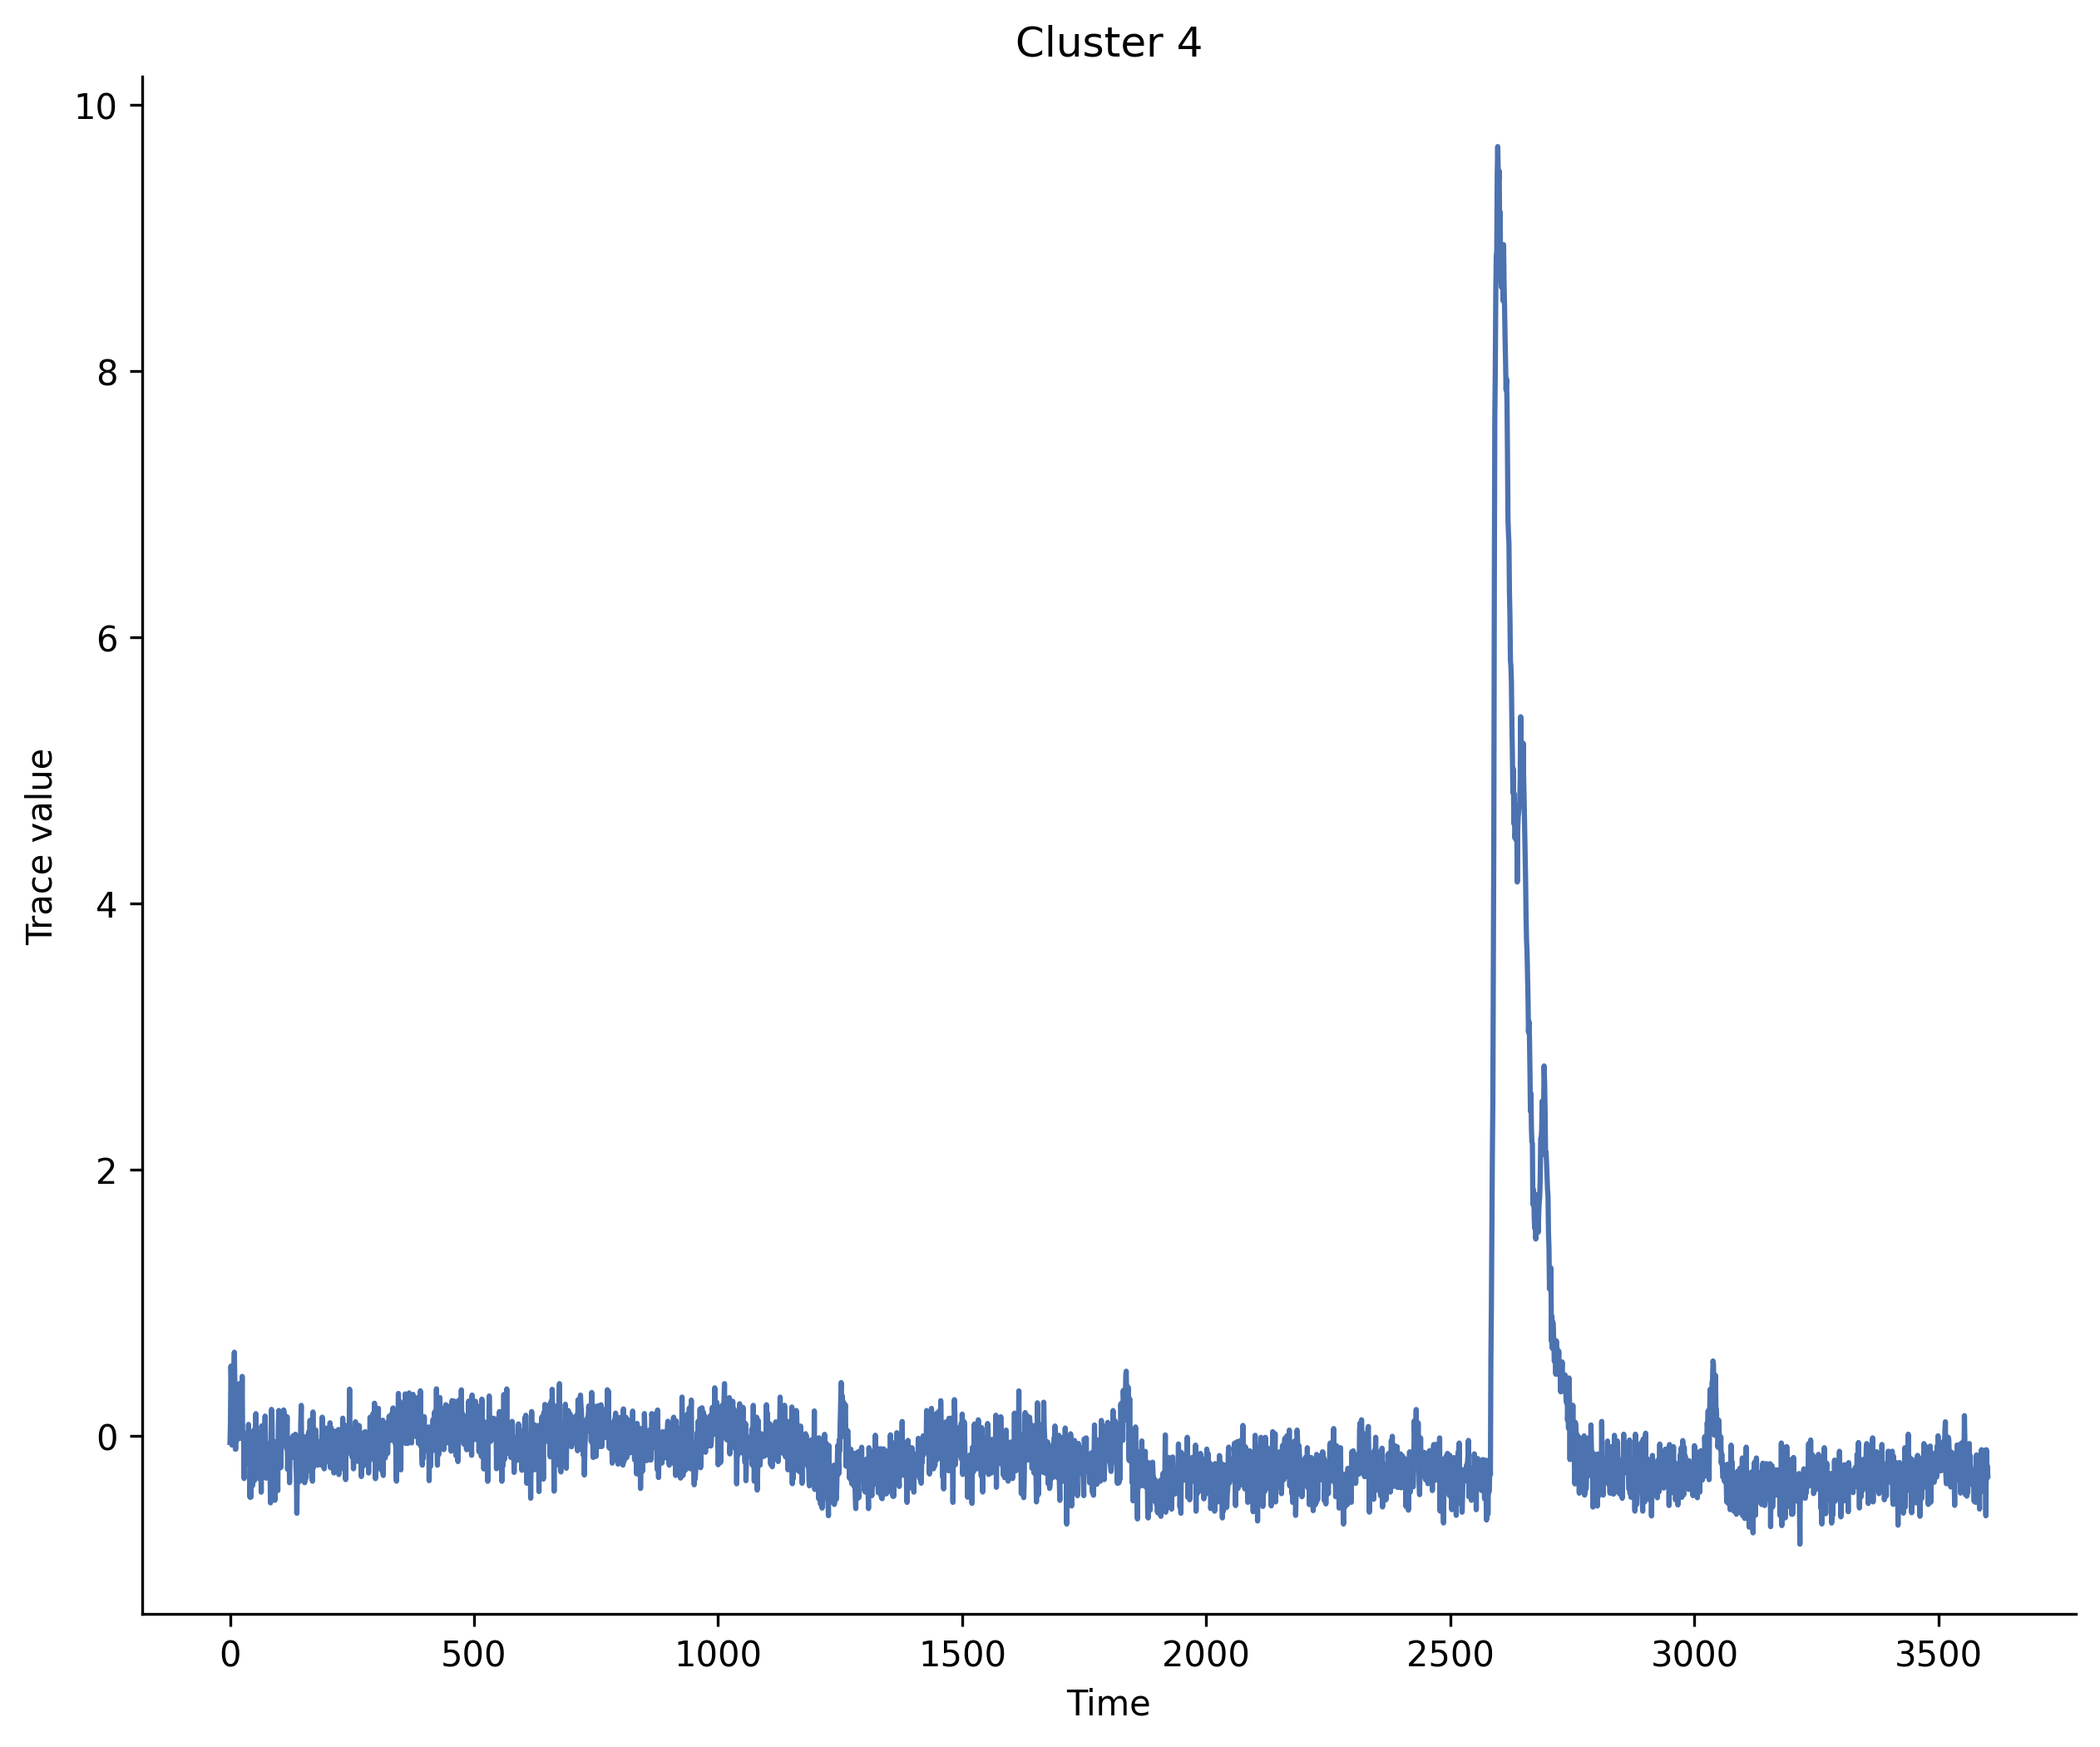

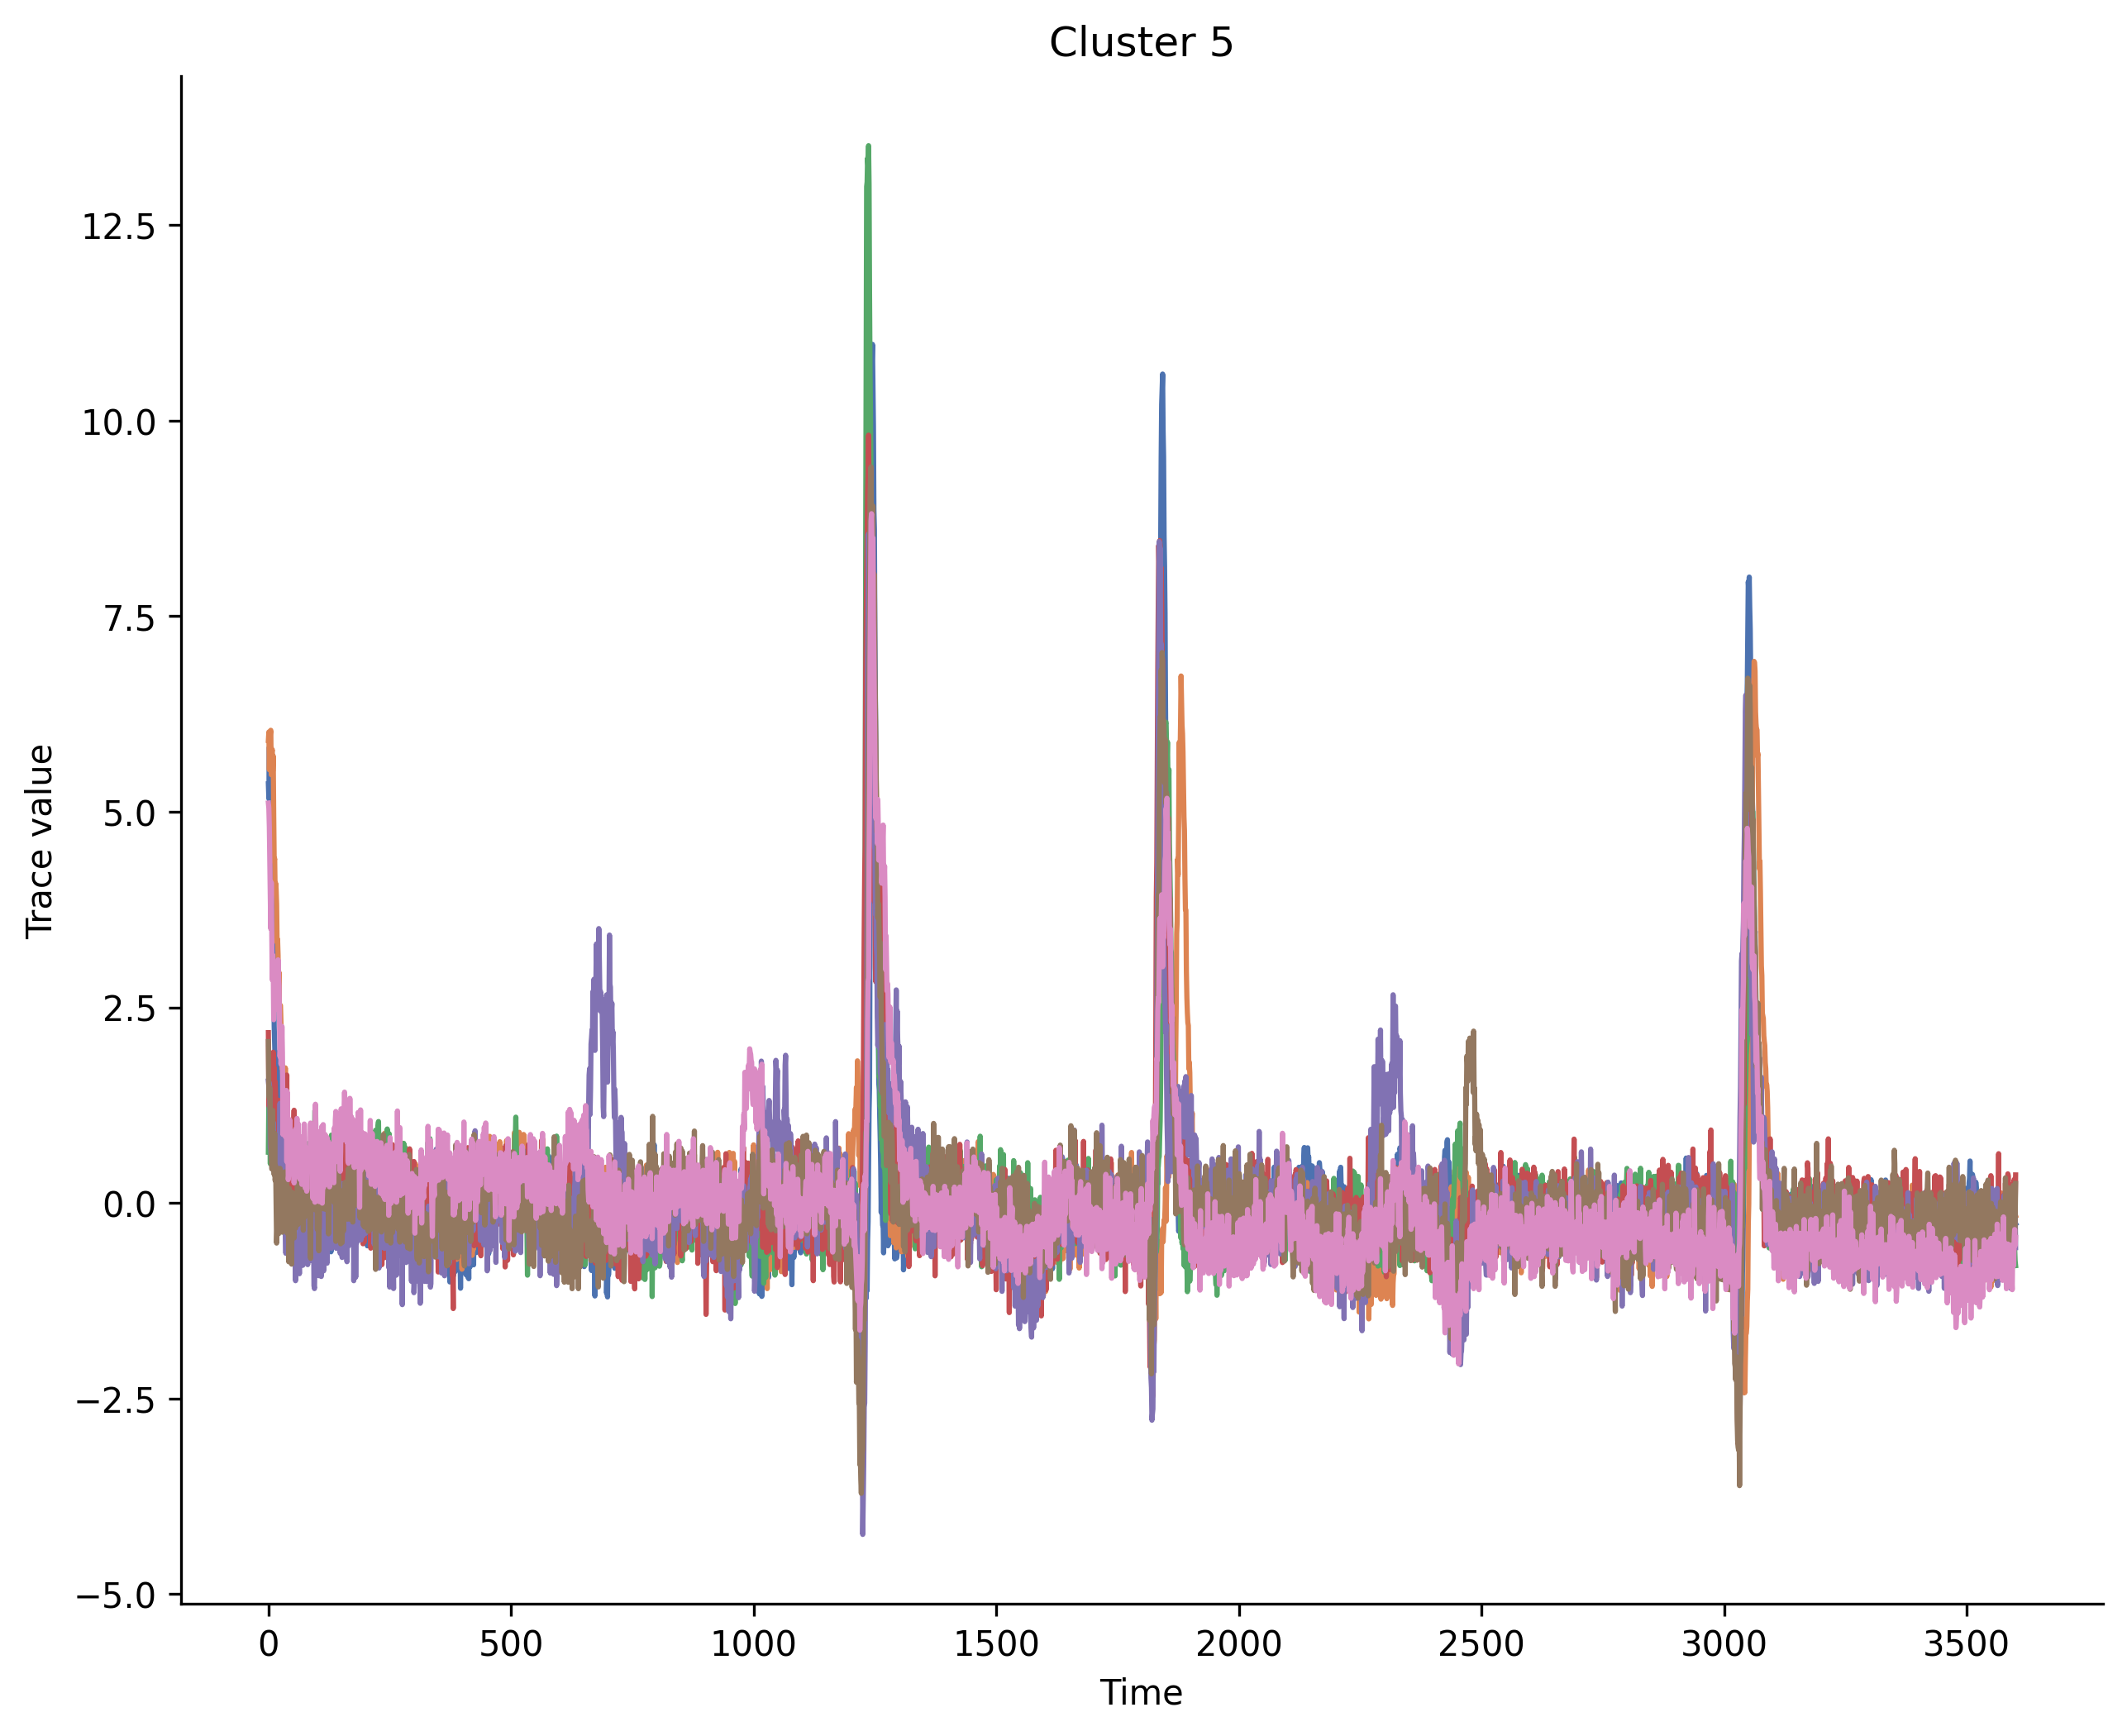

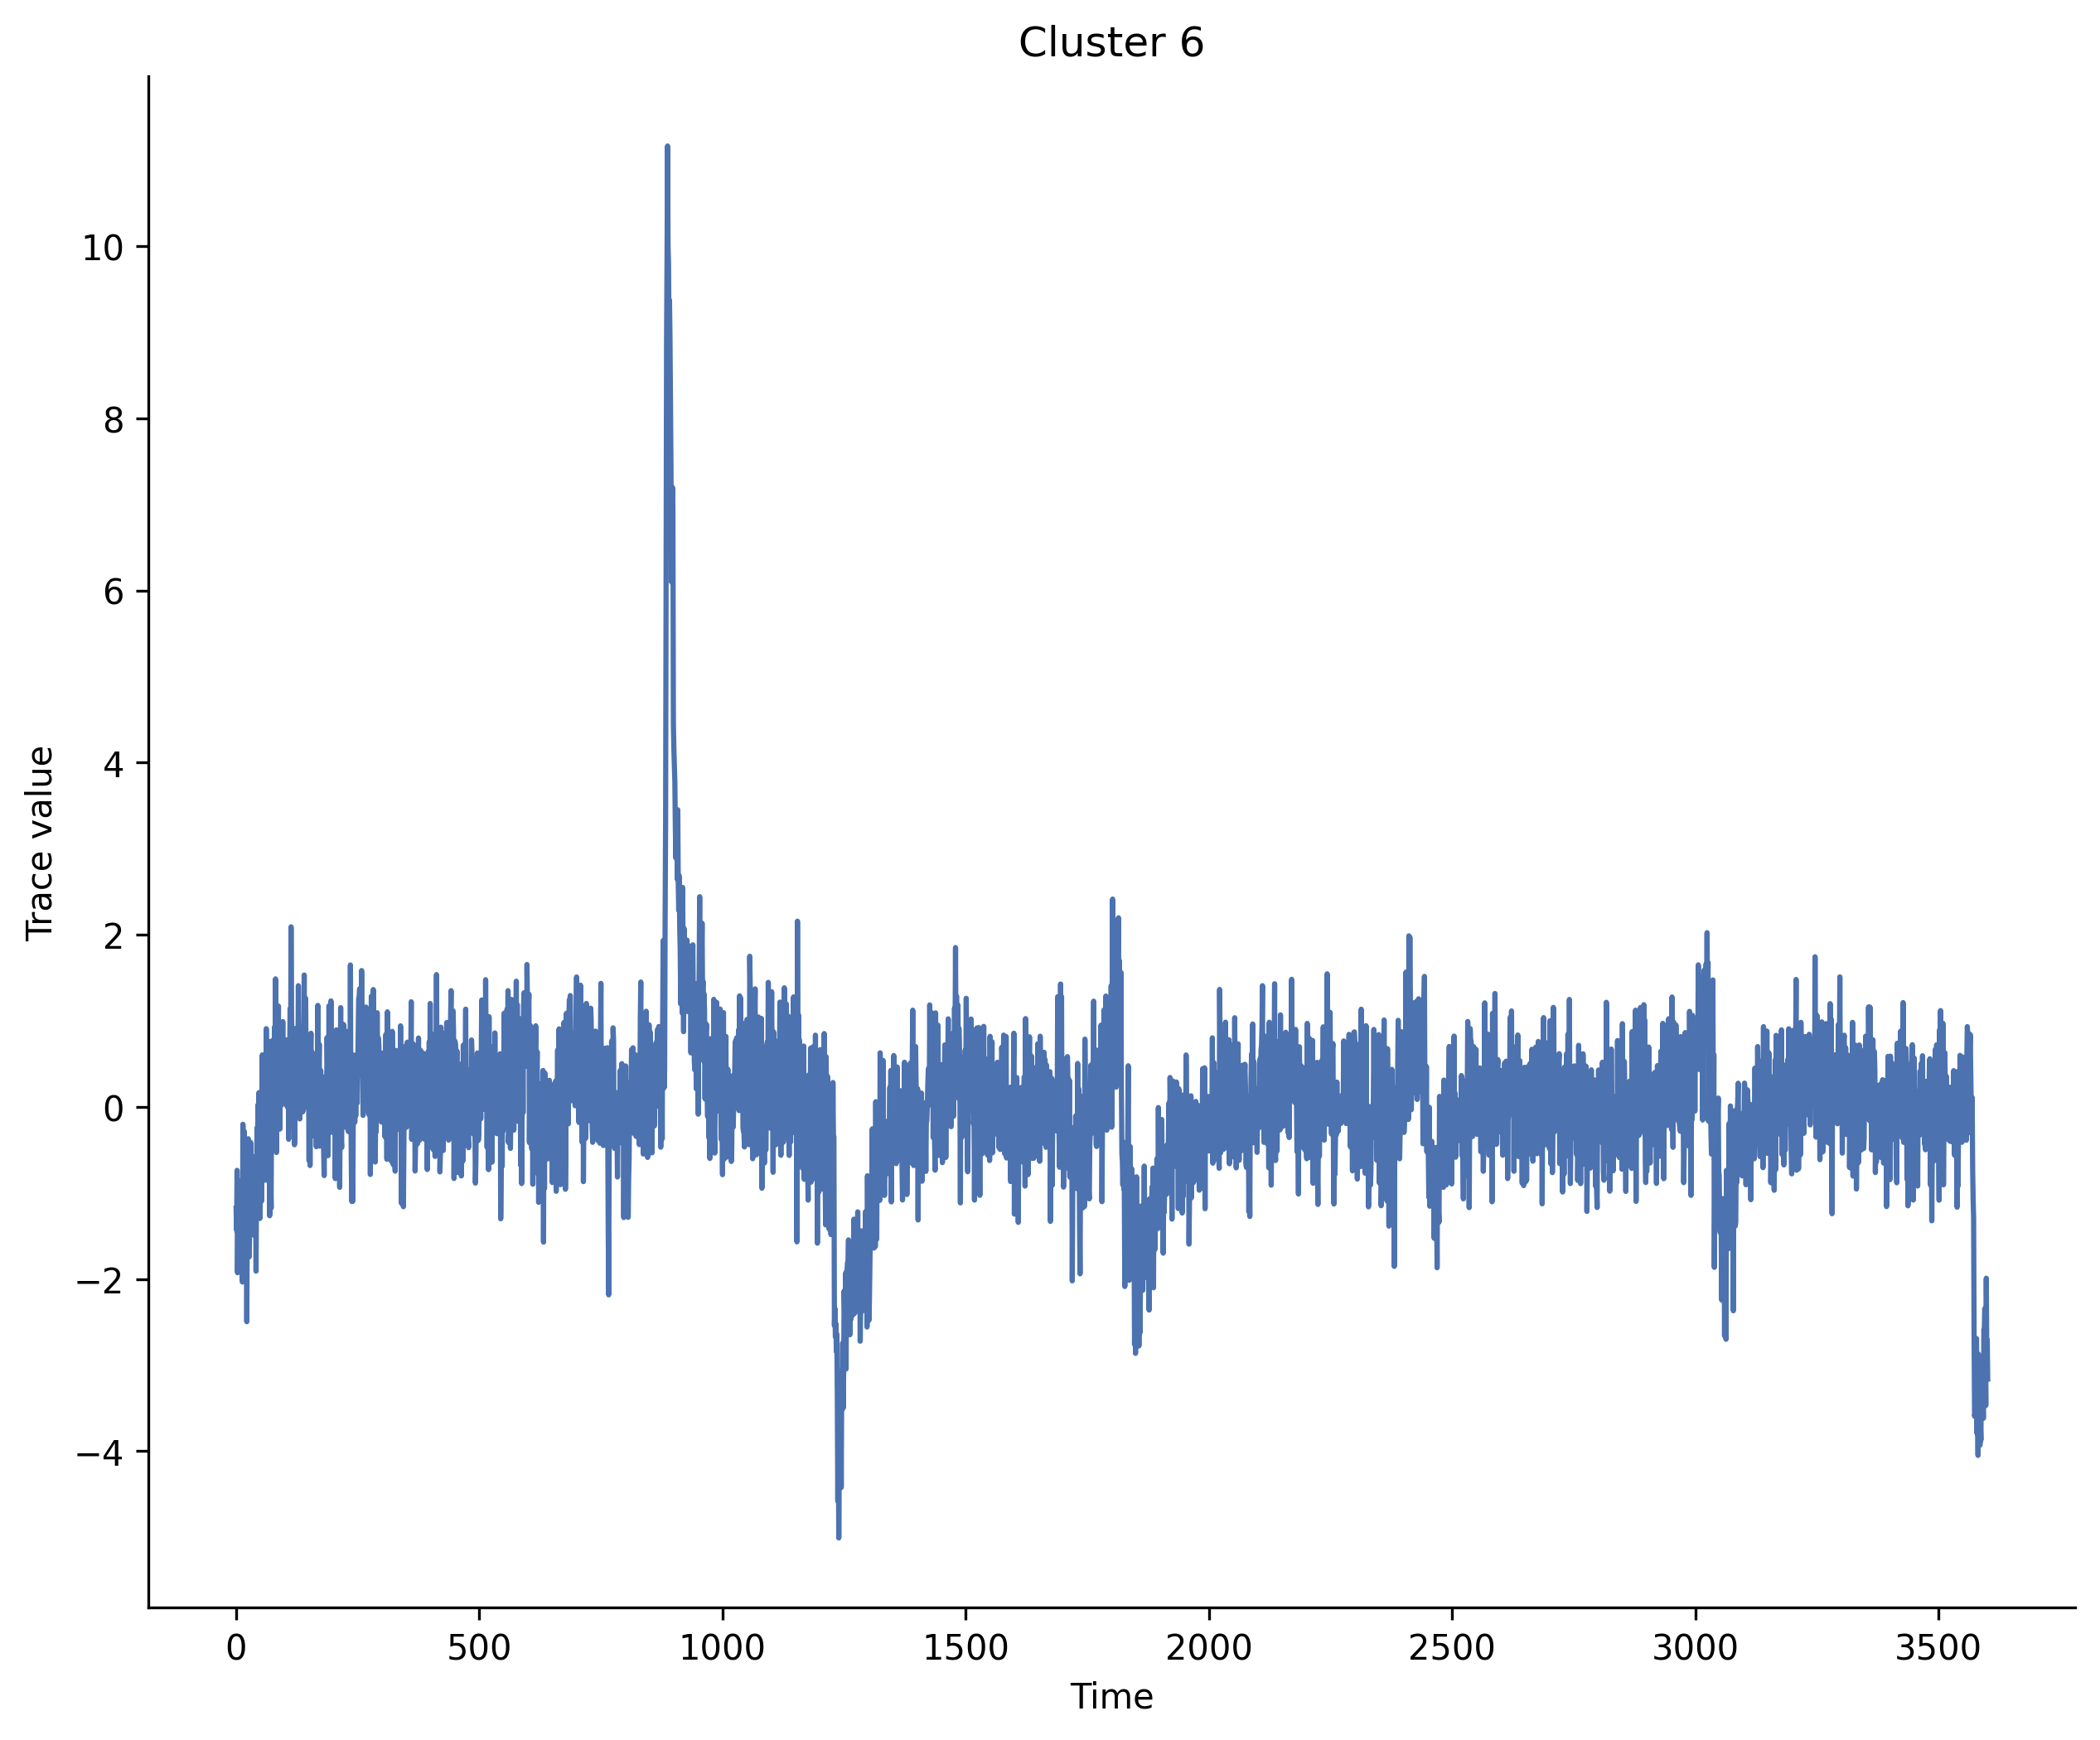

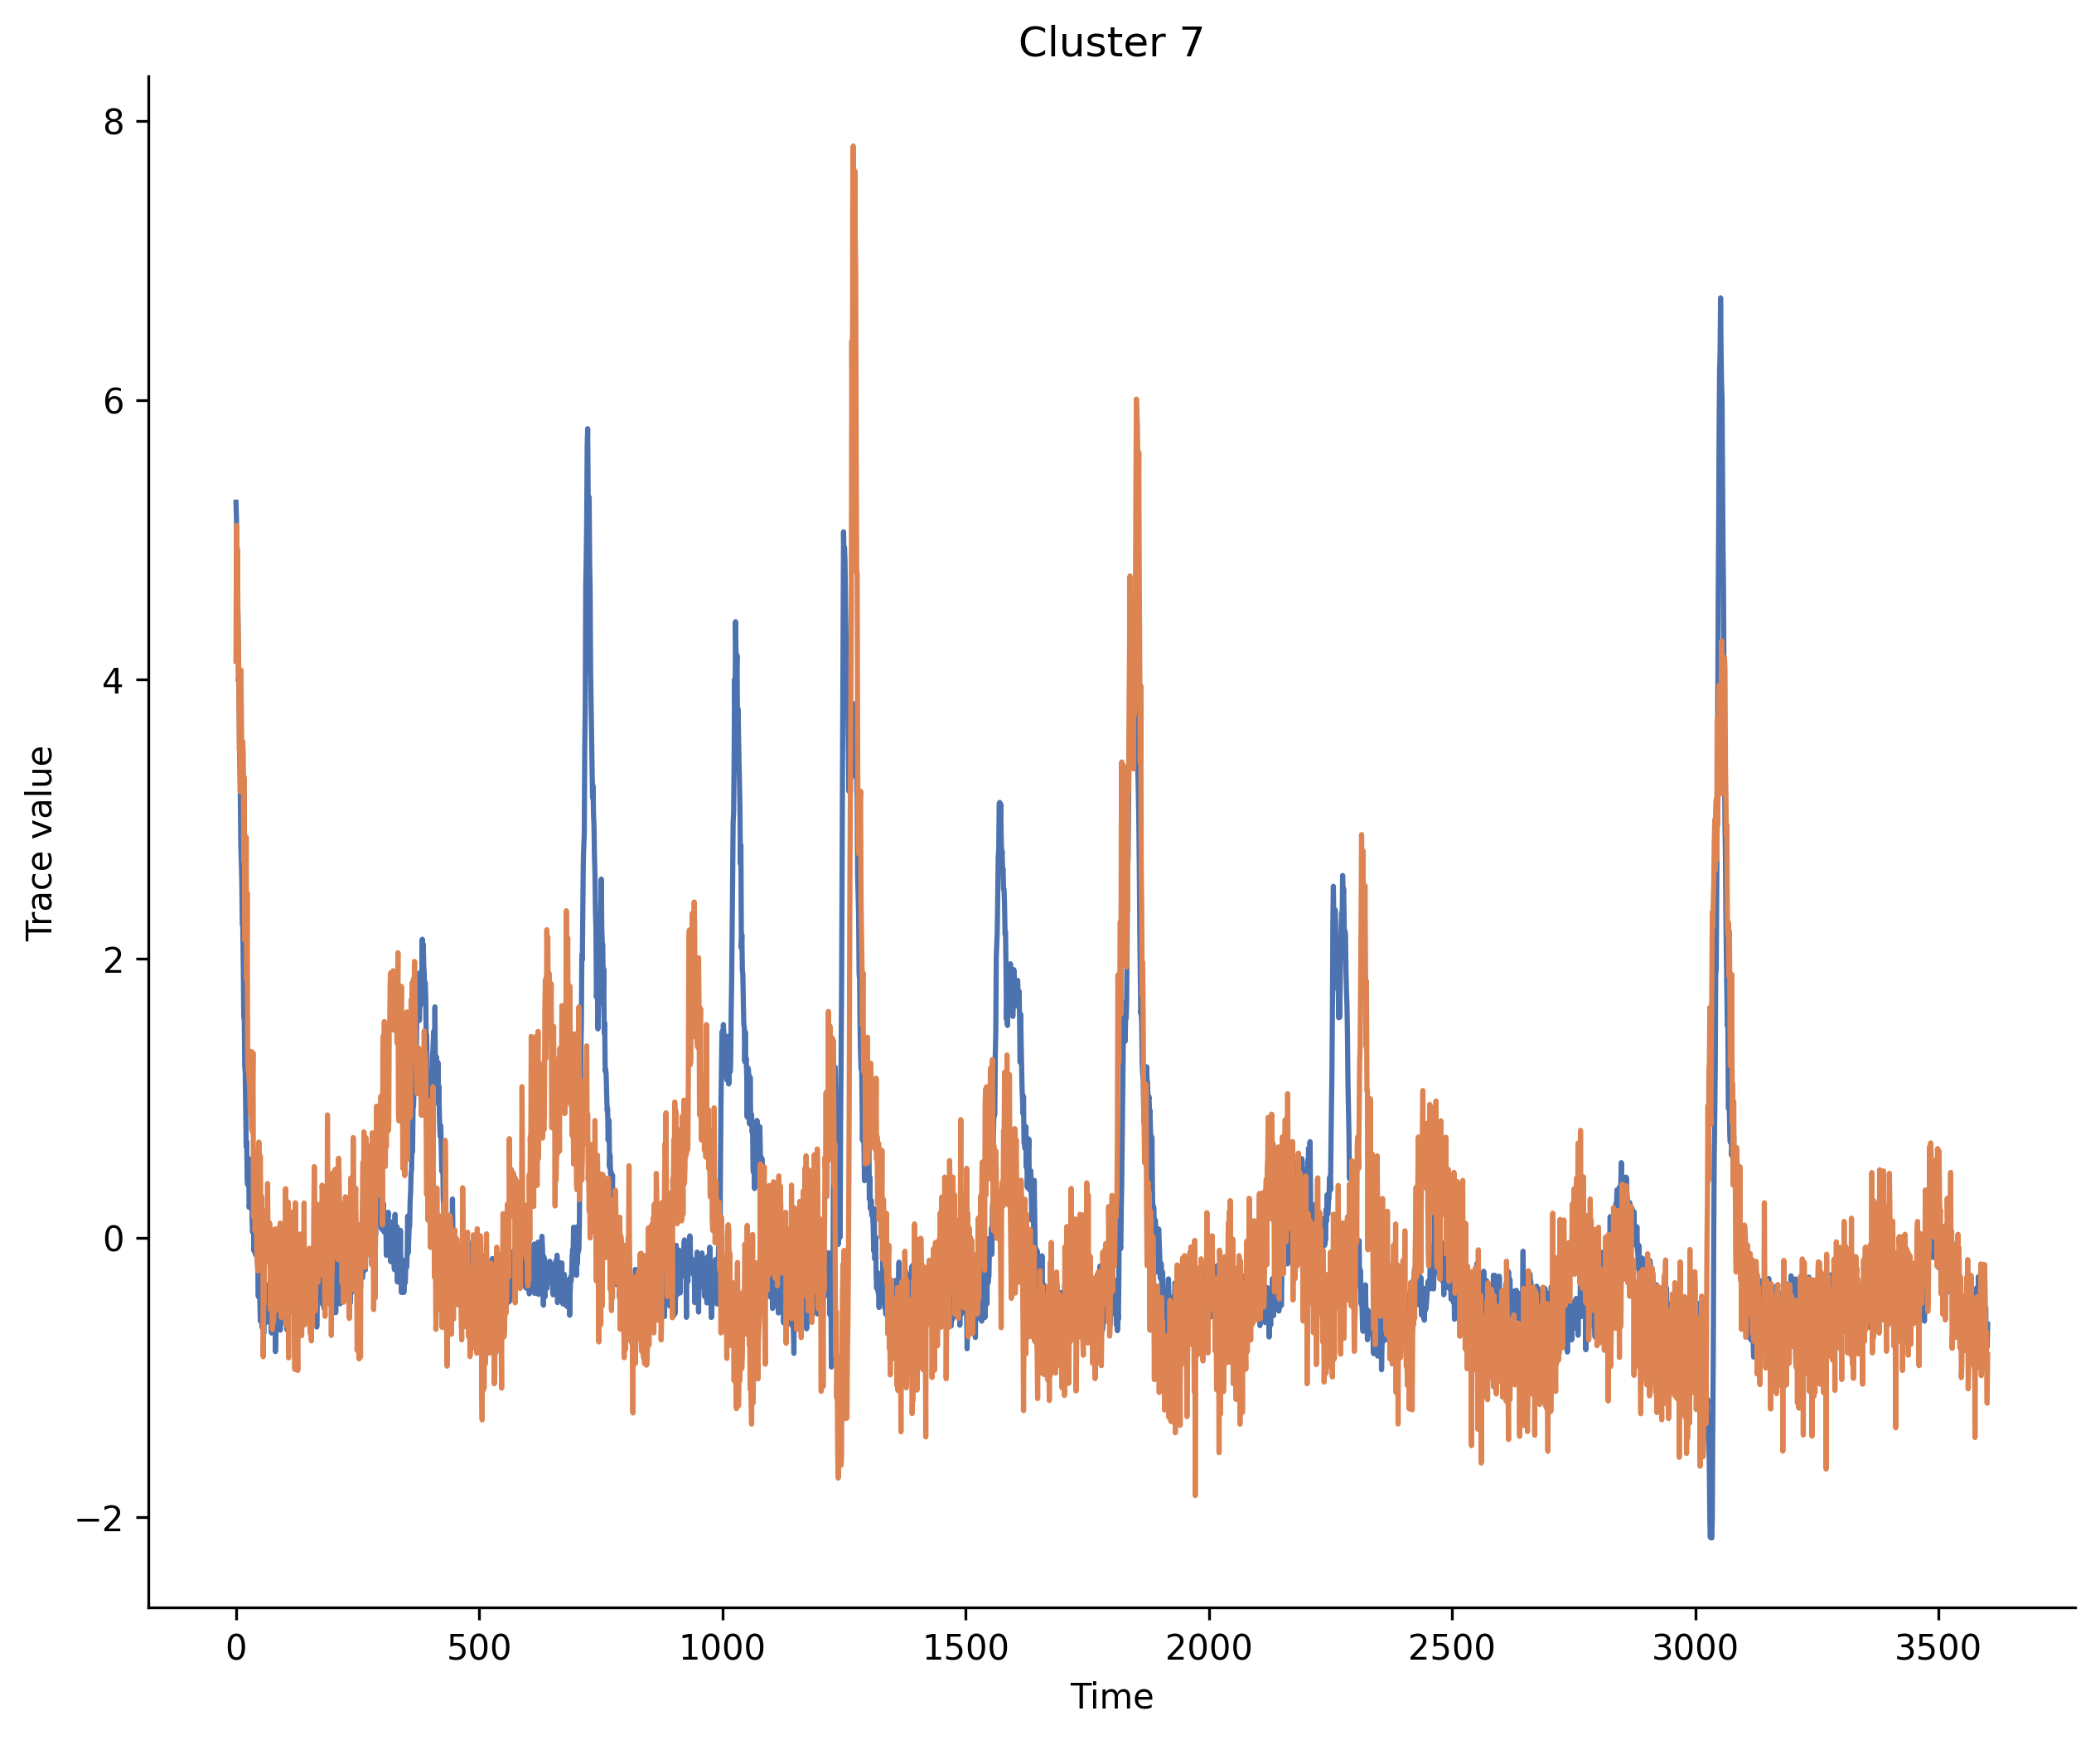

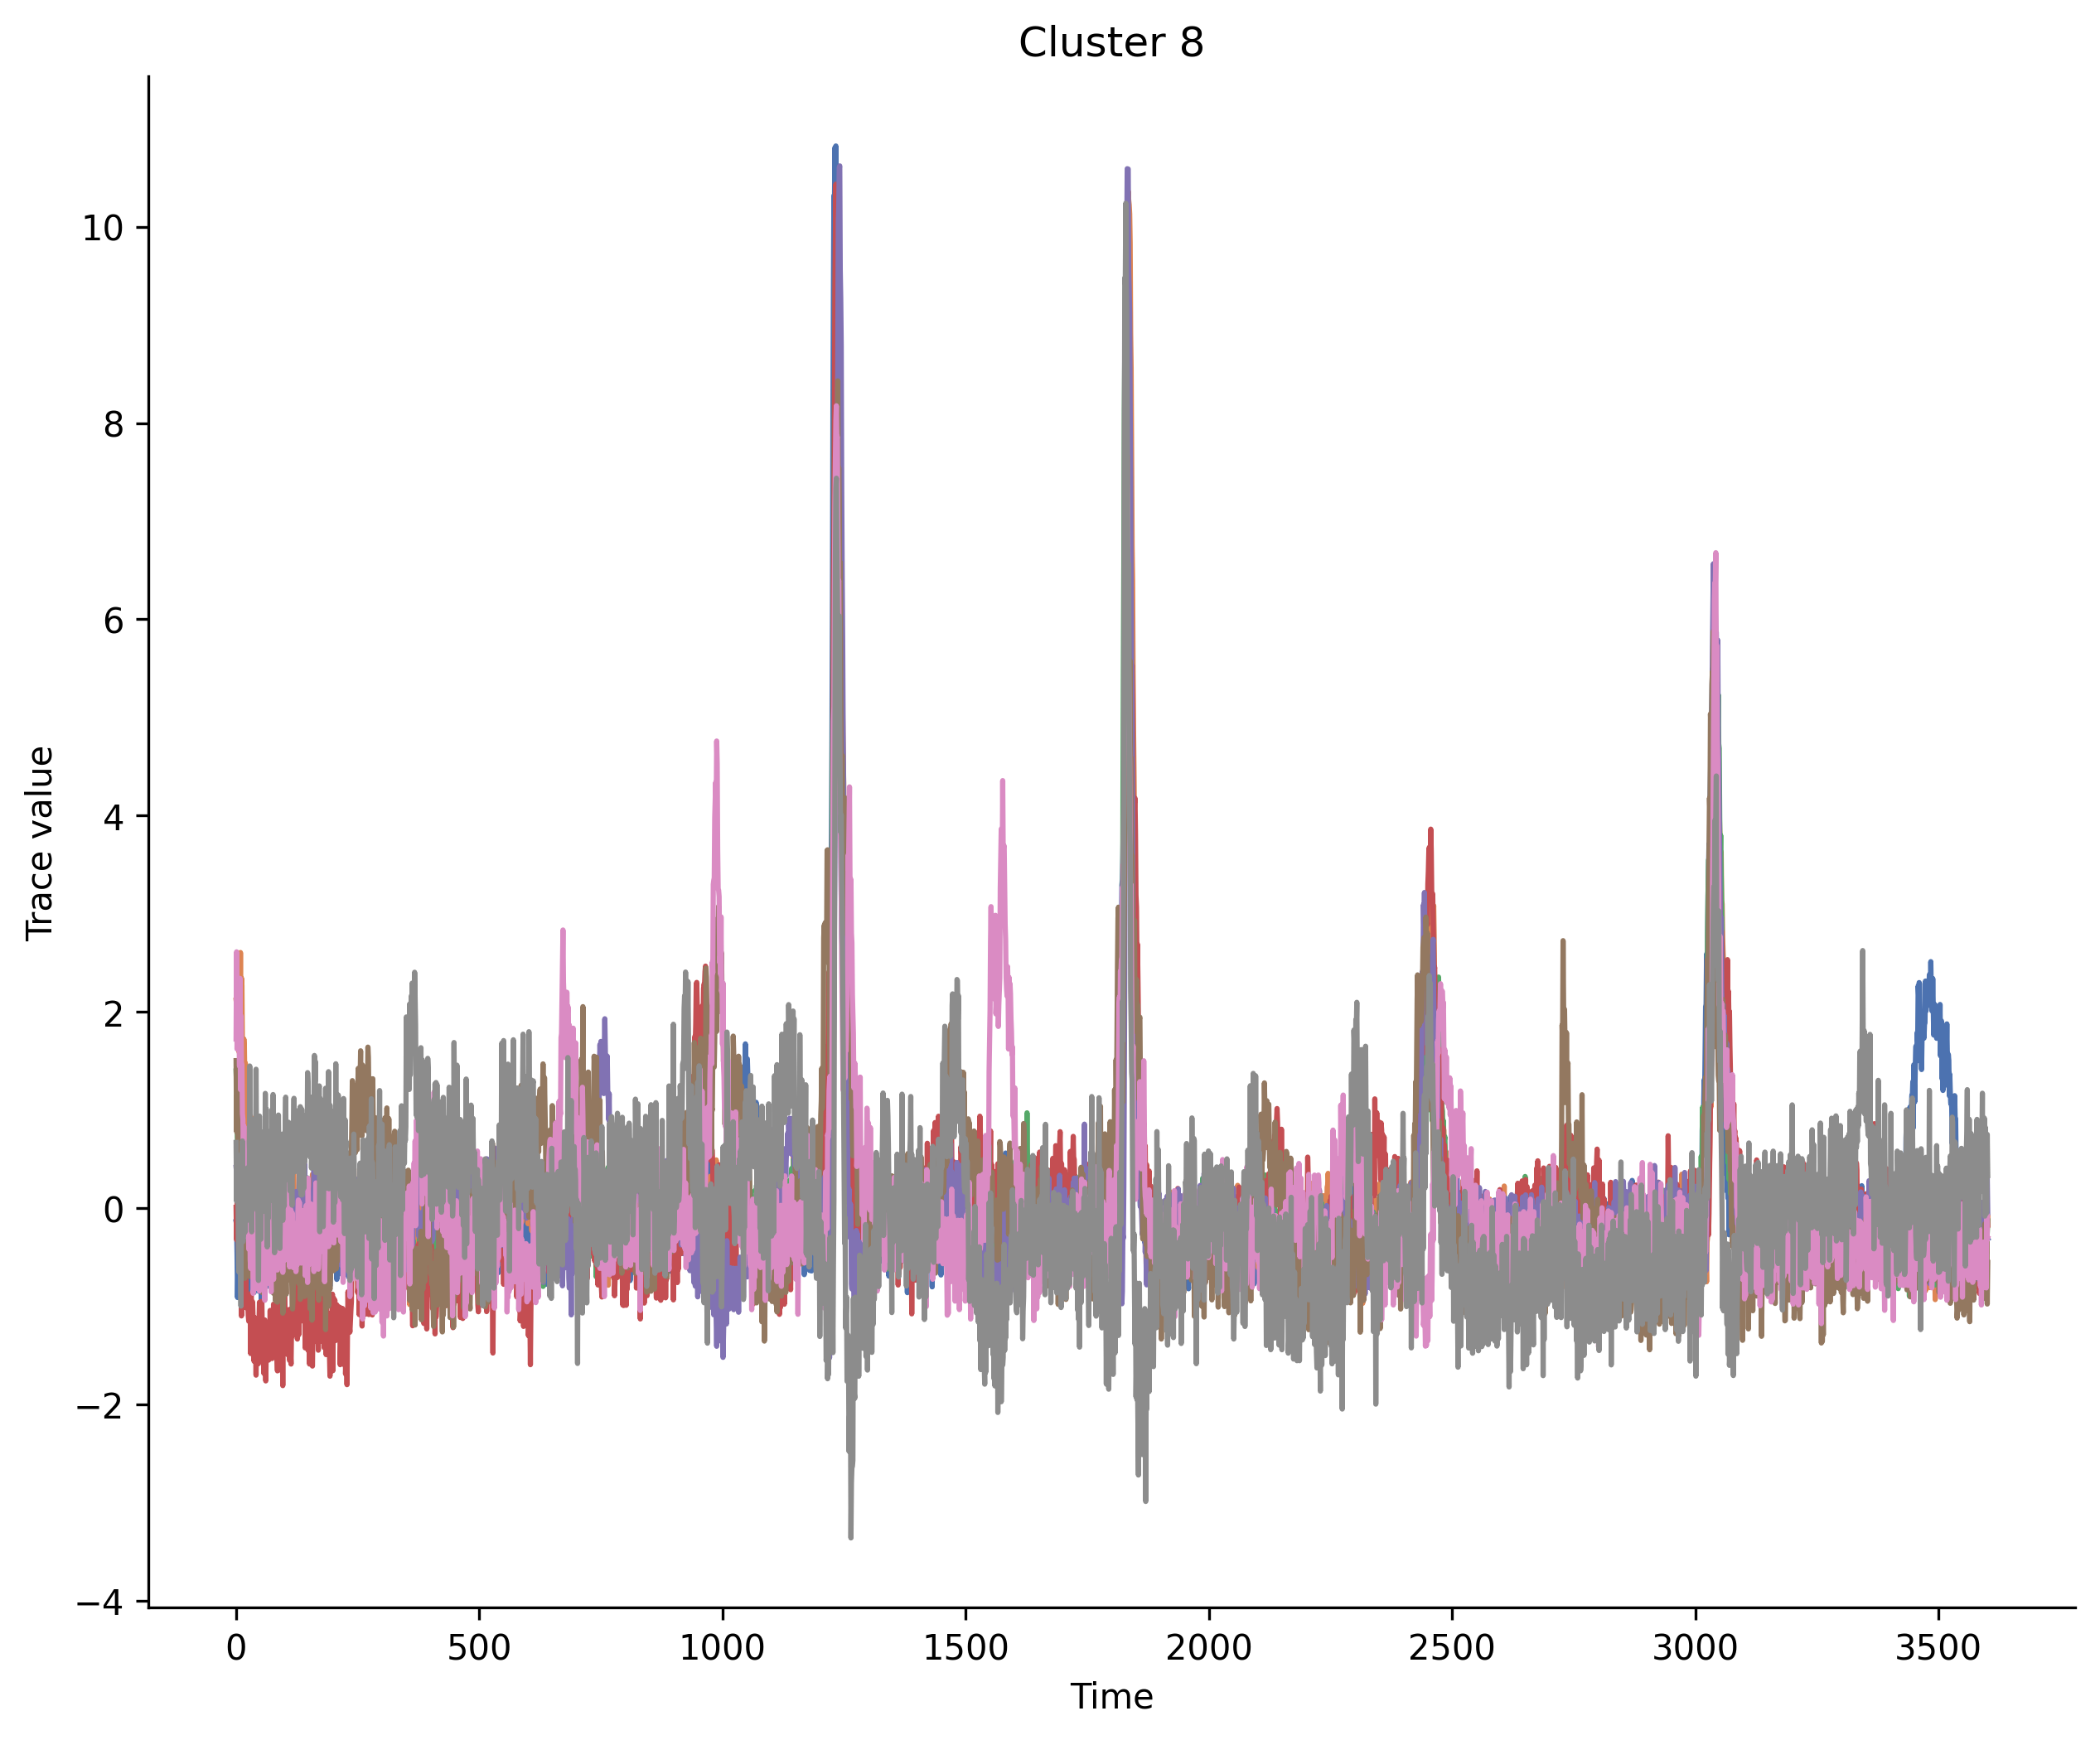

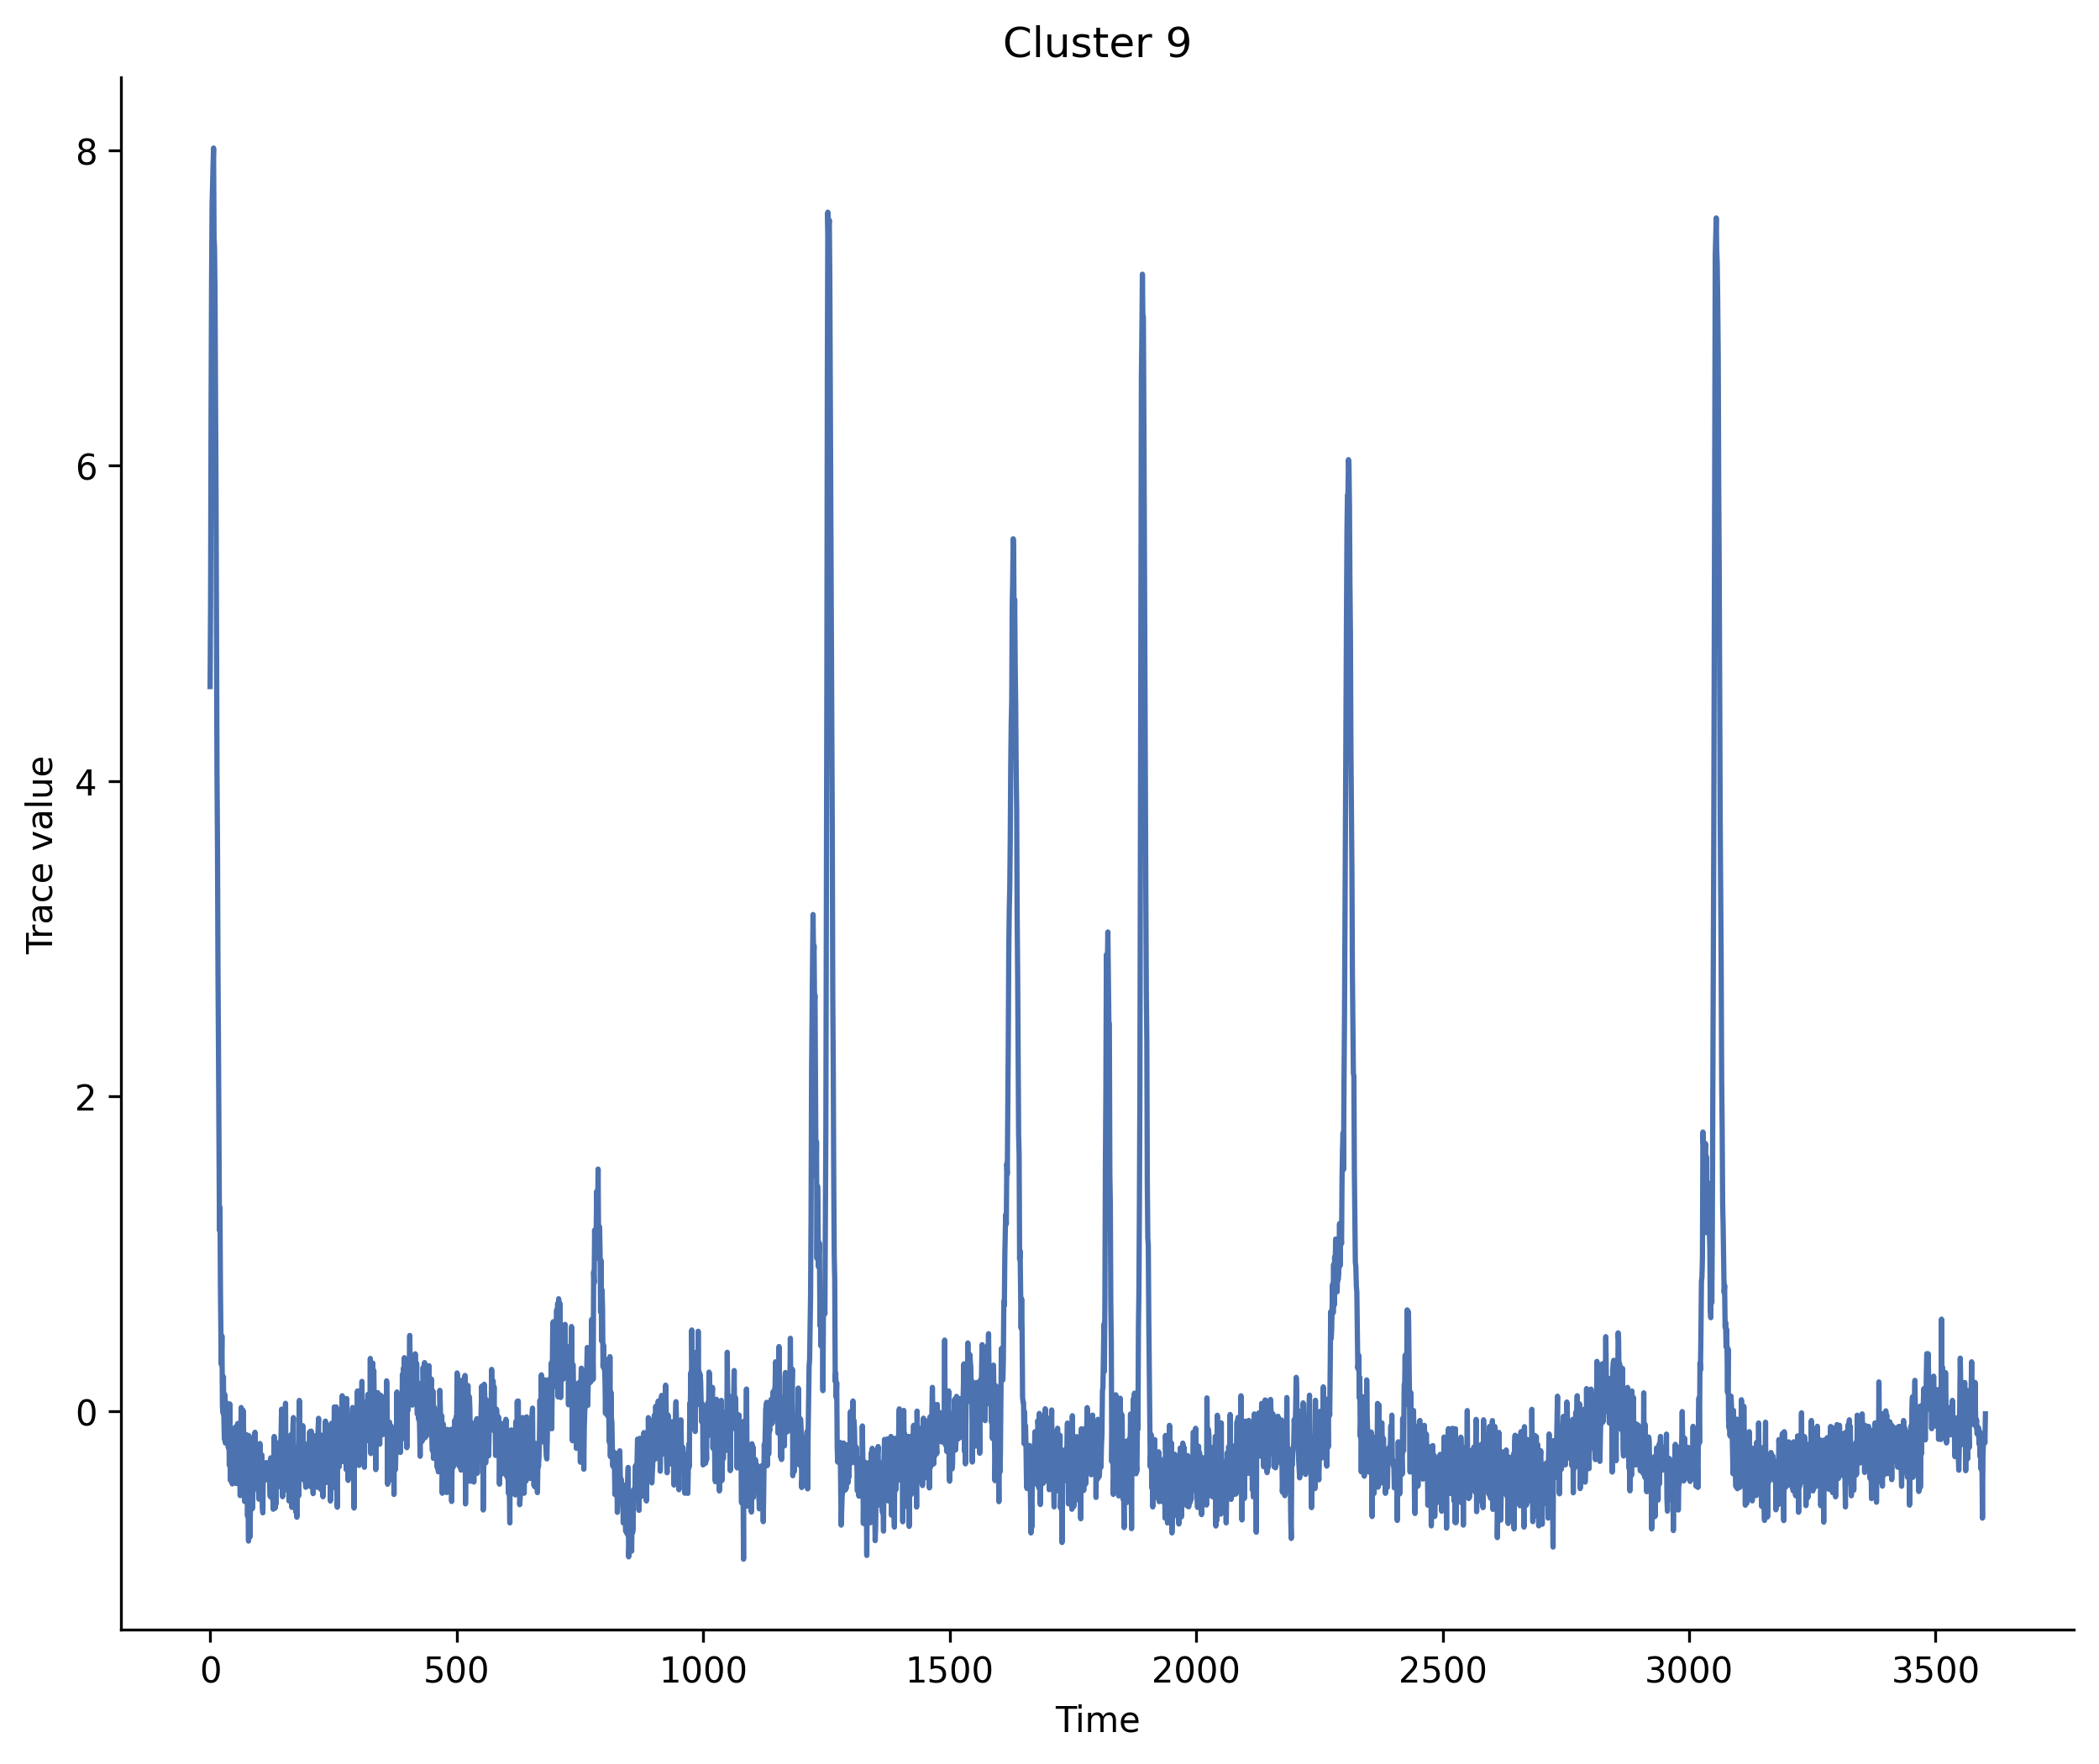

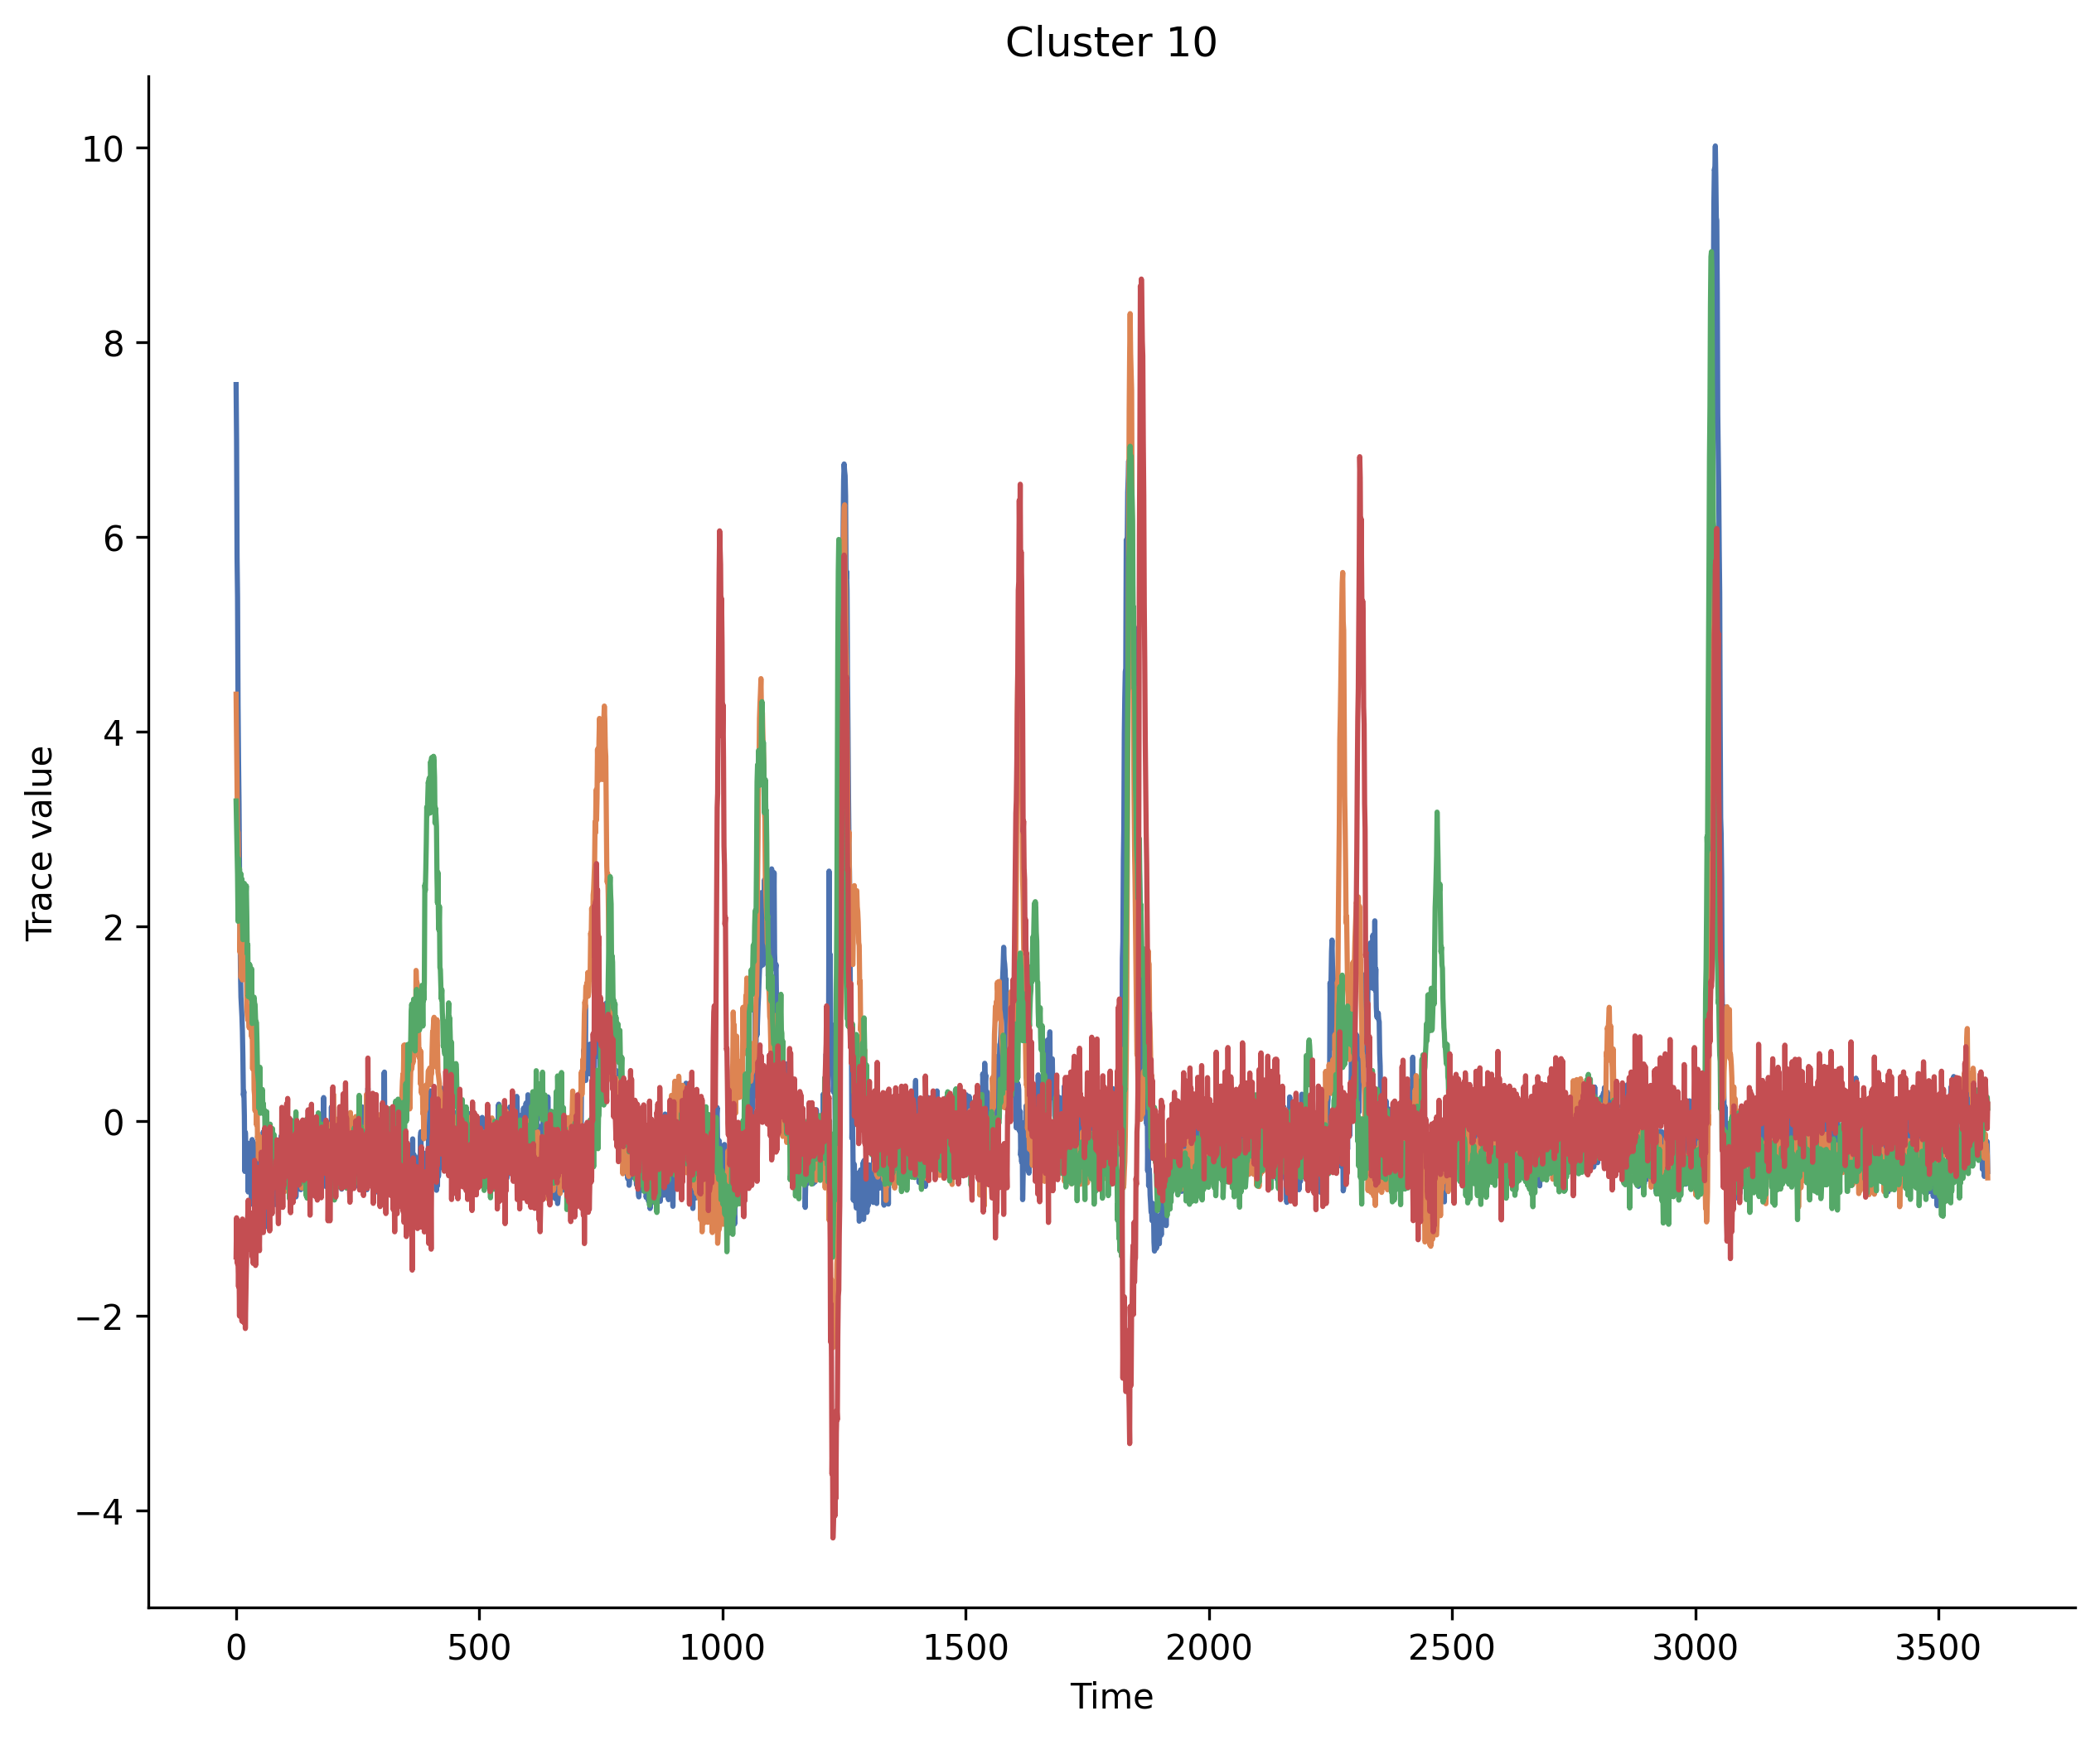

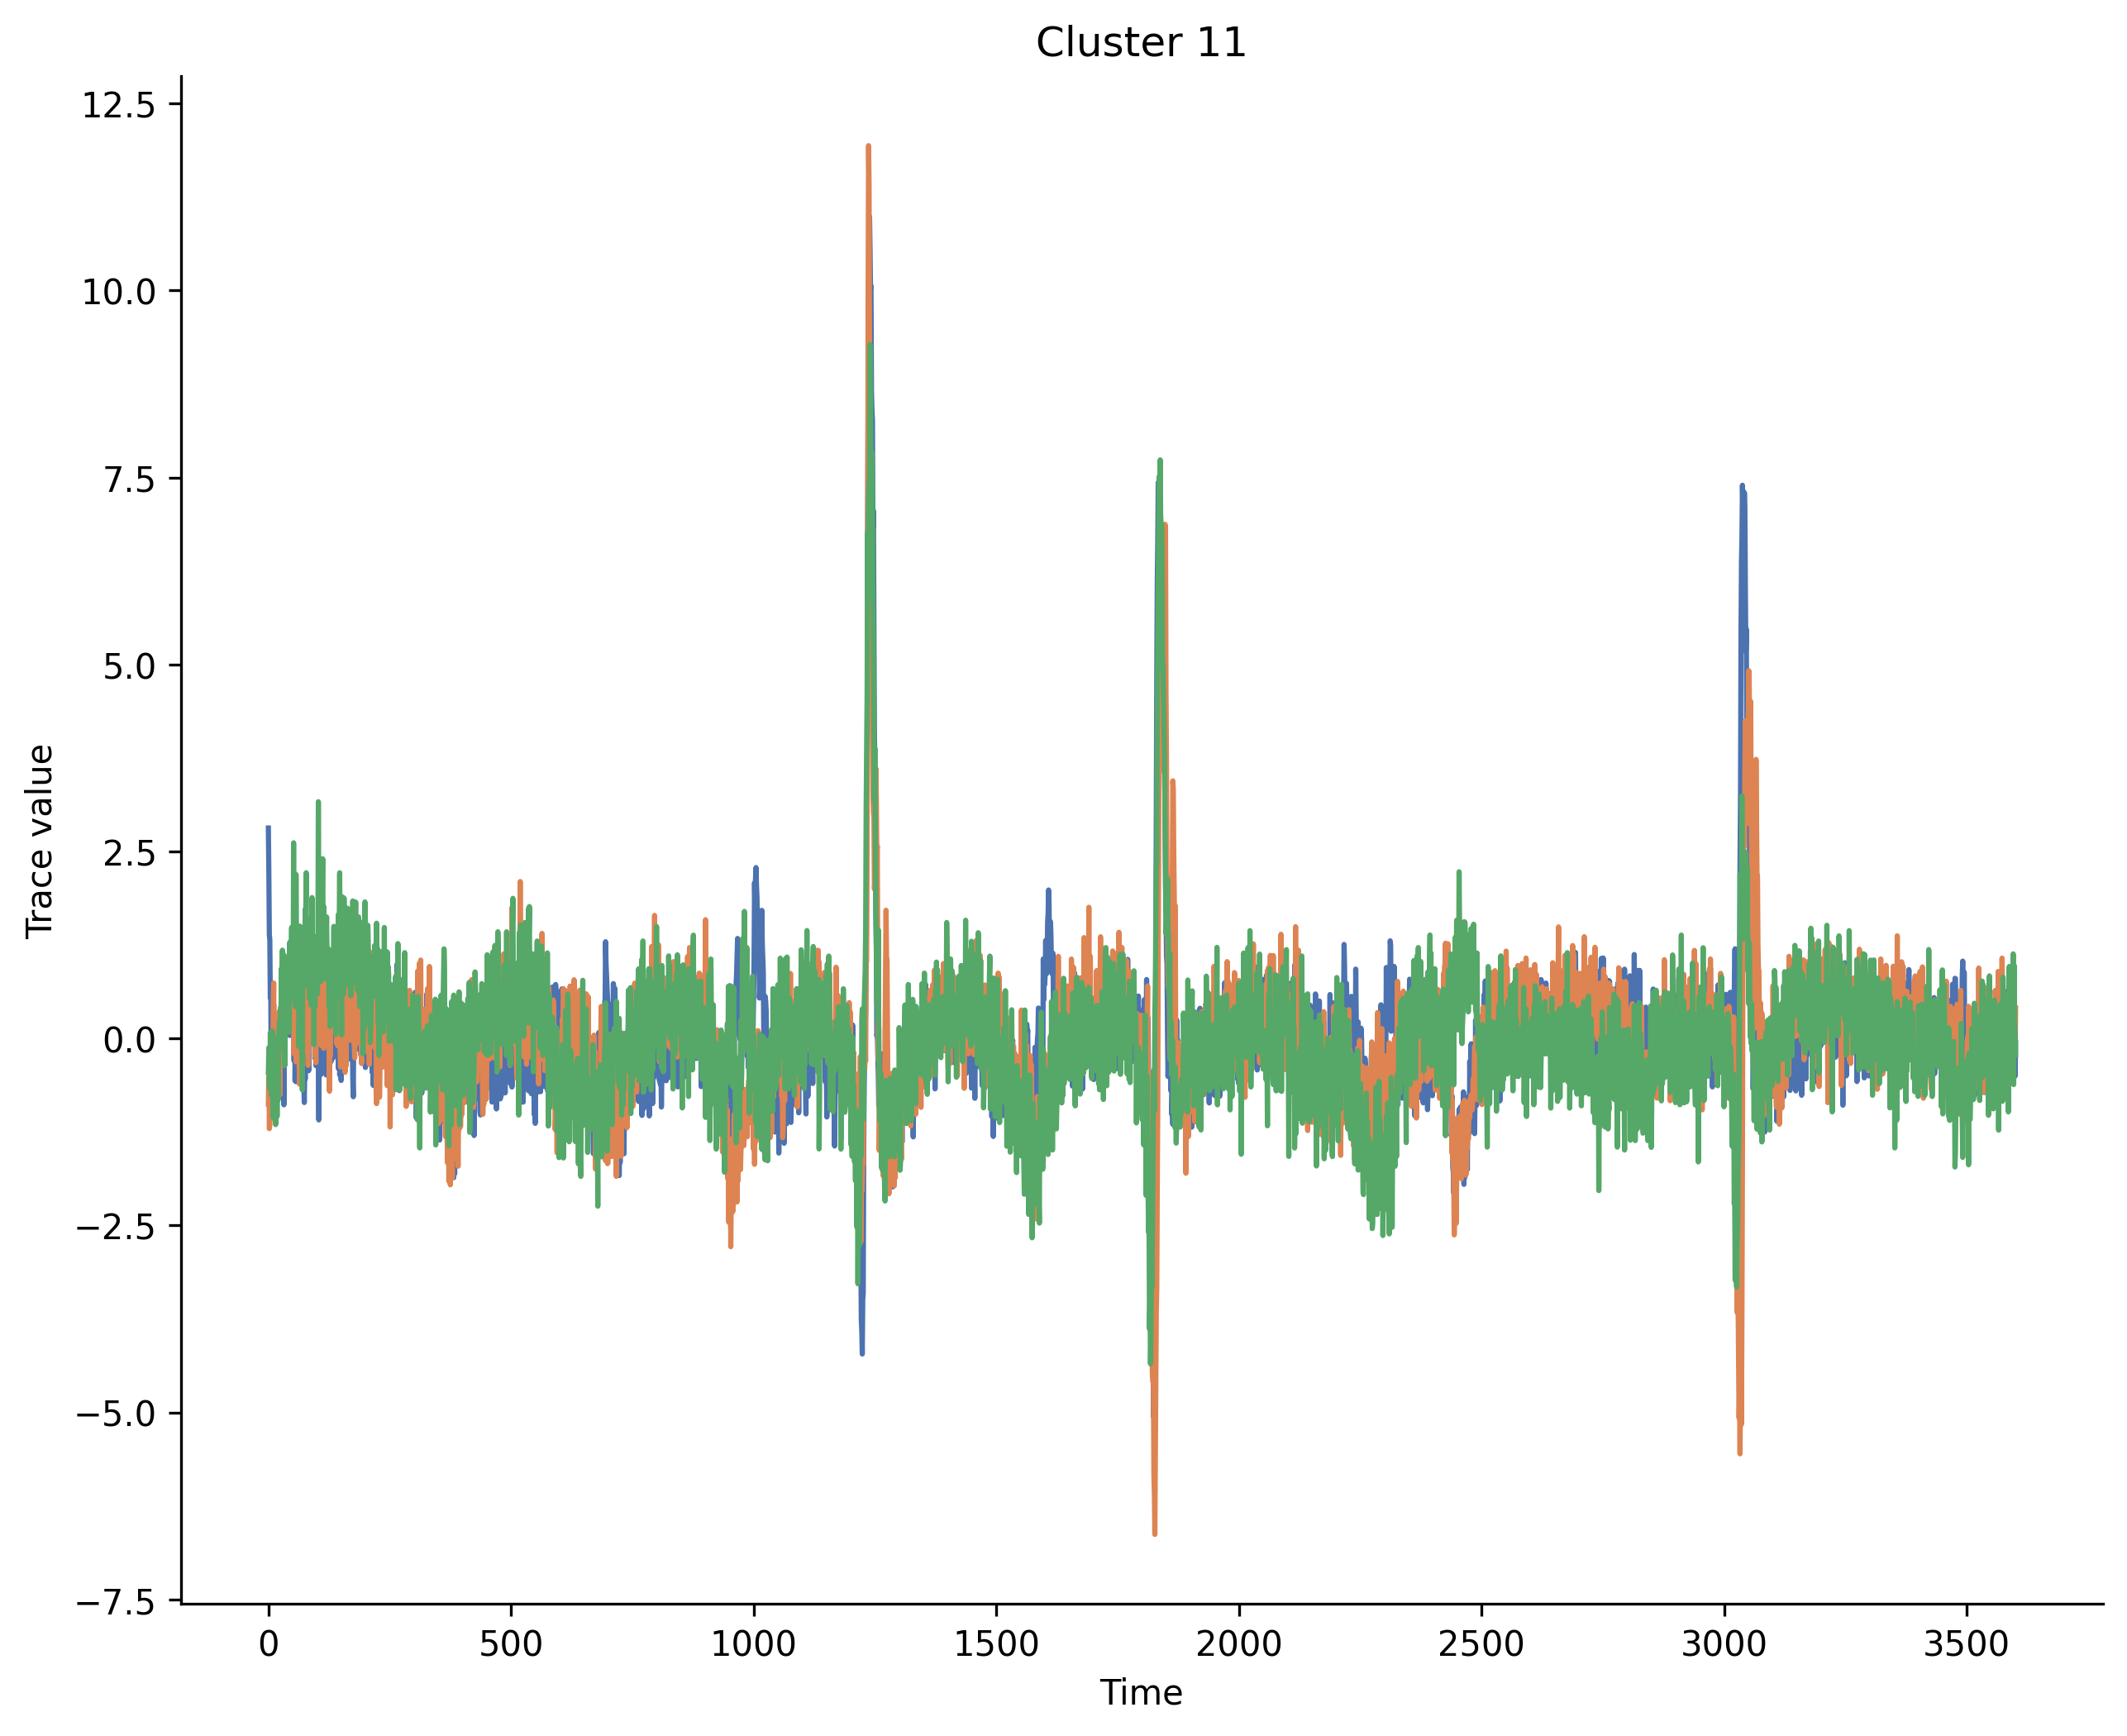

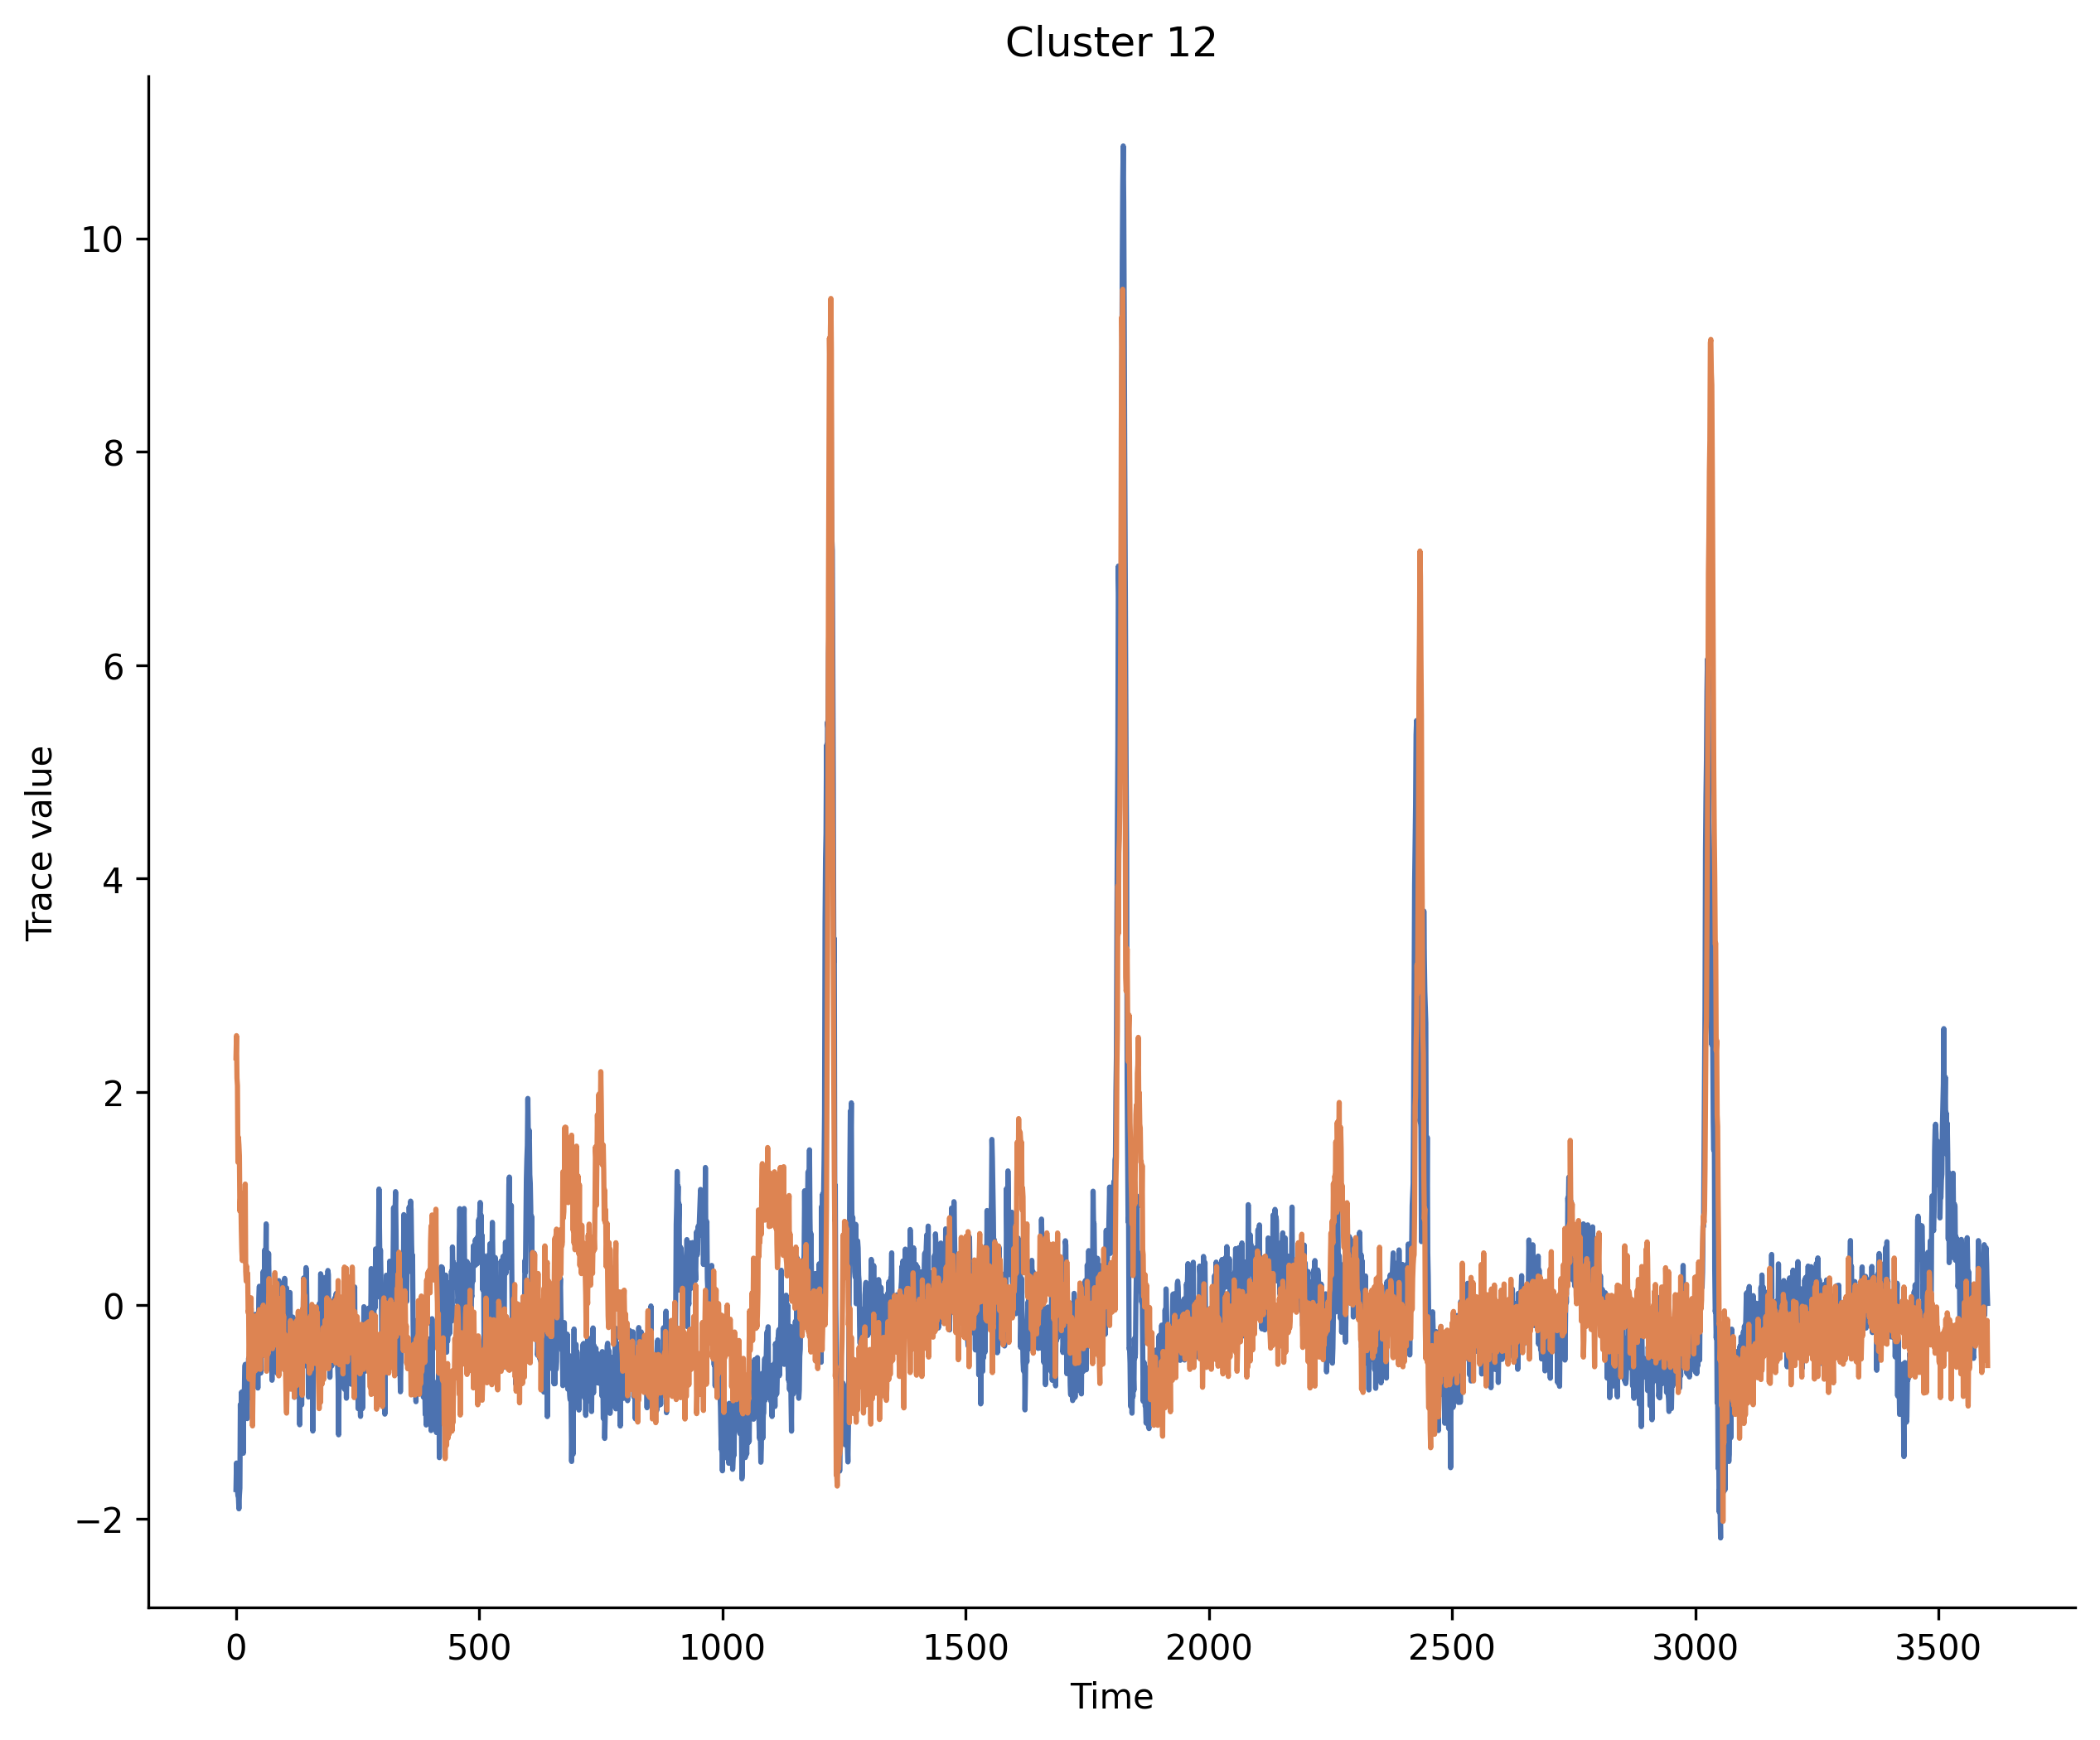

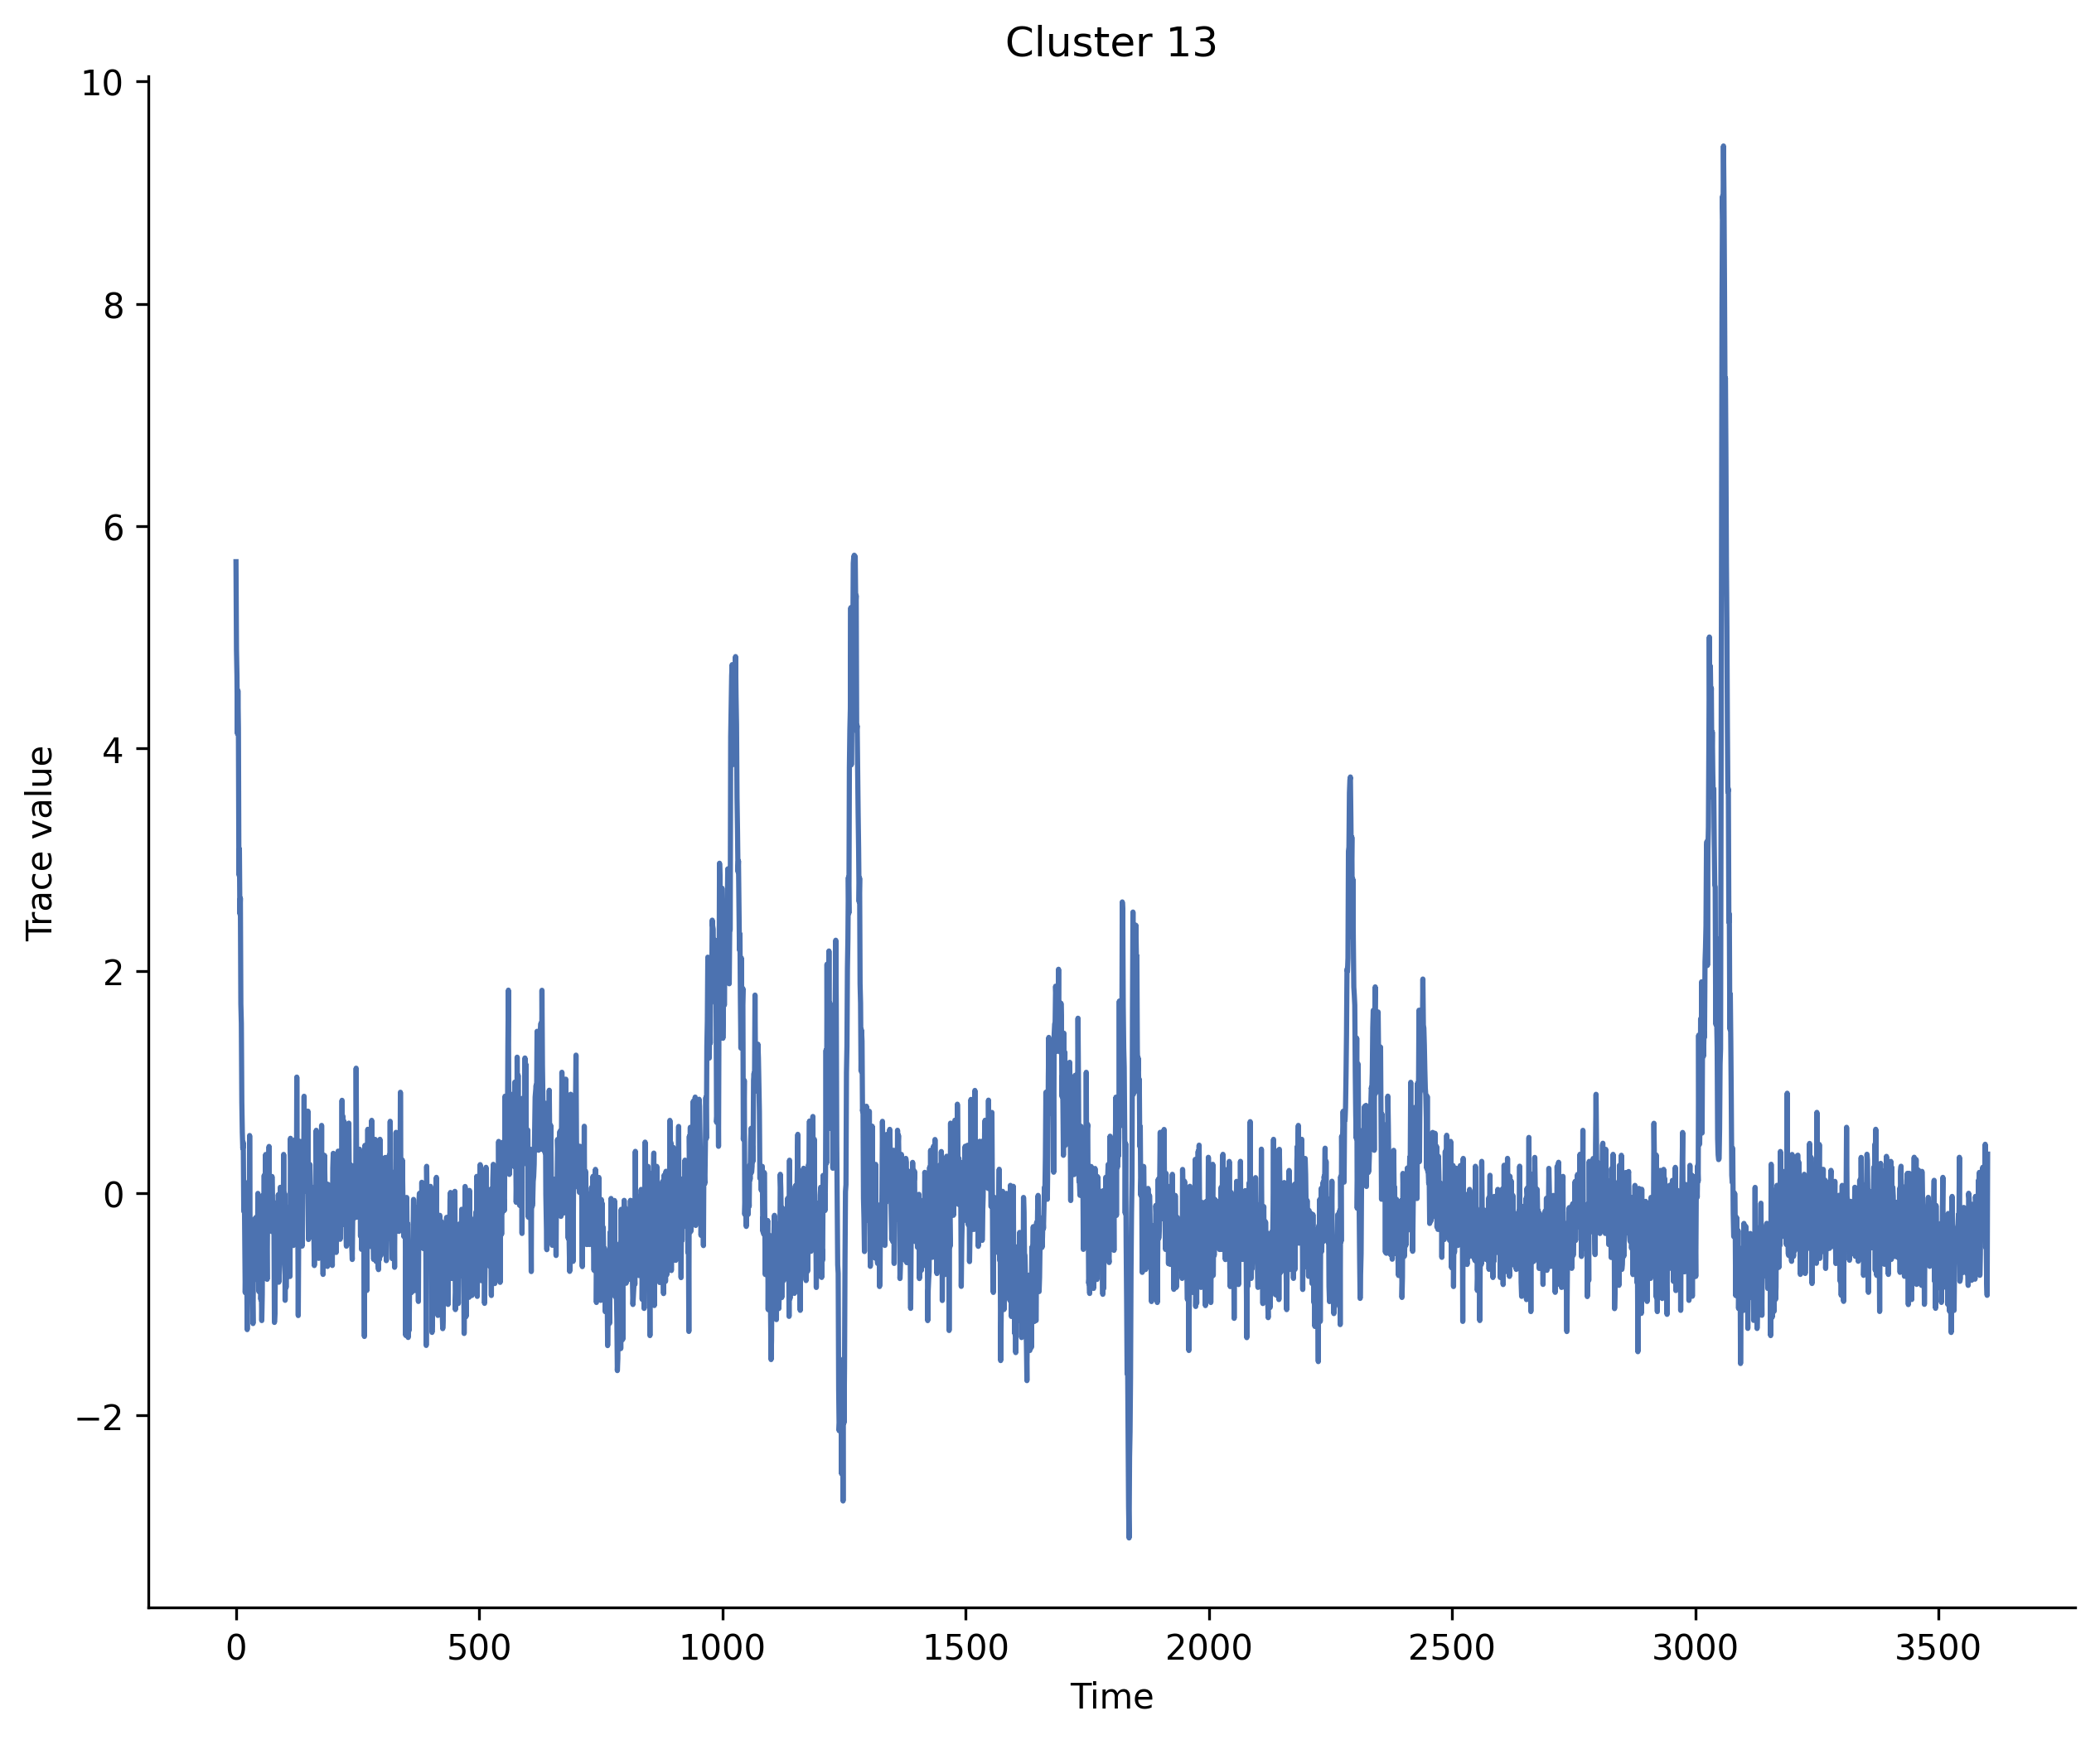

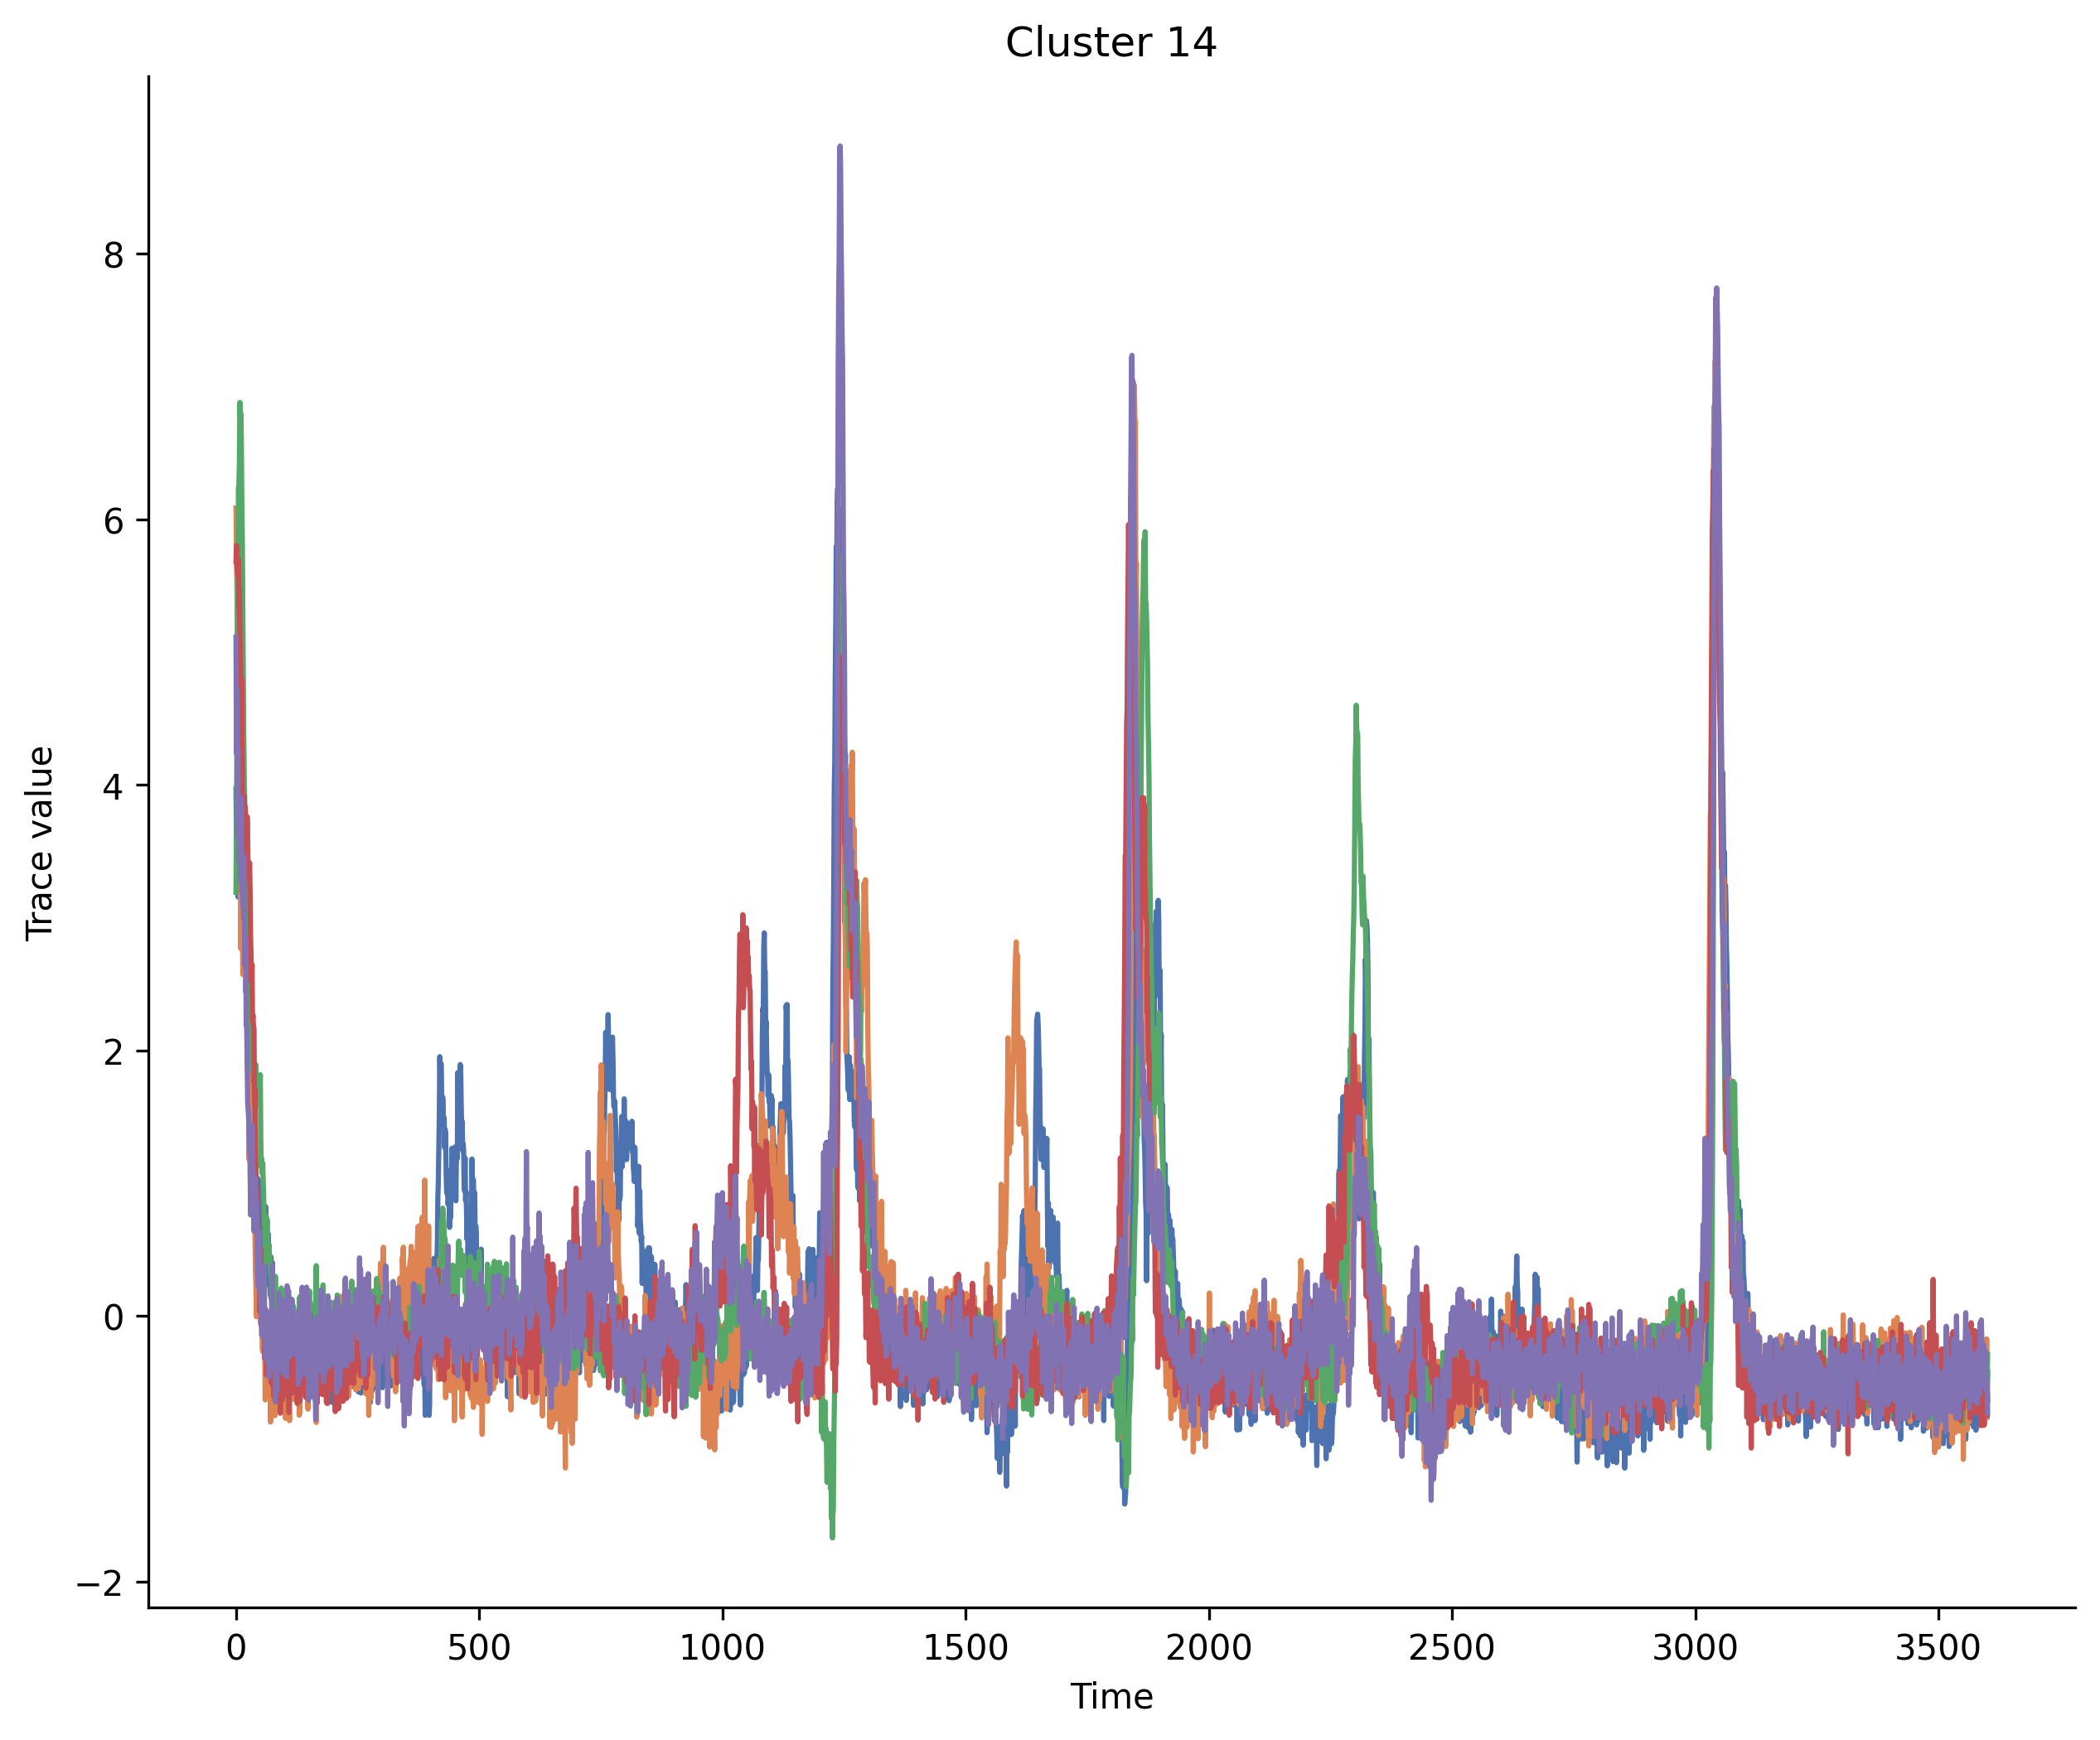

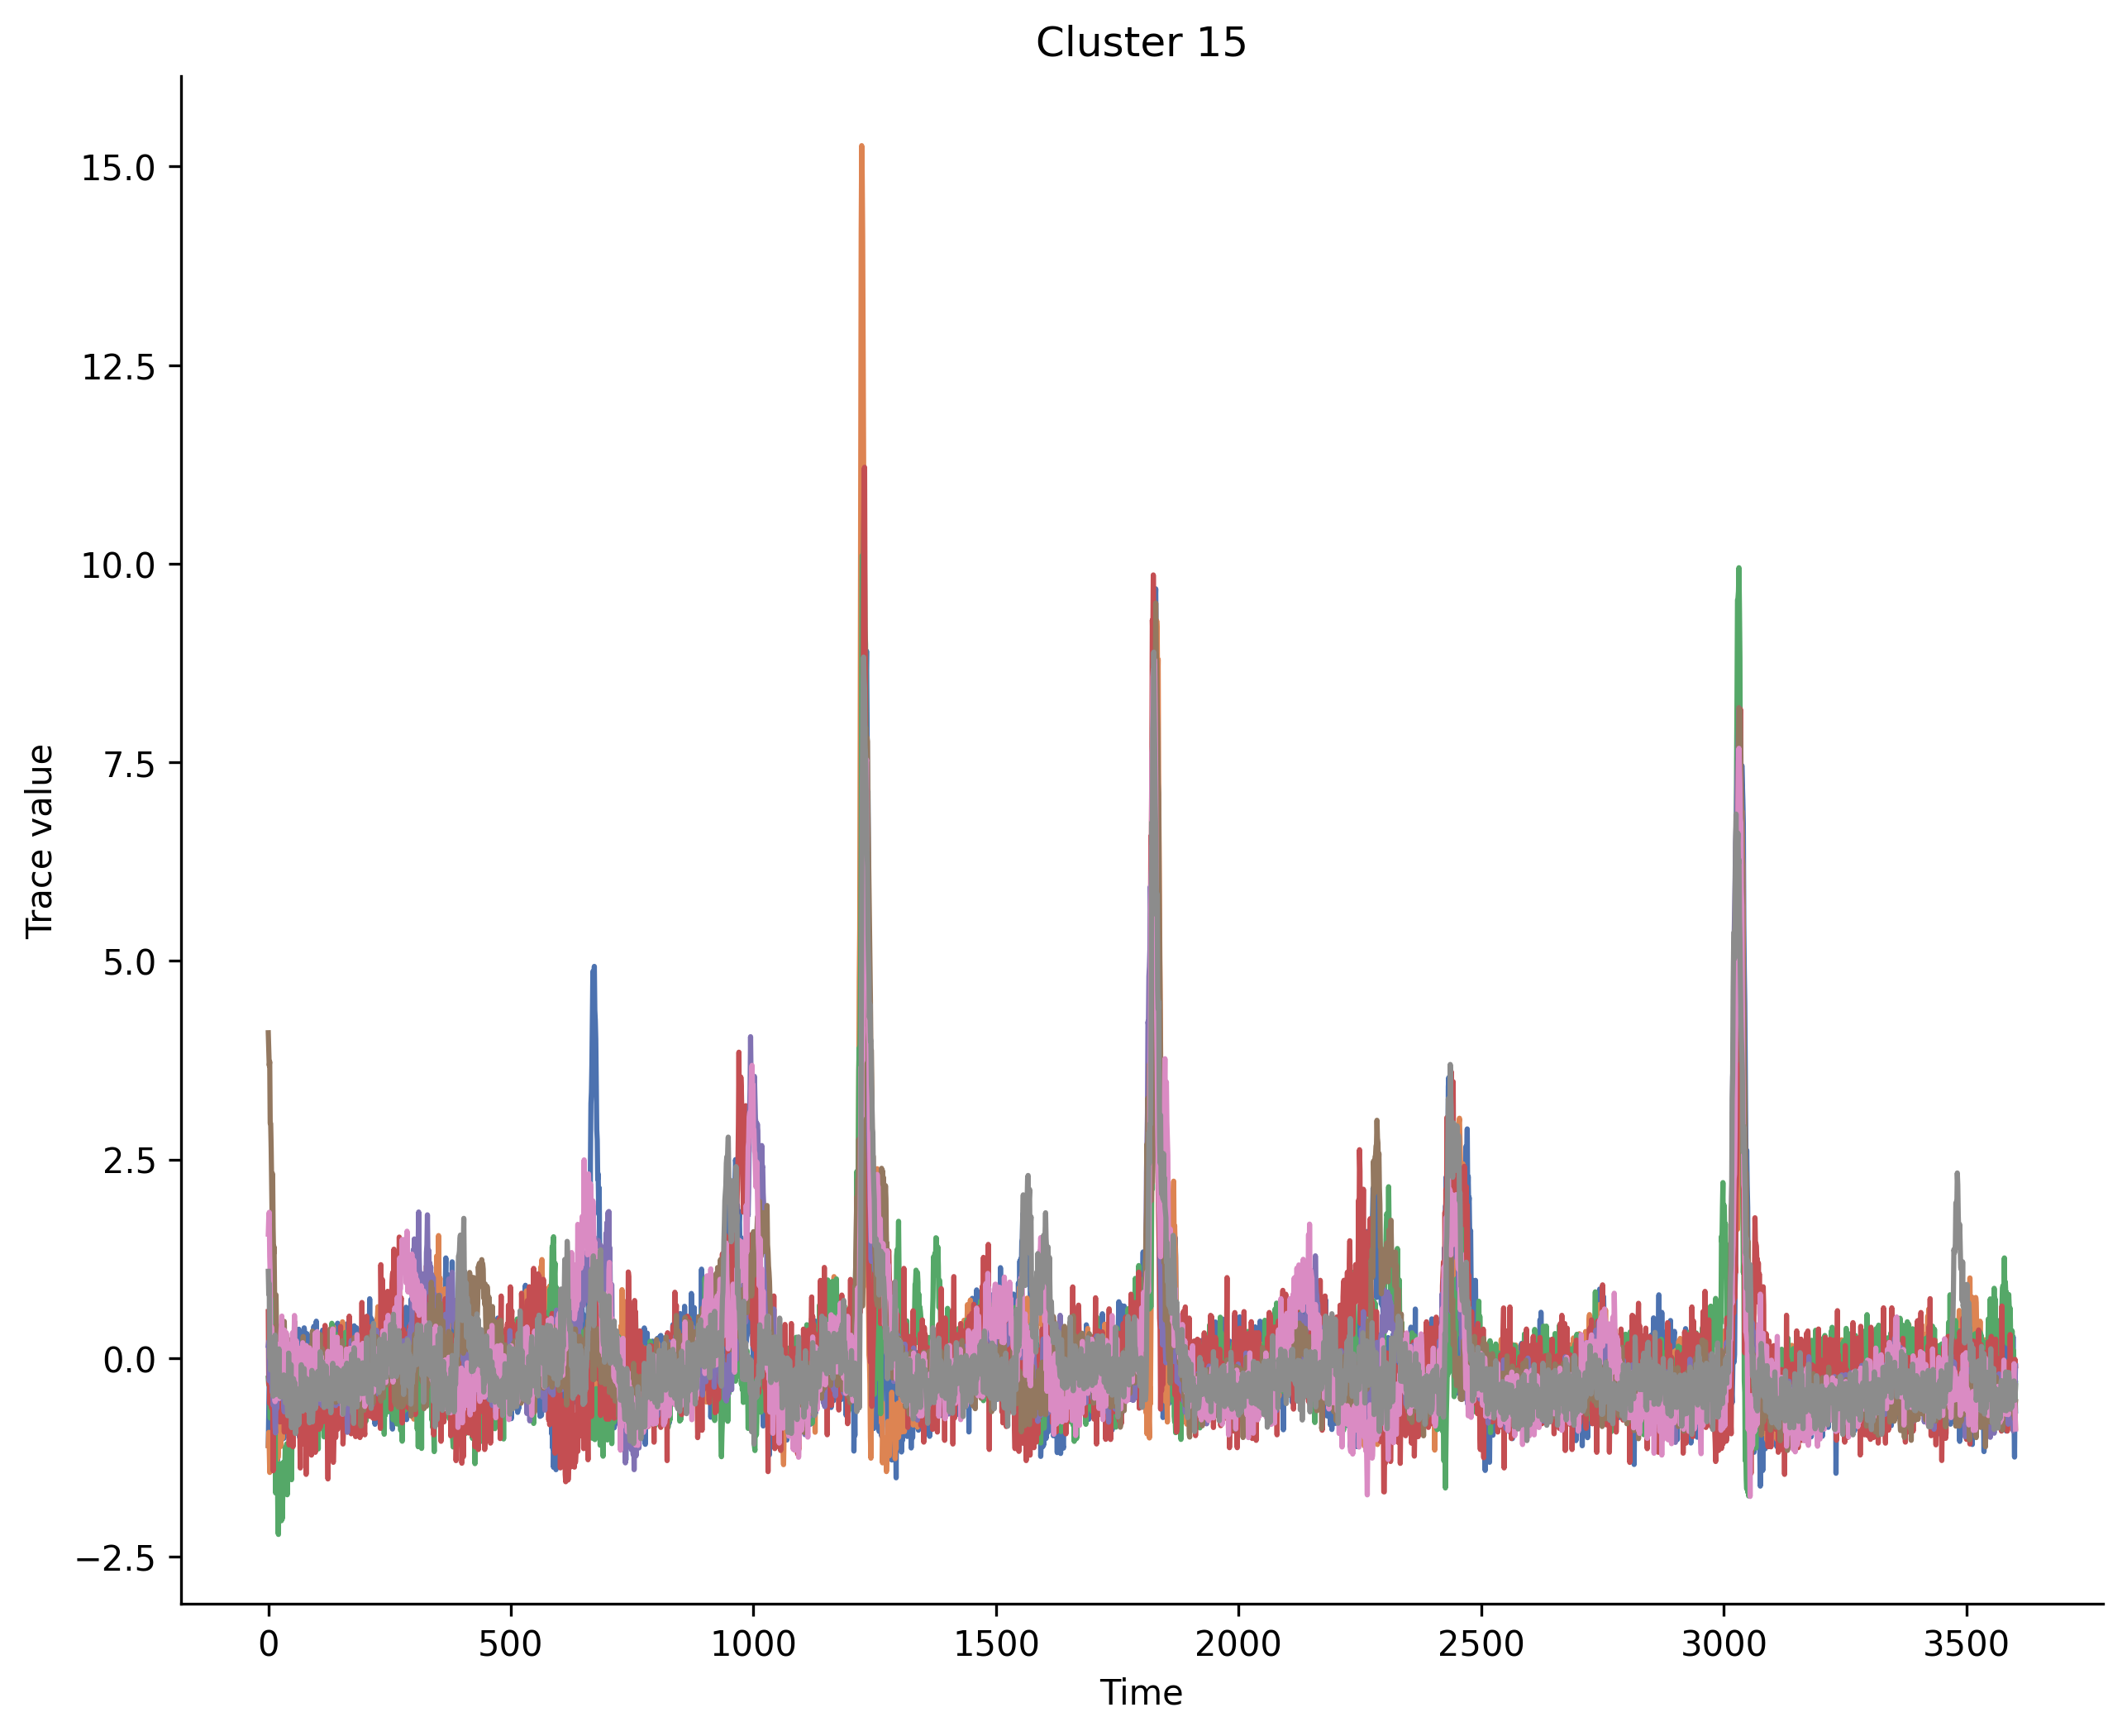

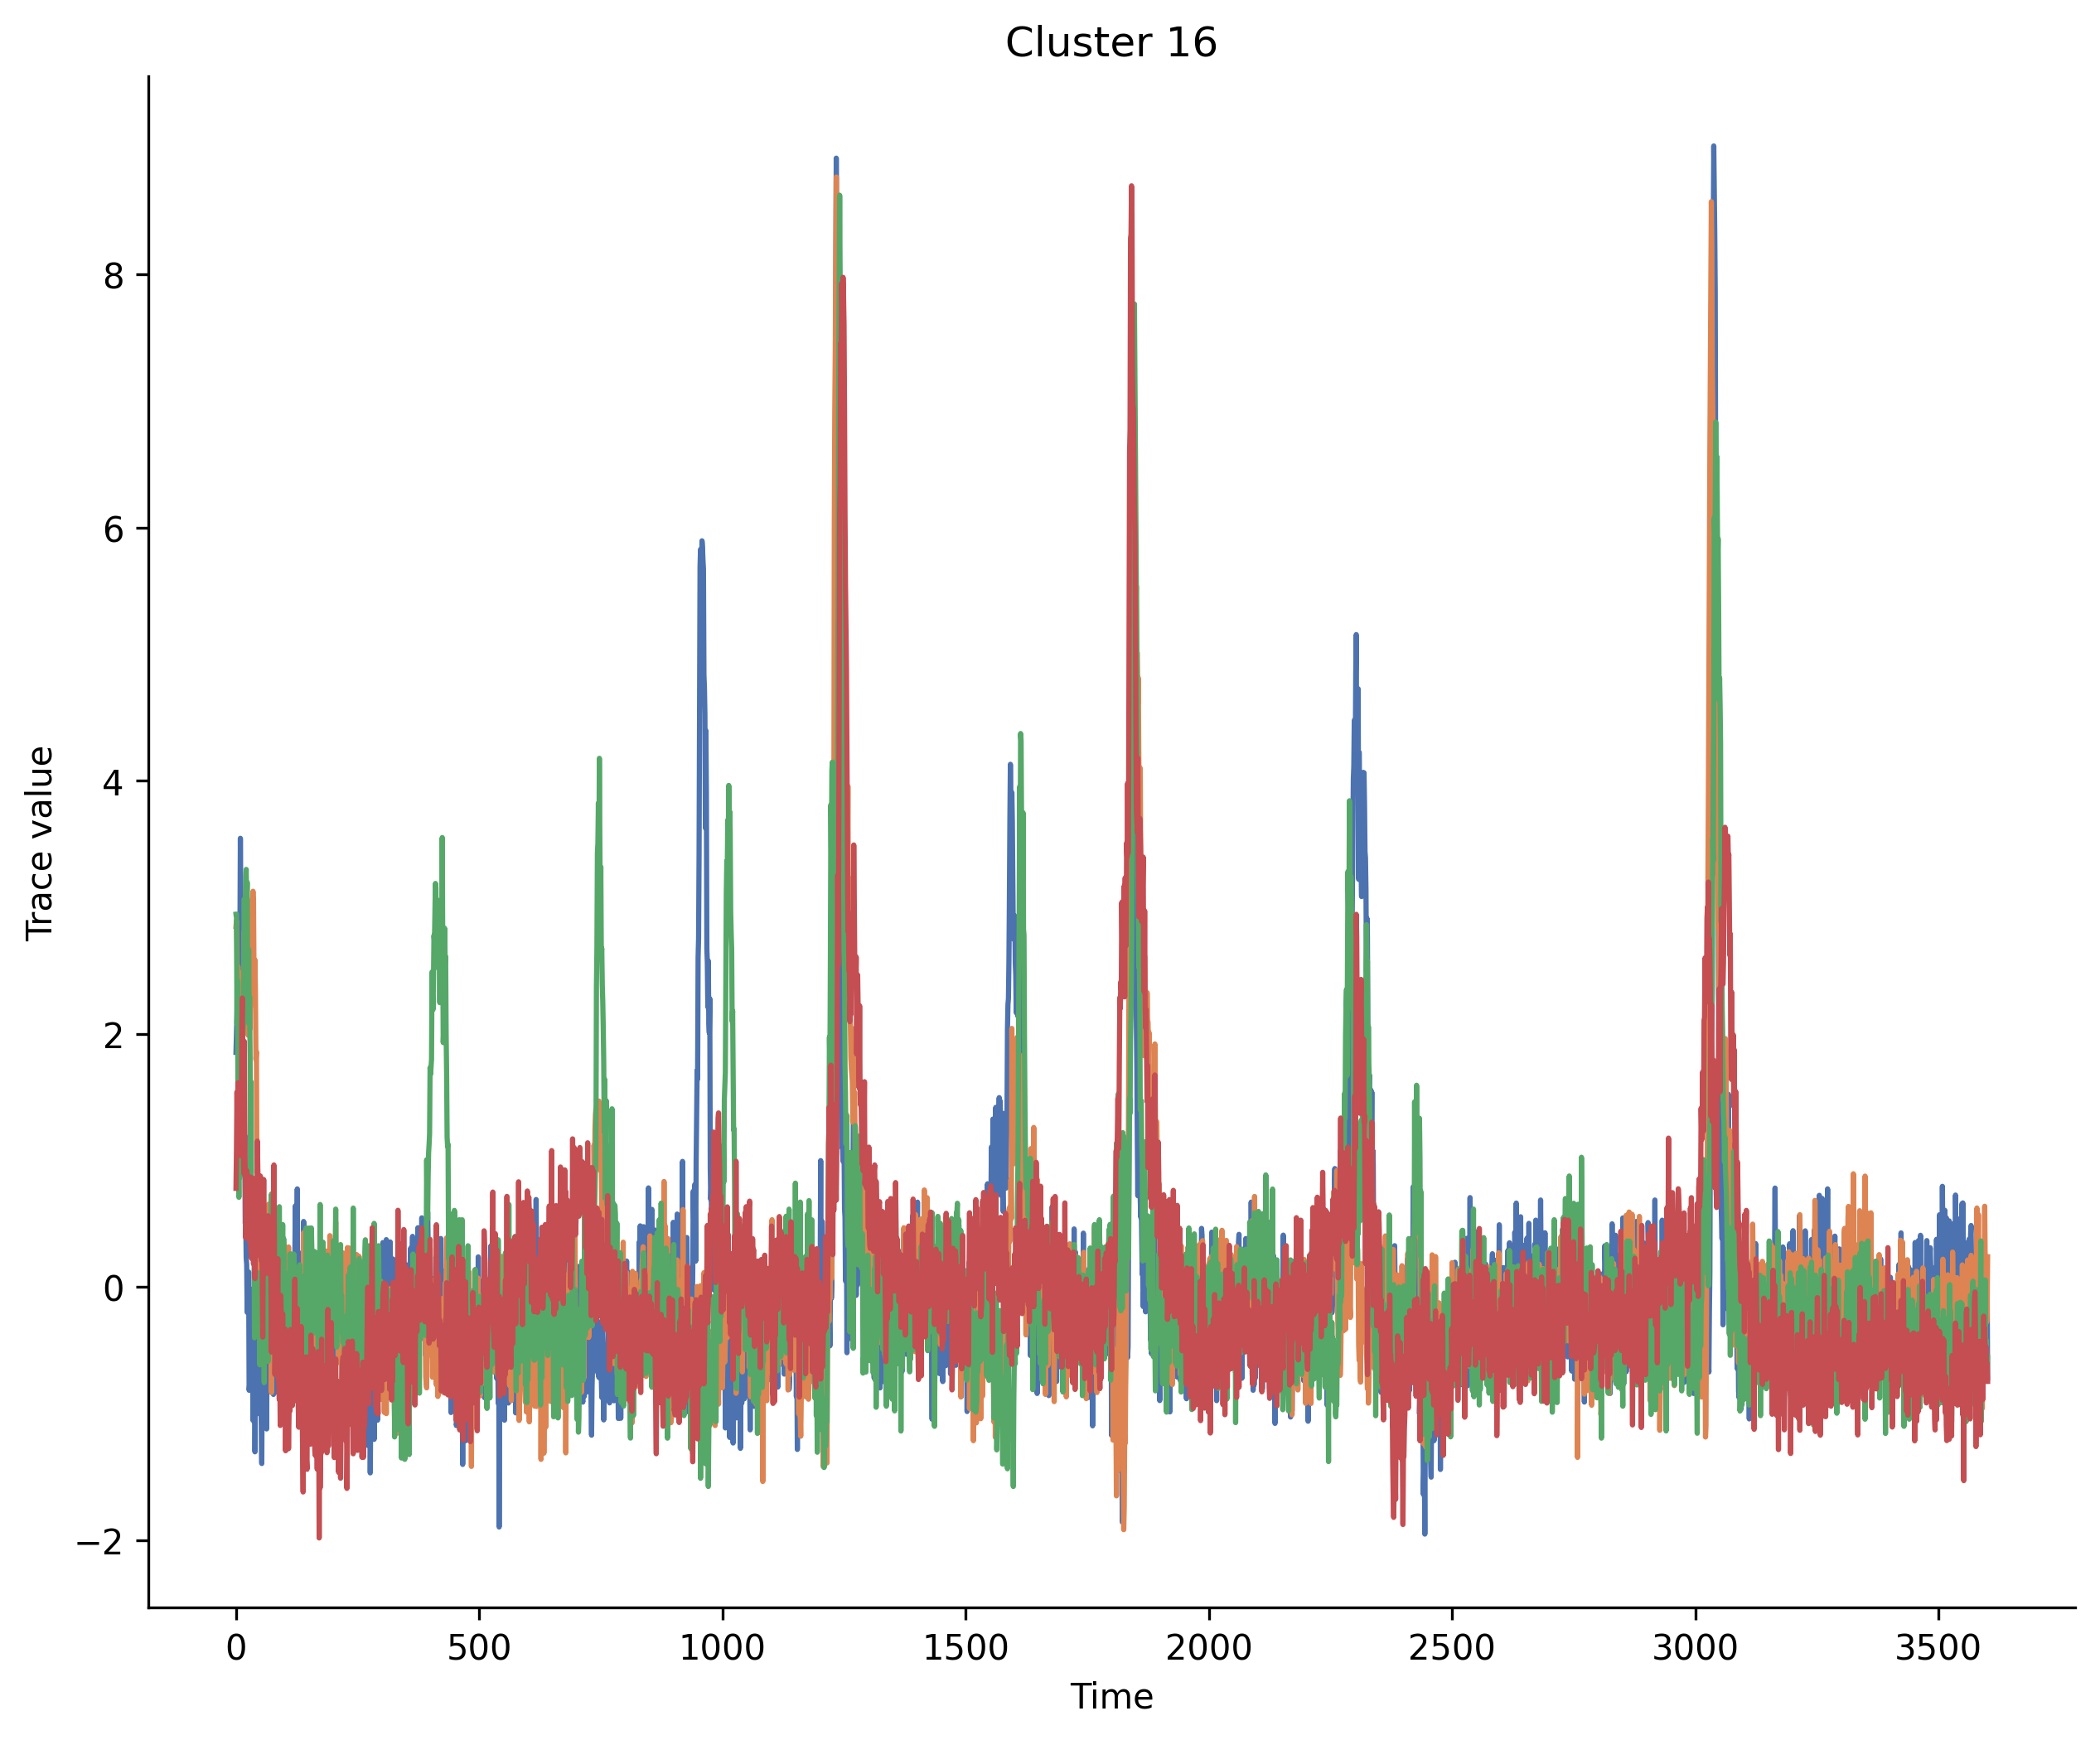

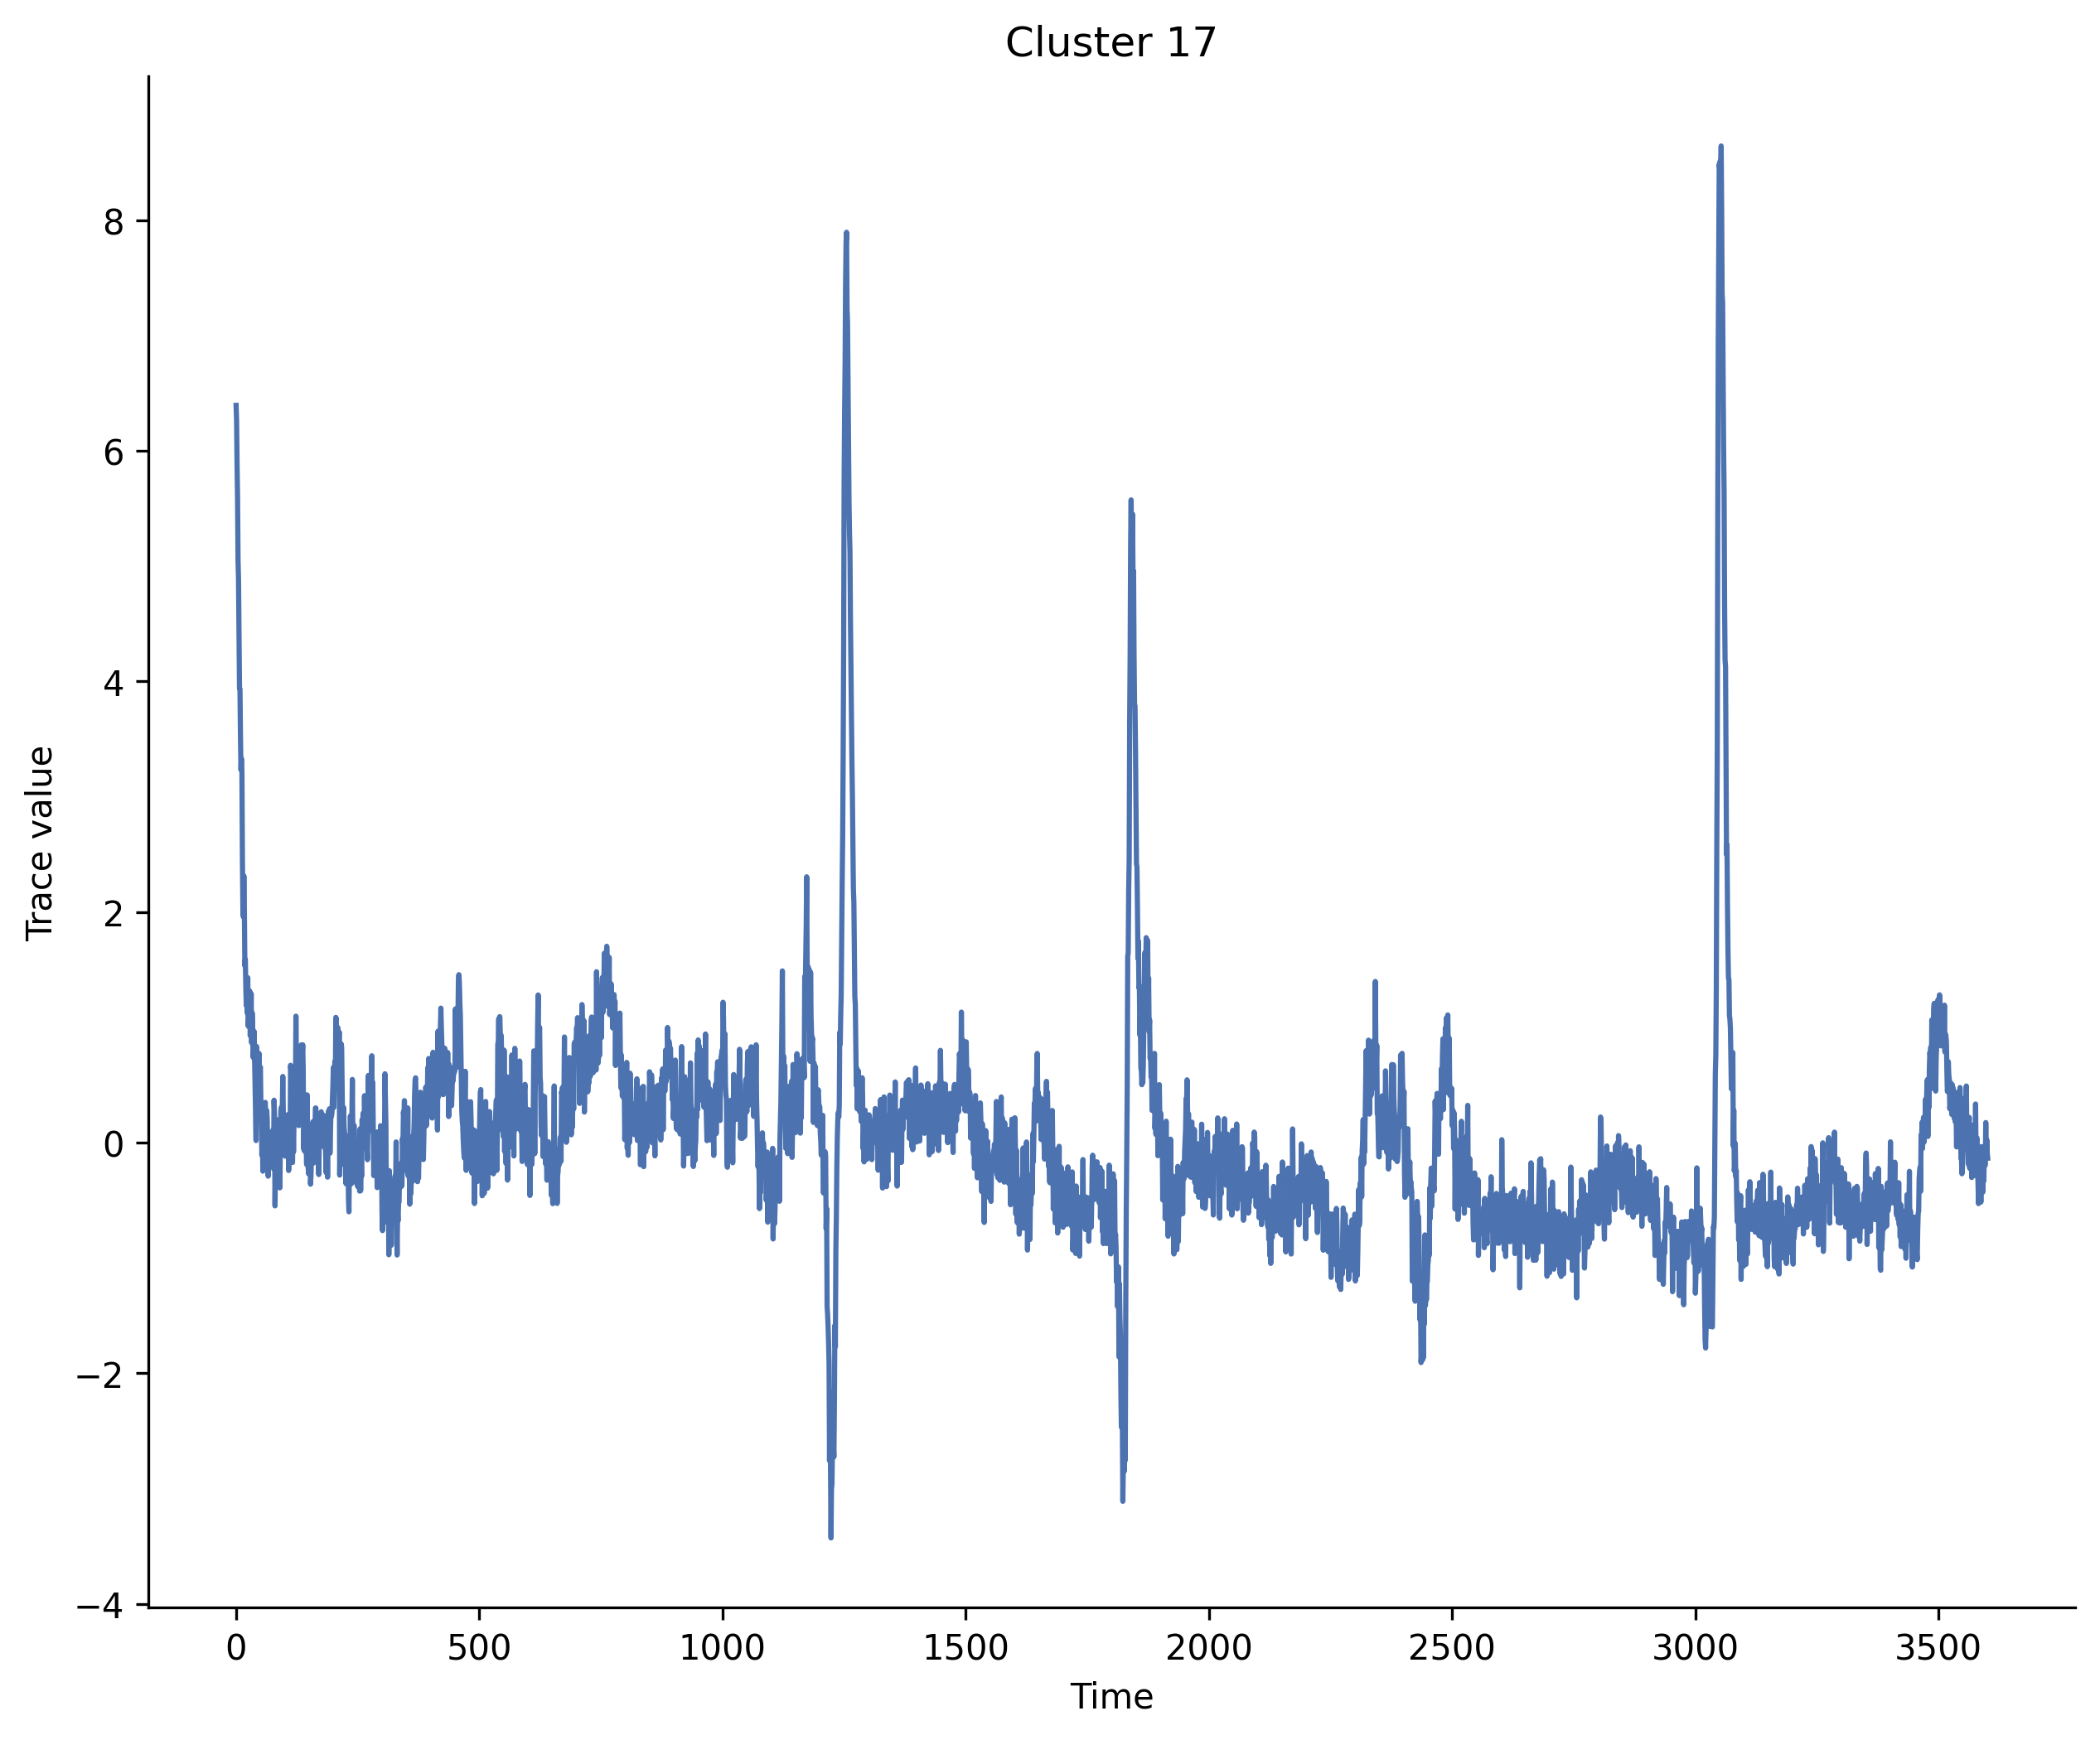

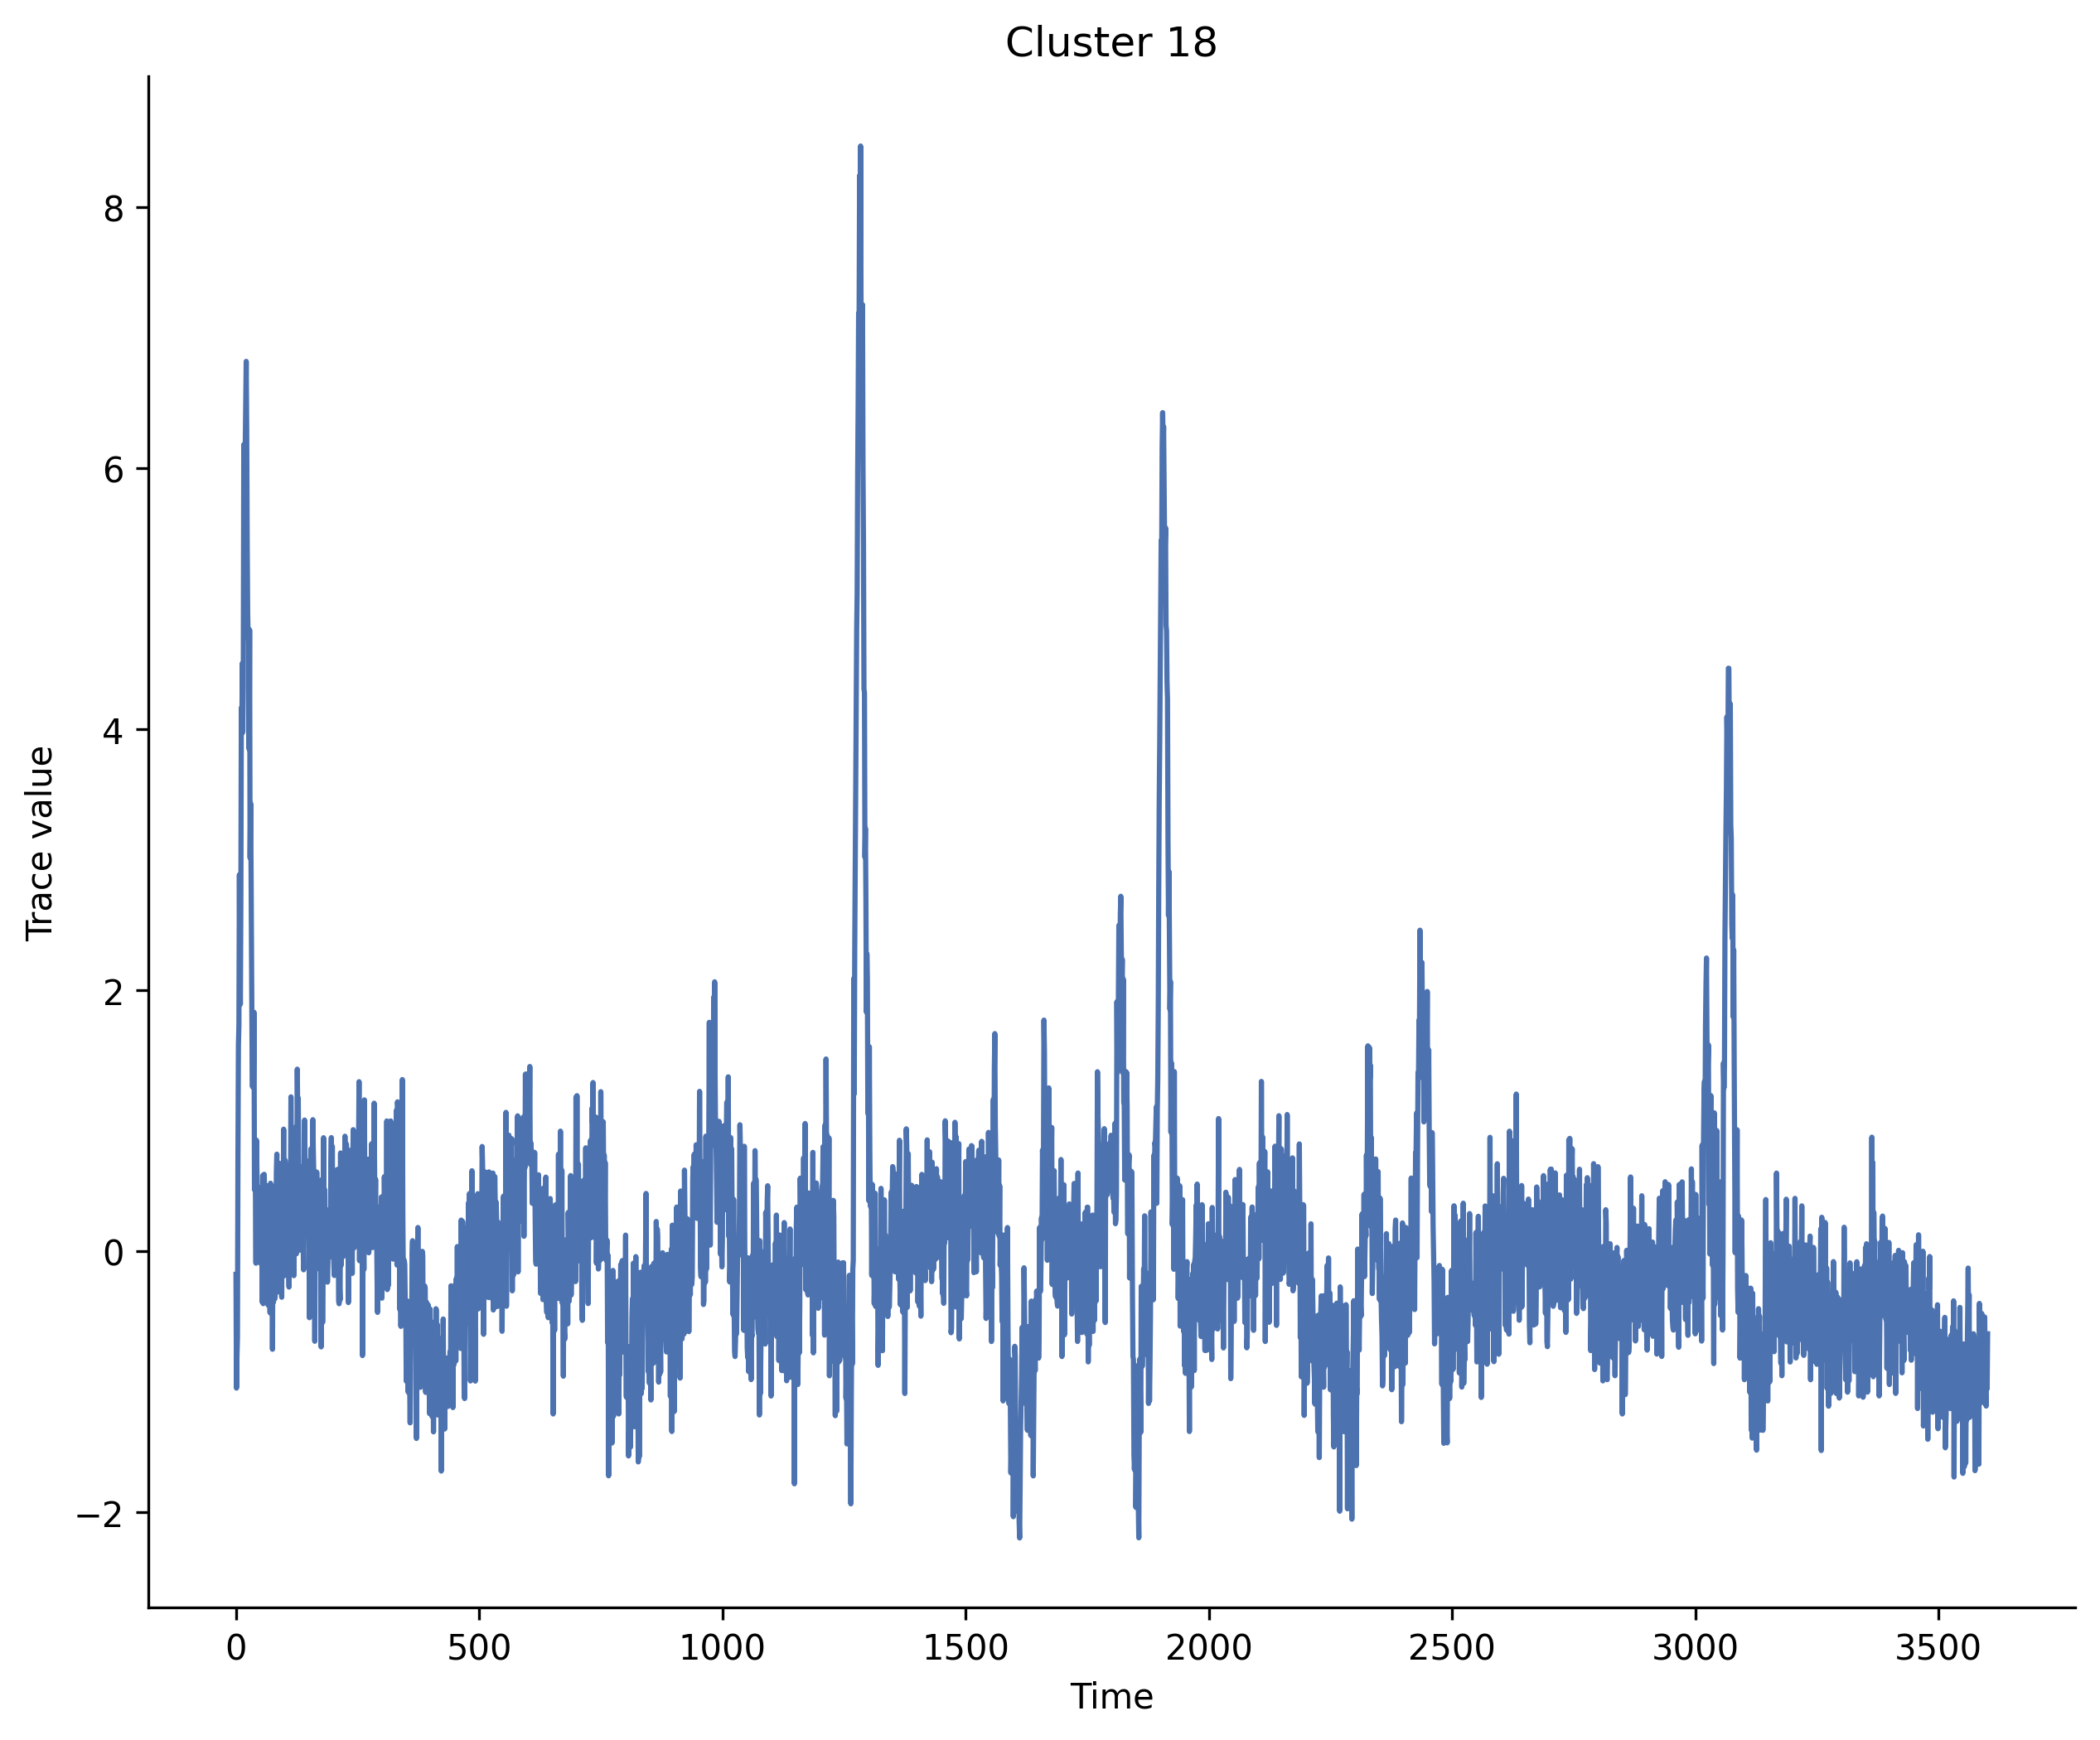

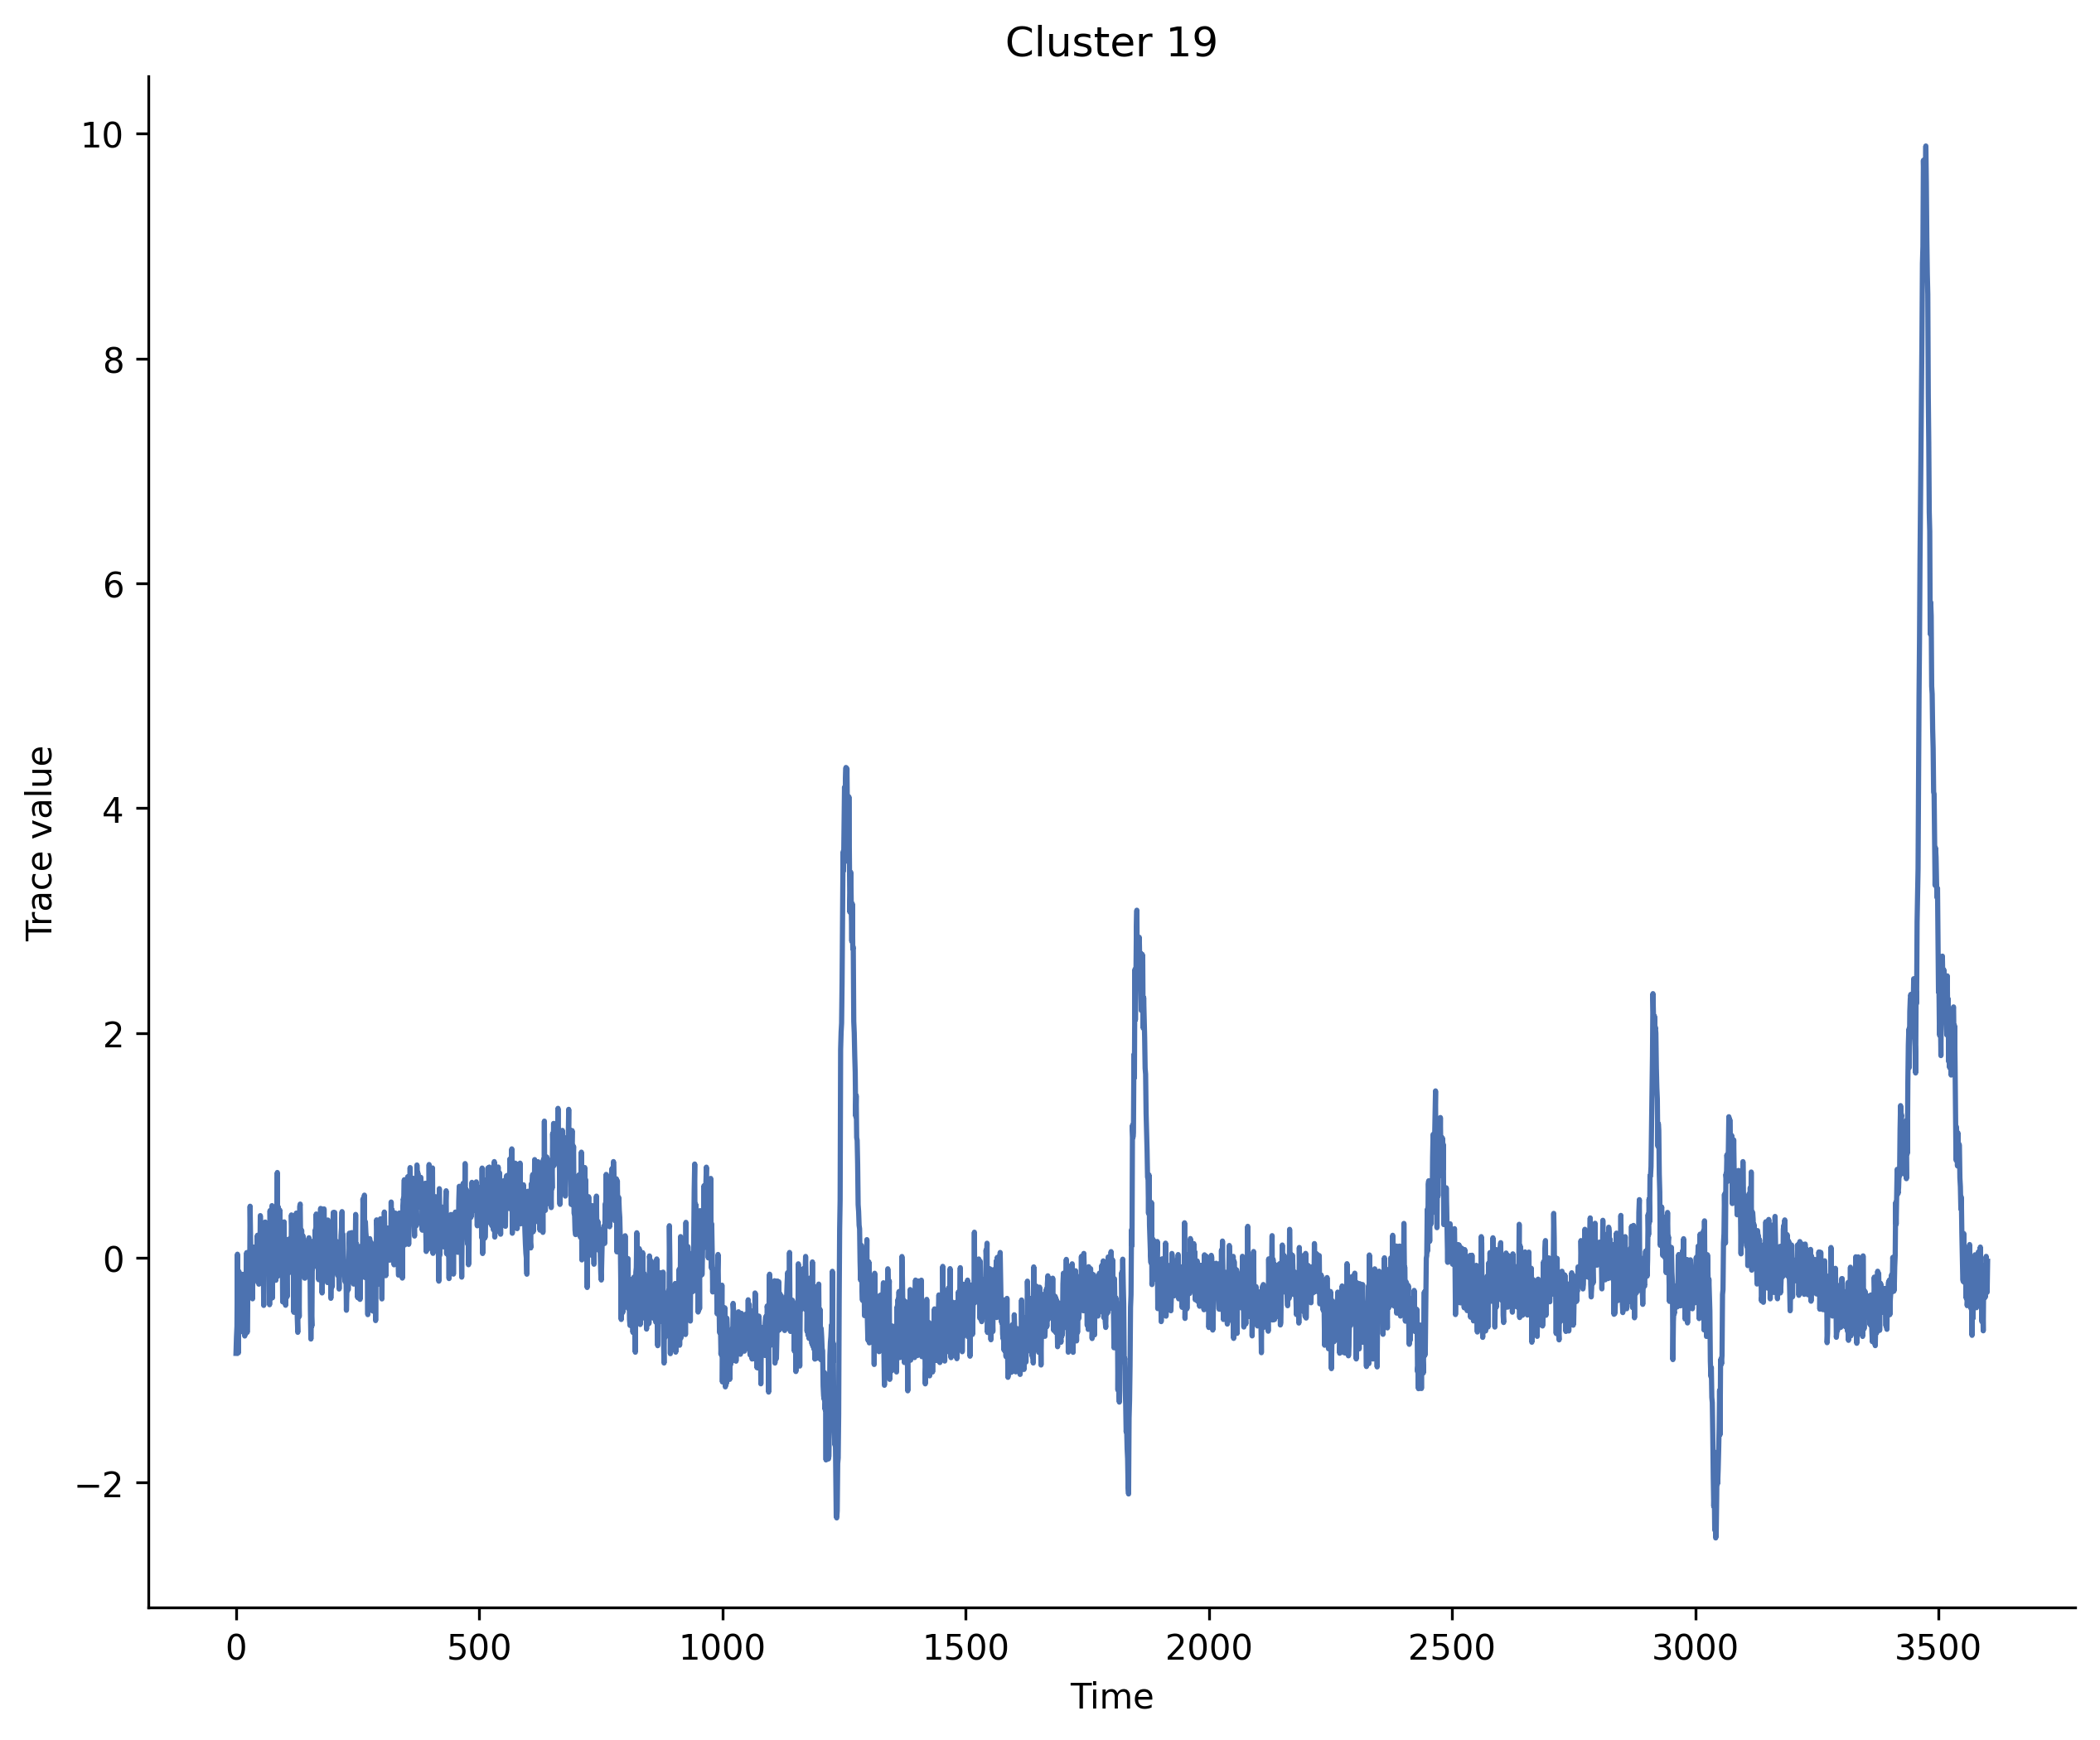

In [101]:
n_clusters = 20
labels = kmeans.labels_
for i in range(n_clusters):
    cluster_i_data = scaled_traces.T[labels == i]  # Extract the traces belonging to cluster i

    # Create a new figure for each cluster
    plt.figure(figsize=(10, 8))

    # Plot each trace in this cluster
    for trace in cluster_i_data:
        plt.plot(trace)

    # You might want to add some labels, title or legend here, e.g.:
    plt.title(f"Cluster {i}")
    plt.xlabel("Time")
    plt.ylabel("Trace value")

    plt.show()